# Projected Functional Regularization (PFR) — Riproduzione

**Paper**: *Continually Learning Self-Supervised Representations with Projected Functional Regularization*
**Venue**: CVPR Workshop CLVision 2022
**Autori**: Gomez-Villa, Twardowski, Yu, Bagdanov, van de Weijer
**Repo originale**: <https://github.com/alviur/CVPR_PFR>

---

## Obiettivo della riproduzione

Verificare il claim principale del paper: la **Projected Functional Regularization** previene il *catastrophic forgetting* nel continual self-supervised learning con maggiore plasticità rispetto a una distillazione naïf.

Confrontiamo tre metodi su CIFAR-100, divisi in **4 task da 25 classi** (allineato al setup di Tabella 1 del paper):

| Metodo | Cosa fa | Cosa ci aspettiamo |
|---|---|---|
| **FT** (Fine-tuning) | Continual training di Barlow Twins, nessuna regolarizzazione | Catastrophic forgetting evidente |
| **FD** (Feature Distillation) | `--distiller decorrelative --distill_lamb 25`, vincolo rigido sulle vecchie feature | Riduce il forgetting ma sacrifica plasticità (intransigenza) |
| **PFR** | `--distiller pfr`, projector temporale tra vecchio e nuovo spazio | Trade-off ottimale: poco forgetting, buona plasticità |

## Limiti dichiarati

| Parametro | Paper | Bash files repo | Questo notebook |
|---|---|---|---|
| Epoche per task | 1500 (§4.2) | 500 | **100** (vincolo Colab) |
| Backbone | ResNet-18 | ResNet-18 | ResNet-18 ✓ |
| Numero task CIFAR-100 | 4 | 5 (default) | **4** ✓ |
| Classi per task | 25 | 20 | **25** ✓ |

Gli **assoluti** saranno inevitabilmente inferiori a quelli della Tabella 1 del paper. L'obiettivo è verificare il **ranking relativo** PFR > FD > FT.

## Struttura del notebook

1. Setup (Drive, clone, dipendenze, patch)
2. I dati: dentro CIFAR-100 e lo split in experience
3. Barlow Twins, il base learner self-supervised
4. Continual learning, forgetting e le due distillazioni (FD, PFR)
5. Le aspettative, poi gli esperimenti: task 0 condiviso, FT, Joint, FD, PFR
6. L'esame: linear evaluation, matrice R e metriche
7. Risultati, verdetto e grafici
8. L'indagine: perché FD va così male? (cinque passi)
9. Conclusioni e confronto con il paper

> **Setup**: `Runtime → Change runtime type → T4 GPU` (o L4 se disponibile).


---

# 1. Setup

Mount di Google Drive, clone del repo nel Drive (così sopravvive ai disconnessioni Colab), installazione delle dipendenze nelle versioni esatte richieste dal codice del 2022.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

# Repo da clonare: questo fork (le patch funzionano anche sull'originale alviur/CVPR_PFR)
REPO_URL  = 'https://github.com/Streaming-Data-Analytics/2025-2026_10b_CL-Code-Reproducibility_PFR.git'
REPO_PATH = '/content/drive/MyDrive/CVPR_PFR'

if not os.path.exists(REPO_PATH):
    !git clone {REPO_URL} {REPO_PATH}
    print('Repo clonato in Drive')
else:
    print('Repo già presente in Drive')

os.chdir(REPO_PATH)
print(f'Working directory: {os.getcwd()}')

Repo già presente in Drive
Working directory: /content/drive/MyDrive/CVPR_PFR


## 1.1 Dipendenze

Il repo è stato pubblicato nel 2022 e richiede versioni **esatte** di alcune librerie. In particolare `pytorch-lightning==1.5.4`: versioni successive cambiano l'API di `optimizer_zero_grad` e degli scheduler, rompendo il training loop. Saltiamo invece NVIDIA DALI (serve solo per ImageNet su GPU dedicate).


In [ ]:
!pip install "pip<24.1" -q
!pip install pytorch-lightning==1.5.4 lightning-bolts==0.5.0 -q
!pip install wandb scikit-learn einops -q
print('Dipendenze installate')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 88.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 524.1/524.1 kB 29.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 316.8/316.8 kB 30.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 67.7 MB/s eta 0:00:00
DEPRECATION: pytorch-lightning 1.5.4 has a non-standard dependency specifier torch>=1.7.*. pip 24.1 will enforce this behaviour change. A possible replacement is to upgrade to a newer version of pytorch-lightning or contact the author to suggest that they release a version with a conforming dependency specifiers. Discussion can be found at https://github.com/pypa/pip/issues/12063
DEPRECATION: pytorch-lightning 1.5.4 has a non-standard dependency specifier torch>=1.7.*. pip 24.1 will enforce this behaviour change. A possible replacement is to upgrade to a newer version of pytorch-lightning or contact the author to suggest that they release a version with a conforming depen

In [ ]:
import torch, pytorch_lightning as pl

print(f'PyTorch:           {torch.__version__}')
print(f'pytorch-lightning: {pl.__version__}   (atteso 1.5.4)')
print(f'CUDA:              {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU:               {torch.cuda.get_device_name(0)}')

PyTorch:           2.11.0+cu128
pytorch-lightning: 1.5.4   (atteso 1.5.4)
CUDA:              True
GPU:               NVIDIA L4


## 1.2 WandB

Loggiamo le run su Weights & Biases per tenere traccia di tutte le curve. Se non hai un account, puoi commentare la cella di login e impostare `WANDB_MODE=offline`.


In [ ]:
import wandb
# Login interattivo: la API key NON va mai scritta nel notebook.
# In alternativa: variabile d'ambiente WANDB_API_KEY, oppure WANDB_MODE=offline (vedi COME_RIPRODURRE.md)
wandb.login()

os.environ['WANDB_MODE'] = 'online'

## 1.3 Patch di compatibilità

Tre fix necessari per far girare codice del 2022 su Colab moderno:

1. **`torch._six`** è stato rimosso in PyTorch 2.0 ma `pytorch_lightning 1.5.4` lo importa ancora.
2. **`torchmetrics`** ha deprecato il parametro `compute_on_step` usato in `cassle/utils/knn.py`.
3. **`pytorch_lightning.trainer.optimizers`** controlla che lo scheduler sia istanza di `_LRScheduler`, ma nelle versioni recenti di PyTorch alcuni scheduler custom non ereditano più da quella classe.


In [ ]:
# Patch 1: ricreo il modulo torch._six rimosso
import torch, os
six_path = os.path.join(os.path.dirname(torch.__file__), '_six.py')
if not os.path.exists(six_path):
    with open(six_path, 'w') as f:
        f.write("string_classes = (str,)\n")
    print(f'Creato {six_path}')
else:
    print('torch._six già patchato')

Creato /usr/local/lib/python3.12/dist-packages/torch/_six.py


In [ ]:
# Patch 2: knn.py usa un parametro deprecato di torchmetrics
knn_path = 'cassle/utils/knn.py'
with open(knn_path, 'r') as f:
    src = f.read()

if 'compute_on_step=False' in src:
    src = src.replace(
        'dist_sync_on_step=dist_sync_on_step, compute_on_step=False',
        'dist_sync_on_step=dist_sync_on_step'
    )
    with open(knn_path, 'w') as f:
        f.write(src)
    print('Patch knn.py applicata')
else:
    print('knn.py già patchato')

knn.py già patchato


In [ ]:
# Patch 3: pytorch-lightning controlla isinstance(scheduler, _LRScheduler) ma su PyTorch recenti
# alcuni scheduler custom non ereditano più da quella classe. Sostituiamo con un duck-typing check.
import pytorch_lightning.trainer.optimizers as opt_mod
import inspect

opt_path = inspect.getfile(opt_mod)
with open(opt_path, 'r') as f:
    src = f.read()

old = '''                elif isinstance(scheduler, optim.lr_scheduler._LRScheduler):
                    lr_schedulers.append({**default_config, "scheduler": scheduler})'''
new = '''                elif hasattr(scheduler, 'step') and hasattr(scheduler, 'optimizer'):
                    lr_schedulers.append({**default_config, "scheduler": scheduler})'''

if old in src:
    with open(opt_path, 'w') as f:
        f.write(src.replace(old, new))
    print('Patch pytorch-lightning applicata')
elif new in src:
    print('pytorch-lightning già patchato')
else:
    print('Pattern non trovato — verificare versione PL (atteso 1.5.4)')

Patch pytorch-lightning applicata


## 1.4 Configurazione condivisa

Tutti i parametri sperimentali in un'unica cella, così cambi una volta e si propaga ovunque.


In [ ]:
# Configurazione globale degli esperimenti
DATA_DIR = '/content/drive/MyDrive/cifar_data'
os.makedirs(DATA_DIR, exist_ok=True)

# Setup allineato al paper (Tabella 1)
NUM_TASKS       = 4         # 4 task da 25 classi (paper-aligned)
EPOCHS_PER_TASK = 100       # ridotto da 500 del repo per vincoli Colab
BATCH_SIZE      = 256
ENCODER         = 'resnet18'

# Wandb
WANDB_PROJECT = 'pfr'

# Cartelle separate per ogni esperimento (così non si sovrascrivono i checkpoint)
EXP_DIRS = {
    'task0':    './experiments/task0',
    'ft':       './experiments/ft',
    'fd':       './experiments/fd',
    'pfr':      './experiments/pfr',
    'joint':    './experiments/joint',
}
for d in EXP_DIRS.values():
    os.makedirs(d, exist_ok=True)

print(f'NUM_TASKS = {NUM_TASKS}  ({100 // NUM_TASKS} classi per task)')
print(f'EPOCHS_PER_TASK = {EPOCHS_PER_TASK}')
print(f'BATCH_SIZE = {BATCH_SIZE}')

NUM_TASKS = 4  (25 classi per task)
EPOCHS_PER_TASK = 100
BATCH_SIZE = 256


## 1.5 Dentro CIFAR-100

Prima di allenare, guardiamo i dati: come sono fatte le immagini e quali classi finiscono in ogni
experience. Lo split dipende solo dal seed 5 (lo stesso di `main_pretrain.py`), quindi possiamo
ricostruirlo e ispezionarlo.

50000 immagini di train, 100 classi, 32x32 RGB
500 immagini per classe

--- Task 0 (25 classi) ---
boy, camel, chair, clock, cloud, dinosaur, dolphin, keyboard, leopard, orange, otter, pickup_truck, porcupine, possum, ray, road, rocket, shark, snake, spider, streetcar, telephone, tractor, willow_tree, wolf 

--- Task 1 (25 classi) ---
bear, beaver, bed, bee, beetle, bicycle, bridge, butterfly, crocodile, cup, fox, house, lamp, lobster, mouse, mushroom, orchid, plain, skunk, sweet_pepper, table, television, tulip, woman, worm 

--- Task 2 (25 classi) ---
apple, aquarium_fish, baby, bus, can, castle, caterpillar, cattle, couch, elephant, girl, hamster, kangaroo, man, mountain, pine_tree, plate, poppy, raccoon, sea, seal, skyscraper, squirrel, sunflower, wardrobe 

--- Task 3 (25 classi) ---
bottle, bowl, chimpanzee, cockroach, crab, flatfish, forest, lawn_mower, lion, lizard, maple_tree, motorcycle, oak_tree, palm_tree, pear, rabbit, rose, shrew, snail, tank, tiger, train, trout, turtle,

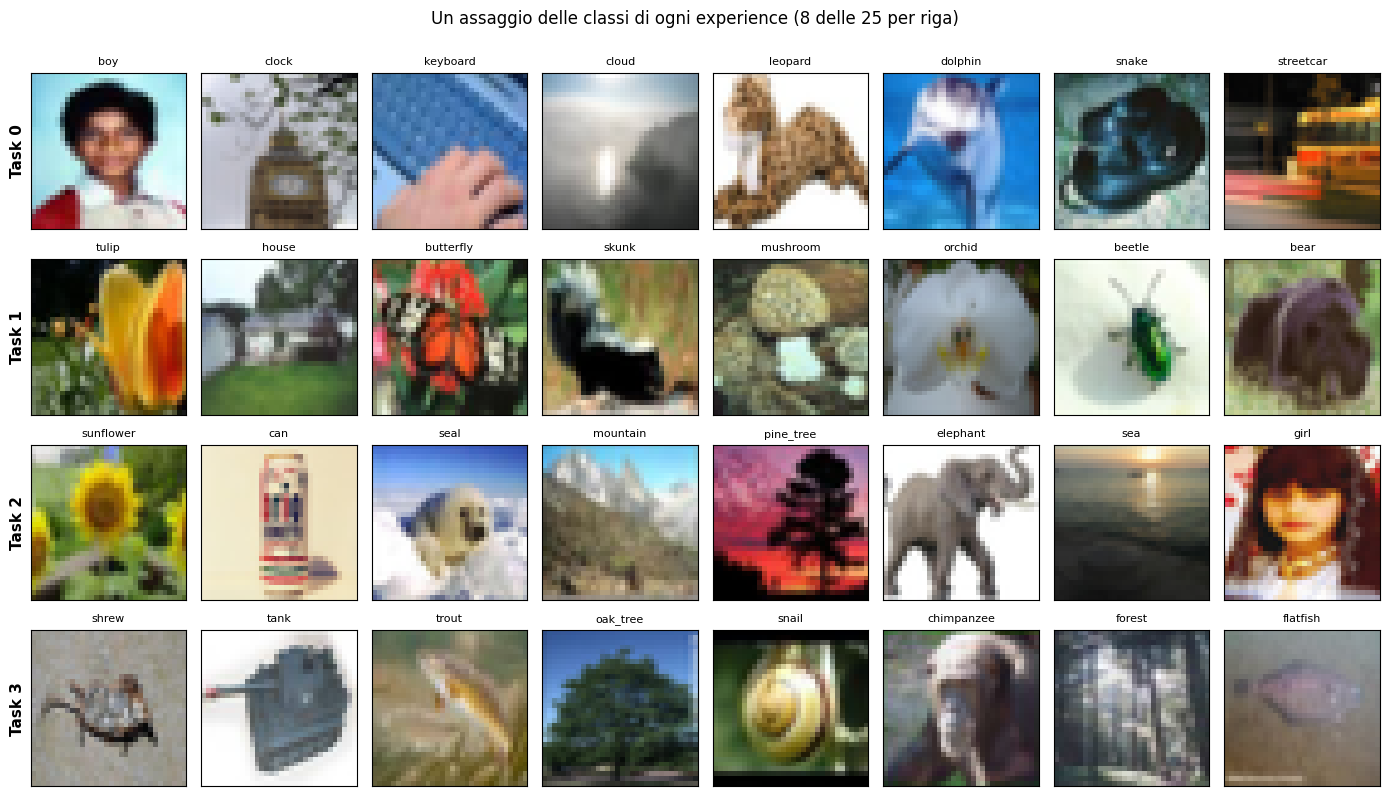

In [ ]:
# Dentro CIFAR-100: 100 classi, 32x32 pixel, divise in 4 experience da 25
import os, torch
import numpy as np
import matplotlib.pyplot as plt
from torchvision.datasets import CIFAR100

# stesso split del training: seed_everything(5) -> torch.manual_seed(5) -> randperm(100).chunk(4)
torch.manual_seed(5)
TASKS_VIEW = torch.randperm(100).chunk(4)

# riuso il dataset gia' su Drive se c'e', altrimenti download locale
_DATA = '/content/drive/MyDrive/cifar_data'
_cands = [f'{_DATA}/cifar100/train', f'{_DATA}/cifar100/val', f'{_DATA}/cifar100', _DATA]
_root = next((p for p in _cands if os.path.isdir(f'{p}/cifar-100-python')), '/content/cifar_eval')
ds_view = CIFAR100(_root, train=True, download=True)   # nessuna transform: immagini originali

print(f'{len(ds_view)} immagini di train, {len(ds_view.classes)} classi, 32x32 RGB')
print(f'{len(ds_view)//len(ds_view.classes)} immagini per classe\n')

# le 25 classi di ogni experience, per nome
for t, cls in enumerate(TASKS_VIEW):
    nomi = sorted(ds_view.classes[c] for c in cls.tolist())
    print(f'--- Task {t} ({len(nomi)} classi) ---')
    print(', '.join(nomi), '\n')

# galleria: per ogni task, un esempio di 8 delle sue classi
targets_view = np.array(ds_view.targets)
fig, axes = plt.subplots(4, 8, figsize=(14, 8))
for t, cls in enumerate(TASKS_VIEW):
    for j, c in enumerate(cls.tolist()[:8]):
        idx = np.where(targets_view == c)[0][0]
        axes[t, j].imshow(ds_view[idx][0])
        axes[t, j].set_title(ds_view.classes[c], fontsize=8)
        axes[t, j].set_xticks([]); axes[t, j].set_yticks([])
    axes[t, 0].set_ylabel(f'Task {t}', fontsize=11, fontweight='bold')
fig.suptitle('Un assaggio delle classi di ogni experience (8 delle 25 per riga)', y=1.0)
plt.tight_layout()
plt.show()

# le classi sono mescolate a caso dal randperm: ogni task e' un campione eterogeneo di CIFAR-100
# e le 25 classi nuove non contraddicono mai le vecchie (drift virtuale, Lez. 19b)

> 📖 Lezione 22, *CL Strategies*: la strategia CL si applica sopra un **base learner**; qui il base learner è Barlow Twins.

---

# 2. Self-Supervised Learning e Barlow Twins

Il SSL impara una funzione $f_\theta: \mathcal{X} \to \mathcal{F}$ che mappa immagini in feature, **senza etichette**. Il "supervisore" è la struttura stessa dei dati: due viste augmentate della stessa immagine devono produrre feature simili, due immagini diverse devono produrre feature dissimili.

**Barlow Twins** (Zbontar et al. 2021) implementa questa idea senza negative samples espliciti. Date due viste $X_A, X_B$ della stessa immagine, le passa nello stesso encoder + projector $z = h_\phi(f_\theta(x))$ e calcola la **matrice di cross-correlazione** $C$ tra le feature delle due viste lungo la dimensione del batch:

$$\mathcal{C}_{ij} = \frac{\sum_b z^A_{b,i}\, z^B_{b,j}}{\sqrt{\sum_b (z^A_{b,i})^2}\sqrt{\sum_b (z^B_{b,j})^2}}$$

La loss spinge $C$ verso la matrice identità:

$$\mathcal{L}_{BT} = \underbrace{\sum_i (1 - \mathcal{C}_{ii})^2}_{\text{invariance}} + \lambda \underbrace{\sum_i \sum_{j \neq i} \mathcal{C}_{ij}^2}_{\text{redundancy reduction}}$$

- **Invariance**: feature corrispondenti delle due viste devono essere correlate ($\to$ invarianza alle augmentation).
- **Redundancy reduction**: feature diverse devono essere decorrelate ($\to$ no collasso).

L'implementazione ufficiale è in `cassle/methods/barlow_twins.py`: calcola la matrice di cross-correlazione tra le due viste e applica i due termini della loss (invariance + redundancy reduction).


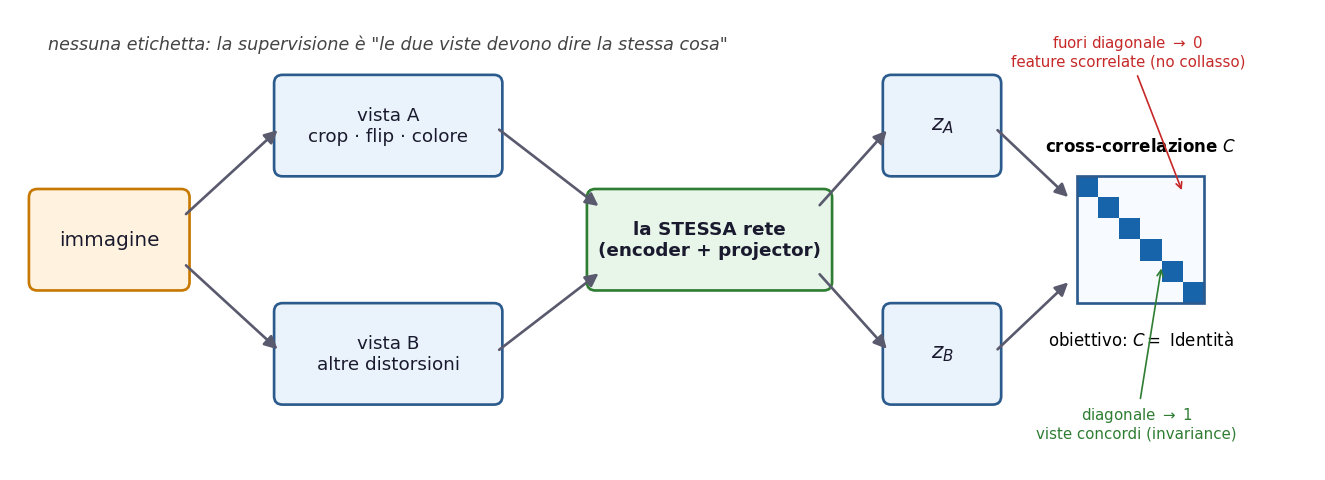

> 📖 Lezione 22, *Catastrophic Forgetting* e *Stability-Plasticity Dilemma*: gli stessi concetti al centro di questa sezione.

---

# 3. Continual Learning e catastrophic forgetting

Nel continual learning i dati arrivano come **sequenza di task** $T = \{1, \dots, c\}$, ognuno con distribuzione diversa $\mathcal{D}_t$. Vogliamo trovare $\theta$ che minimizzi la loss su **tutti** i task visti finora:

$$\arg\min_\theta \sum_{t=1}^c \mathcal{L}^t$$

ma abbiamo accesso solo ai dati di $\mathcal{D}_c$. Il fine-tuning naïf su $\mathcal{D}_c$ porta a **catastrophic forgetting**: la rete sovrascrive le rappresentazioni dei task precedenti.

## Categorie di approcci

| Categoria | Idea | Esempi |
|---|---|---|
| Replay-based | Salva campioni dei task precedenti | iCaRL, ER, Rainbow Memory |
| Architecture-based | Espande la rete per ogni task | PackNet, PathNet, DER |
| Regularization-based | Aggiunge un termine alla loss che vincola i pesi o le predizioni | EWC, MAS, LwF, **FD, PFR** |

PFR è **regularization-based exemplar-free**: non salva campioni dei task vecchi (vincolo realistico per privacy/storage).

## Feature Distillation (FD), la baseline

L'idea classica (LwF estesa al SSL): forzare le feature del nuovo modello a restare vicine a quelle del modello vecchio.

$$\mathcal{L}_{FD} = \mathcal{L}_{BT} + \lambda_{fd} \,\| f_{\theta^t}(x) - f_{\theta^{t-1}}(x) \|^2$$

Problema dichiarato nel paper: è **troppo rigido**. Penalizza direttamente qualsiasi nuova feature, quindi blocca la plasticità. Risultato: alta *intransigenza* (incapacità di imparare nuovi task).

> **Nota implementativa**: nel codice del repo la "FD" è implementata come `decorrelative` distiller, che usa una Barlow-style loss tra un MLP-predicted $p(z_{new})$ e $z_{old}$, non un L2 puro come da Eq. 4 del paper. È una piccola discrepanza paper-vs-code, ma è il setup ufficiale fornito dagli autori in `bash_files/continual/cifar/barlow_distill.sh`.

Il cuore del distiller, semplificato (`cassle/distillers/decorrelative.py`):

```python
p1 = self.distill_predictor(z1)                        # feature nuove, trasformate da un MLP
distill_loss = barlow_loss_func(p1, frozen_z1)         # devono correlare con quelle del teacher congelato
return out["loss"] + self.distill_lamb * distill_loss  # distill_lamb = 25 nel setup ufficiale
```


> 📖 Lezione 23, *Learning without Forgetting*: la distillazione dal modello precedente usata qui da FD e PFR è la stessa idea di LwF, spostata dalle predizioni alle feature.

---

# 4. Projected Functional Regularization (PFR)

Il contributo centrale del paper. Idea: invece di forzare $f_{\theta^t}(x) \approx f_{\theta^{t-1}}(x)$ direttamente, si introduce una **rete di proiezione temporale** $m: \mathcal{Z} \to \mathcal{Z}$ trainabile, e si vincola:

$$\mathcal{L}_{PFR} = \mathcal{L}_{BT} + \lambda_{pfr} \, \mathcal{S}\big(\,m(f_{\theta^t}(x)),\; f_{\theta^{t-1}}(x)\,\big)$$

dove $\mathcal{S}$ è la **negative cosine similarity**.

## Perché funziona

Le nuove feature in $f_{\theta^t}(x)$ non sono direttamente penalizzate: possono evolvere liberamente **purché esistano nel null-space di $m$**, ovvero purché $m$ riesca a "tradurle" nel vecchio spazio. Il projector $m$ è trainato insieme al backbone, quindi impara cosa è effettivamente importante preservare.

Risultato atteso: **bassa intransigenza** (la rete può imparare cose nuove) + **basso forgetting** (le informazioni del task precedente restano recuperabili via $m$).

## Implementazione

Nel repo `cassle/distillers/pfr.py`: il `distill_predictor` è un MLP a 2 strati con bottleneck $D \to D/2 \to D$ (con $D$ = feature dim del backbone, 512 per ResNet18). La loss è negative cosine similarity.

Il cuore del distiller, semplificato (`cassle/distillers/pfr.py`):

```python
p1 = self.distill_predictor(f1)                        # projector temporale: 512 -> 256 -> 512
distill_loss = -cosine_similarity(p1, frozen_f1)       # la proiezione deve "ritrovare" il teacher
return out["loss"] + self.distill_lamb * distill_loss  # distill_lamb = 1 di default
```

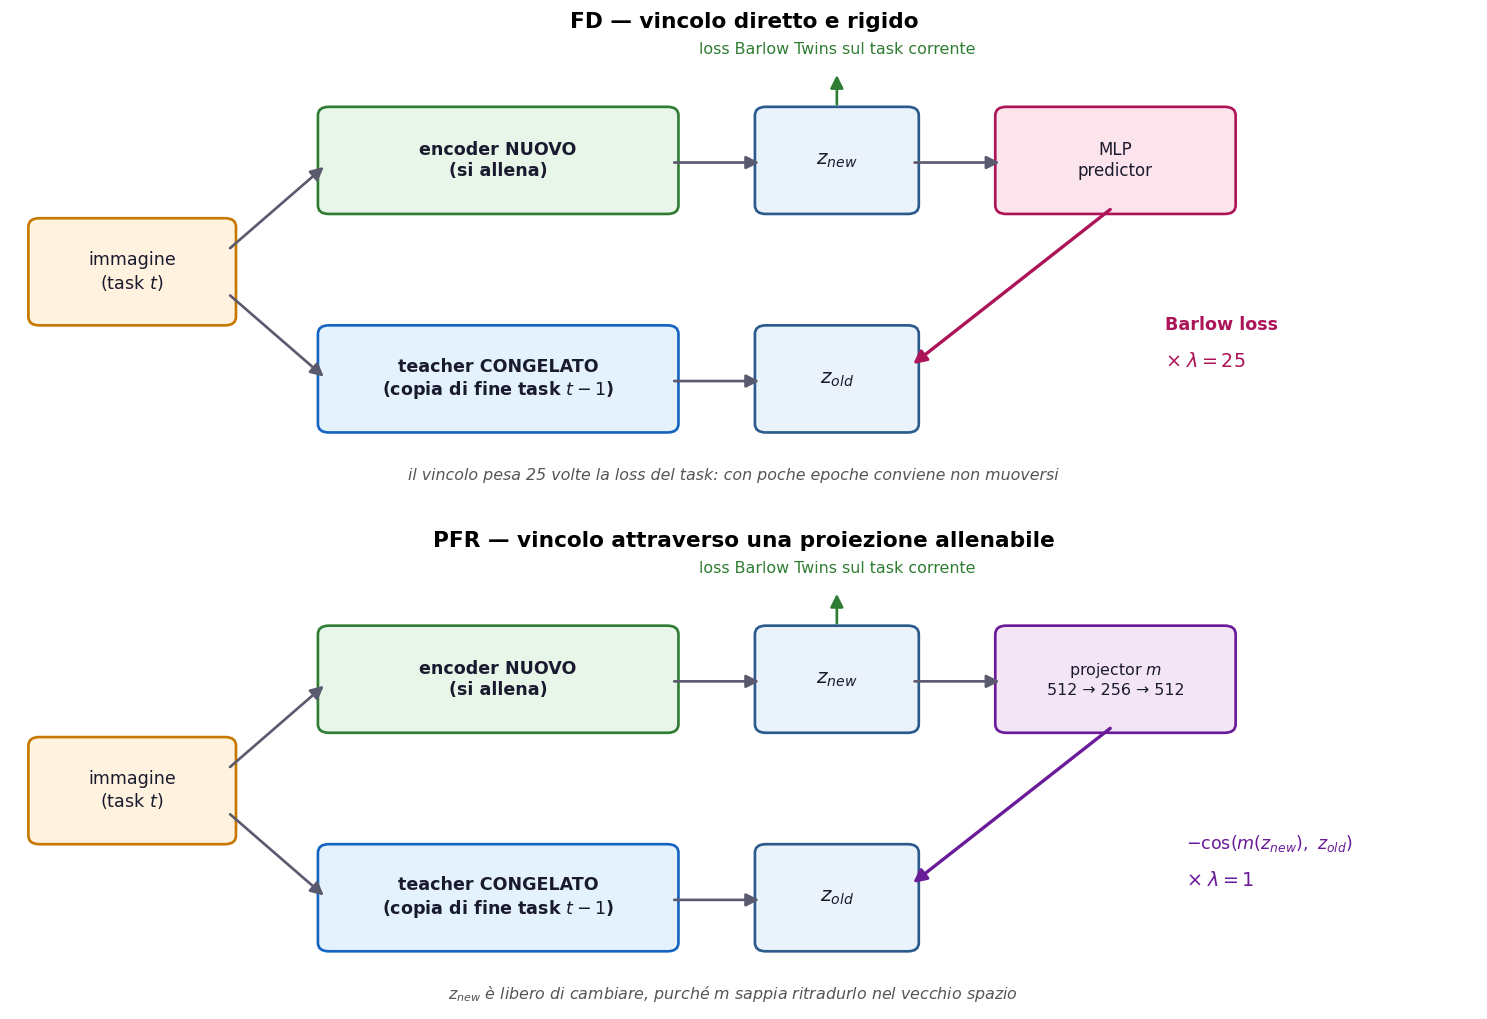

---

# 5. Pre-training del task 0

Il primo task è un SSL standard di Barlow Twins su 25 classi di CIFAR-100. Il checkpoint risultante è il **punto di partenza condiviso** per i tre esperimenti continual successivi.

Iperparametri: SGD + LARS, lr 0.3, weight decay 1e-4, cosine annealing, augmentations standard di SimCLR/BarlowTwins.


In [ ]:
import os

DATA_DIR        = '/content/drive/MyDrive/cifar_data'
NUM_TASKS       = 4
EPOCHS_PER_TASK = 100
BATCH_SIZE      = 256
ENCODER         = 'resnet18'
WANDB_PROJECT   = 'pfr'

# path ASSOLUTI su Drive così i checkpoint sopravvivono alle disconnessioni
BASE = '/content/drive/MyDrive/CVPR_PFR/experiments'
EXP_DIRS = {
    'task0': f'{BASE}/task0',
    'ft':    f'{BASE}/ft',
    'fd':    f'{BASE}/fd',
    'pfr':   f'{BASE}/pfr',
    'joint': f'{BASE}/joint',
}
for d in EXP_DIRS.values():
    os.makedirs(d, exist_ok=True)

# esporto TUTTO nell'ambiente, INCLUSO task0
os.environ['MY_DATA_DIR']  = DATA_DIR
os.environ['MY_WANDB']     = WANDB_PROJECT
os.environ['MY_EXP_T0']    = EXP_DIRS['task0']
os.environ['MY_EXP_FT']    = EXP_DIRS['ft']
os.environ['MY_EXP_FD']    = EXP_DIRS['fd']
os.environ['MY_EXP_PFR']   = EXP_DIRS['pfr']
os.environ['MY_EXP_JOINT'] = EXP_DIRS['joint']

print('MY_DATA_DIR =', os.environ['MY_DATA_DIR'])
print('MY_WANDB    =', os.environ['MY_WANDB'])
print('MY_EXP_T0   =', os.environ['MY_EXP_T0'])

MY_DATA_DIR = /content/drive/MyDrive/cifar_data
MY_WANDB    = pfr
MY_EXP_T0   = /content/drive/MyDrive/CVPR_PFR/experiments/task0


---

# Le aspettative

Prima di lanciare gli esperimenti mettiamo per iscritto cosa ci aspettiamo, sulla base del paper
(Tabella 1) e del corso (Lez. 22 p.16, 23 p.6):

| Metodo | Cosa fa | Cosa ci aspettiamo | Perché |
|---|---|---|---|
| **FT** (Naive) | continua ad allenare sul task nuovo, nessuna protezione | **lower bound**: impara bene il nuovo ma dimentica il vecchio (forgetting alto, BWT molto negativo) | Lez. 22 p.6: il training nuovo sovrascrive i pesi; è il pannello "catastrophic forgetting" della p.16 |
| **Joint** | allena su tutte le 100 classi insieme (non è continual) | **upper bound**: il massimo raggiungibile con questo budget | Lez. 23 p.6: vede tutto, non ha nulla da dimenticare |
| **FD** | distillazione rigida: le feature nuove devono restare uguali a quelle del **teacher congelato** (λ=25) | tra FT e PFR: poco forgetting ma anche poca plasticità (intransigenza) | è LwF con vincolo duro (Lez. 23 p.11-12): protegge il passato al costo del presente |
| **PFR** | distillazione morbida: le feature nuove devono essere *traducibili* in quelle vecchie tramite un projector allenabile | **il migliore dei continual**: poco forgetting E buona plasticità | il projector rilassa il vincolo: il nuovo può evolvere purché il vecchio resti recuperabile |

**Ranking atteso**: Joint > PFR > FD > FT (in Avg Accuracy).

Le tre domande a cui i numeri dovranno rispondere:
1. FT dimentica davvero in modo catastrofico, con sole 100 epoche per task?
2. Quanta plasticità paga FD per la sua stabilità?
3. PFR ottiene davvero BWT ≥ 0 come dichiarato nel paper (Lez. 22 p.28: "il caso ottimale teorico")?

Il confronto atteso/ottenuto è dopo i risultati (Sez. 10-11); l'analisi del perché nella Sez. 12.

In [ ]:
!CUDA_VISIBLE_DEVICES=0 python main_pretrain.py \
    --dataset cifar100 \
    --encoder resnet18 \
    --data_dir "$MY_DATA_DIR" \
    --split_strategy class \
    --max_epochs 100 \
    --num_tasks 4 \
    --task_idx 0 \
    --gpus 0 \
    --num_workers 4 \
    --precision 16 \
    --optimizer sgd --lars --grad_clip_lars --eta_lars 0.02 --exclude_bias_n_norm \
    --scheduler warmup_cosine \
    --lr 0.3 --classifier_lr 0.1 --weight_decay 1e-4 \
    --batch_size 256 \
    --brightness 0.4 --contrast 0.4 --saturation 0.2 --hue 0.1 \
    --gaussian_prob 0.0 0.0 --solarization_prob 0.0 0.2 \
    --name t0_pretrain \
    --project "$MY_WANDB" \
    --save_checkpoint \
    --checkpoint_dir "$MY_EXP_T0" \
    --disable_knn_eval \
    --method barlow_twins \
    --proj_hidden_dim 2048 --output_dim 2048 --scale_loss 0.1 \
    --wandb

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/content/drive/MyDrive/CVPR_PFR/cassle/utils/whitening.py:21: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @custom_fwd(cast_inputs=torch.float32)
Global seed set to 5
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/core/lightning.py:2053: DeprecationWarning: `torch.distributed._sharded_tensor` will be deprecated, use `torch.distributed._shard.sharded_tensor` instead
  from torch.distributed._sharded_tensor import pre_load_state_dict_hook, state_dict_hook
wandb: WARNING The anonymous setting has no effect and will be removed i

In [ ]:
# Trovo il checkpoint del task 0
import glob

ckpts = glob.glob(f"{EXP_DIRS['task0']}/**/*.ckpt", recursive=True)
assert ckpts, 'Nessun checkpoint trovato per il task 0!'

TASK0_CKPT = ckpts[0]
print(f'TASK0_CKPT = {TASK0_CKPT}')
os.environ['MY_CKPT_T0'] = str(TASK0_CKPT)

TASK0_CKPT = /content/drive/MyDrive/CVPR_PFR/experiments/task0/0yvo17ws/t0_pretrain-task0-ep=99-0yvo17ws.ckpt


---

# 6. Esperimento A — Fine-tuning puro (FT)

**Obiettivo**: dimostrare empiricamente il catastrophic forgetting.

Continuiamo il training di Barlow Twins sui task 1, 2, 3 senza nessuna forma di regolarizzazione. Il modello caricato all'inizio è il checkpoint del task 0. `main_continual.py` esegue automaticamente il loop sui task rimanenti, passando il checkpoint del task $t-1$ come pretrained per il task $t$.

> **Cosa NON c'è**: `--distiller`. Niente regolarizzazione = niente protezione contro il forgetting.


In [ ]:
!CUDA_VISIBLE_DEVICES=0 python main_continual.py \
    --dataset cifar100 \
    --encoder resnet18 \
    --data_dir "$MY_DATA_DIR" \
    --split_strategy class \
    --max_epochs 100 \
    --num_tasks 4 \
    --task_idx 1 \
    --gpus 0 \
    --num_workers 4 \
    --precision 16 \
    --optimizer sgd --lars --grad_clip_lars --eta_lars 0.02 --exclude_bias_n_norm \
    --scheduler warmup_cosine \
    --lr 0.3 --classifier_lr 0.1 --weight_decay 1e-4 \
    --batch_size 256 \
    --brightness 0.4 --contrast 0.4 --saturation 0.2 --hue 0.1 \
    --gaussian_prob 0.0 0.0 --solarization_prob 0.0 0.2 \
    --name ft \
    --project "$MY_WANDB" \
    --save_checkpoint \
    --checkpoint_dir "$MY_EXP_FT" \
    --disable_knn_eval \
    --method barlow_twins \
    --proj_hidden_dim 2048 --output_dim 2048 --scale_loss 0.1 \
    --pretrained_model "$MY_CKPT_T0" \
    --wandb \
    --knn_k 20


#### Starting Task 1 ####
Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/content/drive/MyDrive/CVPR_PFR/cassle/utils/whitening.py:21: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @custom_fwd(cast_inputs=torch.float32)
Global seed set to 5
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/core/lightning.py:2053: DeprecationWarning: `torch.distributed._sharded_tensor` will be deprecated, use `torch.distributed._shard.sharded_tensor` instead
  from torch.distributed._sharded_tensor import pre_load_state_dict_hook, state_dict_hook
Loading previous task checkpoint /content/dri

In [ ]:
# ESPERIMENTO D: Joint training (upper bound)
# Trick: --num_tasks 1 → tutte le 100 classi in un'unica "task" = training joint
# Stesso budget compute del continual (100 epoche su dataset intero ≈ 4×100 epoche su singolo task)
!CUDA_VISIBLE_DEVICES=0 python main_pretrain.py \
    --dataset cifar100 \
    --encoder resnet18 \
    --data_dir "$MY_DATA_DIR" \
    --split_strategy class \
    --max_epochs 100 \
    --num_tasks 1 \
    --task_idx 0 \
    --gpus 0 \
    --num_workers 4 \
    --precision 16 \
    --optimizer sgd --lars --grad_clip_lars --eta_lars 0.02 --exclude_bias_n_norm \
    --scheduler warmup_cosine \
    --lr 0.3 --classifier_lr 0.1 --weight_decay 1e-4 \
    --batch_size 256 \
    --brightness 0.4 --contrast 0.4 --saturation 0.2 --hue 0.1 \
    --gaussian_prob 0.0 0.0 --solarization_prob 0.0 0.2 \
    --name joint_pretrain \
    --project "$MY_WANDB" \
    --save_checkpoint \
    --checkpoint_dir "$MY_EXP_JOINT" \
    --disable_knn_eval \
    --method barlow_twins \
    --proj_hidden_dim 2048 --output_dim 2048 --scale_loss 0.1 \
    --wandb

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/content/drive/MyDrive/CVPR_PFR/cassle/utils/whitening.py:21: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @custom_fwd(cast_inputs=torch.float32)
Global seed set to 5
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/core/lightning.py:2053: DeprecationWarning: `torch.distributed._sharded_tensor` will be deprecated, use `torch.distributed._shard.sharded_tensor` instead
  from torch.distributed._sharded_tensor import pre_load_state_dict_hook, state_dict_hook
wandb: WARNING The anonymous setting has no effect and will be removed i

---

# 7. Esperimento B — Feature Distillation (FD)

Stesso setup del fine-tuning, ma con **distillazione attiva**: forziamo le proiezioni del nuovo modello a restare allineate (via Barlow-style cross-correlation) a quelle del vecchio modello. Parametri presi direttamente da `bash_files/continual/cifar/barlow_distill.sh`:

- `--distiller decorrelative`
- `--distill_lamb 25`

Atteso: forgetting più basso del FT, ma anche **plasticità sacrificata** (le nuove feature sono fortemente vincolate alle vecchie).


In [ ]:
!CUDA_VISIBLE_DEVICES=0 python main_continual.py \
    --dataset cifar100 \
    --encoder resnet18 \
    --data_dir "$MY_DATA_DIR" \
    --split_strategy class \
    --max_epochs 100 \
    --num_tasks 4 \
    --task_idx 1 \
    --gpus 0 \
    --num_workers 4 \
    --precision 16 \
    --optimizer sgd --lars --grad_clip_lars --eta_lars 0.02 --exclude_bias_n_norm \
    --scheduler warmup_cosine \
    --lr 0.3 --classifier_lr 0.1 --weight_decay 1e-4 \
    --batch_size 256 \
    --brightness 0.4 --contrast 0.4 --saturation 0.2 --hue 0.1 \
    --gaussian_prob 0.0 0.0 --solarization_prob 0.0 0.2 \
    --name fd \
    --project "$MY_WANDB" \
    --save_checkpoint \
    --checkpoint_frequency 99 \
    --checkpoint_dir "$MY_EXP_FD" \
    --disable_knn_eval \
    --method barlow_twins \
    --proj_hidden_dim 2048 --output_dim 2048 --scale_loss 0.1 \
    --distiller decorrelative \
    --distill_lamb 25 \
    --pretrained_model "$MY_CKPT_T0" \
    --wandb \
    --knn_k 20


#### Starting Task 1 ####
Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/content/drive/MyDrive/CVPR_PFR/cassle/utils/whitening.py:21: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @custom_fwd(cast_inputs=torch.float32)
Global seed set to 5
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/core/lightning.py:2053: DeprecationWarning: `torch.distributed._sharded_tensor` will be deprecated, use `torch.distributed._shard.sharded_tensor` instead
  from torch.distributed._sharded_tensor import pre_load_state_dict_hook, state_dict_hook
Loading previous task checkpoint /content/dri

---

# 8. Esperimento C — PFR

Il metodo del paper. Parametri presi da `bash_files/continual/cifar/pfr_distill.sh`:

- `--distiller pfr` (con `--distill_lamb` di default = 1)

Atteso: ranking PFR > FD > FT su accuracy media, e plasticità superiore a FD (minor intransigenza, vedi Fig. 4b del paper).


In [ ]:
# ESPERIMENTO C: PFR
!CUDA_VISIBLE_DEVICES=0 python main_continual.py \
    --dataset cifar100 \
    --encoder resnet18 \
    --data_dir "$MY_DATA_DIR" \
    --split_strategy class \
    --max_epochs 100 \
    --num_tasks 4 \
    --task_idx 1 \
    --gpus 0 \
    --num_workers 4 \
    --precision 16 \
    --optimizer sgd --lars --grad_clip_lars --eta_lars 0.02 --exclude_bias_n_norm \
    --scheduler warmup_cosine \
    --lr 0.3 --classifier_lr 0.1 --weight_decay 1e-4 \
    --batch_size 256 \
    --brightness 0.4 --contrast 0.4 --saturation 0.2 --hue 0.1 \
    --gaussian_prob 0.0 0.0 --solarization_prob 0.0 0.2 \
    --name pfr \
    --project "$MY_WANDB" \
    --save_checkpoint \
    --checkpoint_frequency 99 \
    --checkpoint_dir "$MY_EXP_PFR" \
    --disable_knn_eval \
    --method barlow_twins \
    --proj_hidden_dim 2048 --output_dim 2048 --scale_loss 0.1 \
    --distiller pfr \
    --pretrained_model "$MY_CKPT_T0" \
    --wandb \
    --knn_k 20


#### Starting Task 1 ####
Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/content/drive/MyDrive/CVPR_PFR/cassle/utils/whitening.py:21: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @custom_fwd(cast_inputs=torch.float32)
Global seed set to 5
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/core/lightning.py:2053: DeprecationWarning: `torch.distributed._sharded_tensor` will be deprecated, use `torch.distributed._shard.sharded_tensor` instead
  from torch.distributed._sharded_tensor import pre_load_state_dict_hook, state_dict_hook
Loading previous task checkpoint /content/dri

---

# 9. Linear evaluation

Protocollo standard per valutare la qualità di una rappresentazione SSL: si **congela** l'encoder e si addestra solo un classificatore lineare sopra. Se la rappresentazione contiene davvero informazione utile sulle classi, un linear probe la deve poter estrarre.

Per costruire la matrice $R$ del continual learning (e quindi calcolare forgetting/BWT) ci servono i probe su **tutti i checkpoint intermedi** di ogni metodo:

- Task 0: 1 checkpoint condiviso
- FT, FD, PFR: 3 checkpoint ciascuno (dopo task 1, 2, 3)
- Joint: 1 checkpoint (upper bound)

Totale: $1 + 3 \times 3 + 1 = 11$ linear eval. Per il joint la eval usa comunque `--num_tasks 4`:
lo split di classi resta identico (stesso seed) e i `val_acc1_task{i}` sono direttamente confrontabili
con gli altri metodi.


In [ ]:
import re, glob

def find_task_checkpoints(exp_dir):
    """Ritorna {task_idx: checkpoint_path} per una directory di esperimento."""
    out = {}
    for ckpt in glob.glob(f'{exp_dir}/**/*.ckpt', recursive=True):
        m = re.search(r'task(\d+)', ckpt)
        if m:
            out[int(m.group(1))] = ckpt
    return out

ckpts_all = {
    'task0': find_task_checkpoints(EXP_DIRS['task0']),
    'ft':    find_task_checkpoints(EXP_DIRS['ft']),
    'fd':    find_task_checkpoints(EXP_DIRS['fd']),
    'pfr':   find_task_checkpoints(EXP_DIRS['pfr']),
    'joint': find_task_checkpoints(EXP_DIRS['joint']),
}

for name, d in ckpts_all.items():
    print(f'{name}: {sorted(d.keys())}')

task0: [0]
ft: [1, 2, 3]
fd: [1, 2, 3]
pfr: [1, 2, 3]
joint: [0]


In [ ]:
import glob, os, re

BASE = '/content/drive/MyDrive/CVPR_PFR/experiments'

print('=== TUTTI I CHECKPOINT ===\n')
for metodo in ['task0', 'ft', 'fd', 'pfr', 'joint']:
    ckpts = sorted(glob.glob(f'{BASE}/{metodo}/**/*.ckpt', recursive=True))
    print(f'### {metodo} ({len(ckpts)} checkpoint) ###')
    if not ckpts:
        print('   (nessuno)')
    for c in ckpts:
        # estraggo task ed epoca dal nome
        mt = re.search(r'task(\d+)', os.path.basename(c))
        me = re.search(r'ep=(\d+)', os.path.basename(c))
        task = mt.group(1) if mt else '?'
        ep   = me.group(1) if me else '?'
        size = os.path.getsize(c) / 1e6
        flag = '  ⚠️ ep=0 (FRAMMENTO)' if ep == '0' else ''
        print(f'   task{task} | ep={ep:>3} | {size:6.1f} MB | {os.path.basename(c)}{flag}')
    print()

=== TUTTI I CHECKPOINT ===

### task0 (1 checkpoint) ###
   task0 | ep= 99 |  165.5 MB | t0_pretrain-task0-ep=99-0yvo17ws.ckpt

### ft (3 checkpoint) ###
   task2 | ep= 99 |  165.5 MB | ft-task2-ep=99-0rq22ame.ckpt
   task3 | ep= 99 |  165.5 MB | ft-task3-ep=99-4ml7aucc.ckpt
   task1 | ep= 99 |  165.5 MB | ft-task1-ep=99-oe498r1i.ckpt

### fd (3 checkpoint) ###
   task1 | ep= 99 |  315.3 MB | fd-task1-ep=99-0tohdvqj.ckpt
   task3 | ep= 99 |  315.3 MB | fd-task3-ep=99-y055jr6h.ckpt
   task2 | ep= 99 |  315.3 MB | fd-task2-ep=99-y9rp1ep3.ckpt

### pfr (3 checkpoint) ###
   task2 | ep= 99 |  250.2 MB | pfr-task2-ep=99-22ffxzm4.ckpt
   task1 | ep= 99 |  250.2 MB | pfr-task1-ep=99-5oeqs16g.ckpt
   task3 | ep= 99 |  250.2 MB | pfr-task3-ep=99-otudaamb.ckpt

### joint (1 checkpoint) ###
   task0 | ep= 99 |  165.5 MB | joint_pretrain-task0-ep=99-iva9idyn.ckpt



In [ ]:
import os

def linear_eval(ckpt_path, run_name, max_epochs=100):
    """Lancia main_linear.py su un checkpoint. Path via os.environ per robustezza."""
    os.environ['LE_CKPT']     = str(ckpt_path)
    os.environ['LE_NAME']     = str(run_name)
    os.environ['LE_EPOCHS']   = str(max_epochs)
    os.environ['MY_DATA_DIR'] = str(DATA_DIR)
    os.environ['MY_WANDB']    = str(WANDB_PROJECT)
    os.environ['MY_ENCODER']  = str(ENCODER)
    os.environ['MY_NTASKS']   = str(NUM_TASKS)
    print(f'>> Linear eval: {run_name}')
    print(f'   ckpt: {ckpt_path}')

    !CUDA_VISIBLE_DEVICES=0 python main_linear.py \
        --dataset cifar100 \
        --encoder "$MY_ENCODER" \
        --data_dir "$MY_DATA_DIR" \
        --split_strategy class \
        --max_epochs "$LE_EPOCHS" \
        --gpus 0 \
        --precision 16 \
        --optimizer sgd --scheduler step --lr_decay_steps 60 80 \
        --lr 0.1 --weight_decay 0 \
        --batch_size 256 \
        --num_workers 4 \
        --num_tasks "$MY_NTASKS" \
        --pretrained_feature_extractor "$LE_CKPT" \
        --name "$LE_NAME" \
        --project "$MY_WANDB" \
        --wandb


# Linear eval del task 0 (condiviso fra FT, FD, PFR)
task0_ckpt = ckpts_all['task0'][0]
linear_eval(task0_ckpt, 'linear_task0')

# Linear eval del joint (upper bound).
# Nota: --num_tasks 4 usa lo stesso seed_everything(5) e lo stesso randperm(100).chunk(4)
# del continual → split classi identico → val_acc1_task{0..3} comparabili agli altri metodi.
joint_ckpt = ckpts_all['joint'][0]
linear_eval(joint_ckpt, 'linear_joint')

>> Linear eval: linear_task0
   ckpt: ./experiments/task0/0yvo17ws/t0_pretrain-task0-ep=99-0yvo17ws.ckpt
Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/content/drive/MyDrive/CVPR_PFR/cassle/utils/whitening.py:21: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @custom_fwd(cast_inputs=torch.float32)
Global seed set to 5
Loaded ./experiments/task0/0yvo17ws/t0_pretrain-task0-ep=99-0yvo17ws.ckpt
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/core/lightning.py:2053: DeprecationWarning: `torch.distributed._sharded_tensor` will be deprecated, use `torch.distributed._shard.sharded

In [ ]:
import glob
task0_ckpt = glob.glob('/content/drive/MyDrive/CVPR_PFR/experiments/task0/**/*.ckpt', recursive=True)[0]
print('task0_ckpt =', task0_ckpt)

linear_eval(task0_ckpt, 'linear_t0')

task0_ckpt = /content/drive/MyDrive/CVPR_PFR/experiments/task0/0yvo17ws/t0_pretrain-task0-ep=99-0yvo17ws.ckpt
>> Linear eval: linear_t0
   ckpt: /content/drive/MyDrive/CVPR_PFR/experiments/task0/0yvo17ws/t0_pretrain-task0-ep=99-0yvo17ws.ckpt
Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/content/drive/MyDrive/CVPR_PFR/cassle/utils/whitening.py:21: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @custom_fwd(cast_inputs=torch.float32)
Global seed set to 5
Loaded /content/drive/MyDrive/CVPR_PFR/experiments/task0/0yvo17ws/t0_pretrain-task0-ep=99-0yvo17ws.ckpt
/usr/local/lib/python3.12/di

In [ ]:
# Linear eval dei checkpoint intermedi dei metodi continual (FT, FD, PFR x task 1, 2, 3).
# Joint NON e' qui: ha un solo checkpoint, già valutato sopra come 'linear_joint'.
for method in ['ft', 'fd', 'pfr']:
    for task_idx in sorted(ckpts_all[method].keys()):
        if task_idx == 0:   # il task 0 è condiviso, già fatto come 'linear_task0'
            continue
        ckpt = ckpts_all[method][task_idx]
        name = f'linear_{method}_T{task_idx}'
        linear_eval(ckpt, name)

Output streaming troncato alle ultime 5000 righe.
Validating: 0it [00:00, ?it/s]
Validating:   0% 0/40 [00:00<?, ?it/s]
Epoch 33:  94% 220/235 [00:07<00:00, 30.12it/s, loss=2.16, v_num=f8qt]
Epoch 33: 100% 235/235 [00:07<00:00, 30.39it/s, loss=2.14, v_num=f8qt]
Epoch 34:  85% 200/235 [00:06<00:01, 29.49it/s, loss=2.19, v_num=f8qt]
Validating: 0it [00:00, ?it/s]
Validating:   0% 0/40 [00:00<?, ?it/s]
Epoch 34:  94% 220/235 [00:07<00:00, 29.83it/s, loss=2.19, v_num=f8qt]
Epoch 34: 100% 235/235 [00:07<00:00, 30.28it/s, loss=2.18, v_num=f8qt]
Epoch 35:  85% 200/235 [00:06<00:01, 29.79it/s, loss=2.19, v_num=f8qt]
Validating: 0it [00:00, ?it/s]
[... log di training troncato: 4984 righe omesse ...]
Epoch 99:  94% 220/235 [00:07<00:00, 29.11it/s, loss=1.71, v_num=ny2j]
Epoch 99: 100% 235/235 [00:07<00:00, 29.59it/s, loss=1.72, v_num=ny2j]
Epoch 99: 100% 235/235 [00:08<00:00, 28.97it/s, loss=1.72, v_num=ny2j]
sys:1: DeprecationWarning: builtin type swigvarlink has no __module__ attribute
[rank0

> 📖 Lezione 22, *CL Evaluation Protocol*: matrice R e metriche di questa sezione sono quelle definite a lezione.

---

# 10. Analisi dei risultati

## 10.1 Costruzione della matrice $R$

$R[t, i]$ = accuracy del linear probe sul **test set del task $i$**, valutata dopo aver fatto continual training fino al task $t$.

- Diagonale $R[t, t]$ = accuracy "fresca" (appena imparato il task)
- Sotto-diagonale $R[t, i]$ con $t > i$ = ricordo di un task vecchio
- Sopra-diagonale = forward transfer (capacità su task non ancora visti)

Da $R$ deriviamo:

- **Forgetting** $F = \frac{1}{T-1}\sum_{i=0}^{T-2}\max_{t \geq i} R[t, i] - R[T-1, i]$ — quanto si è dimenticato in media (positivo = forgetting)
- **Backward transfer (BWT)** $= \frac{1}{T-1}\sum_{i=0}^{T-2} R[T-1, i] - R[i, i]$ — quanto il nuovo training ha aiutato o danneggiato i task vecchi (negativo = forgetting)
- **Average accuracy** $= \frac{1}{T}\sum_i R[T-1, i]$ — accuracy media finale

## 10.1 Il primo esame: un probe unico a 100 classi


In [ ]:
import wandb
import numpy as np
import pandas as pd

api = wandb.Api()

# IMPORTANTE: sostituisci con il tuo entity/project se diverso
WANDB_ENTITY  = None  # es. 'tuo-username-politecnico-di-milano'  (None usa default)
WANDB_PROJECT_FULL = f'{WANDB_ENTITY}/{WANDB_PROJECT}' if WANDB_ENTITY else WANDB_PROJECT

runs = api.runs(WANDB_PROJECT_FULL)
print(f'Run totali nel project: {len(runs)}')

Run totali nel project: 29


In [ ]:
def get_per_task_acc(run, num_tasks=NUM_TASKS):
    """Ritorna [acc_task0, ..., acc_taskN-1] in % dalle summary metrics di una run."""
    s = run.summary._json_dict
    accs = []
    for i in range(num_tasks):
        v = s.get(f'val_acc1_task{i}')
        if v is None:
            accs.append(np.nan)
        else:
            # WandB può salvare frazione o percentuale → normalizzo
            accs.append(v * 100 if v < 1.5 else v)
    return accs

def build_R(method, num_tasks=NUM_TASKS):
    """Costruisce R[t, i] per un metodo continual. Righe = dopo task t, colonne = accuracy su task i."""
    R = np.full((num_tasks, num_tasks), np.nan)
    for run in runs:
        name = run.name
        m = re.match(rf'linear_{method}_T(\d+)$', name)
        if m:
            t = int(m.group(1))
            R[t, :] = get_per_task_acc(run, num_tasks)
        elif name == 'linear_task0':
            R[0, :] = get_per_task_acc(run, num_tasks)
    return R

def get_joint_accs(num_tasks=NUM_TASKS):
    """Joint non e' una sequenza: estraggo un solo vettore [acc_task0, ..., acc_taskN-1]."""
    for run in runs:
        if run.name == 'linear_joint':
            return np.array(get_per_task_acc(run, num_tasks))
    return np.full(num_tasks, np.nan)

R_ft       = build_R('ft')
R_fd       = build_R('fd')
R_pfr      = build_R('pfr')
joint_accs = get_joint_accs()

for name, R in [('FT', R_ft), ('FD', R_fd), ('PFR', R_pfr)]:
    print(f'\n=== R matrix {name} ===')
    print(pd.DataFrame(R,
                       index=[f'after_T{t}' for t in range(NUM_TASKS)],
                       columns=[f'task{i}' for i in range(NUM_TASKS)]).round(2))

print(f'\n=== Joint per-task accuracy ===')
print(pd.DataFrame(joint_accs.reshape(1, -1),
                   index=['joint'],
                   columns=[f'task{i}' for i in range(NUM_TASKS)]).round(2))


=== R matrix FT ===
          task0  task1  task2  task3
after_T0    NaN    NaN    NaN    NaN
after_T1  49.00  49.12  48.36  48.32
after_T2  52.04  48.36  55.60  53.12
after_T3  54.60  49.16  52.88  59.24

=== R matrix FD ===
          task0  task1  task2  task3
after_T0    NaN    NaN    NaN    NaN
after_T1  43.04  37.20  36.88  40.16
after_T2  42.20  38.52  39.32  41.00
after_T3  43.52  39.36  38.76  42.84

=== R matrix PFR ===
          task0  task1  task2  task3
after_T0    NaN    NaN    NaN    NaN
after_T1  49.68  47.64  47.52  48.08
after_T2  53.00  48.72  56.28  51.80
after_T3  54.76  50.68  52.44  59.08

=== Joint per-task accuracy ===
       task0  task1  task2  task3
joint  60.68  56.12  59.36  59.92


In [ ]:
def compute_metrics(R, num_tasks=NUM_TASKS):
    """Calcola Forgetting, BWT, Avg Accuracy dalla matrice R di un metodo continual."""
    T = num_tasks - 1

    fg_list = []
    for i in range(T):
        past = R[i:T+1, i]
        past = past[~np.isnan(past)]
        if len(past) > 0:
            fg_list.append(np.max(past) - R[T, i])
    forgetting = np.nanmean(fg_list) if fg_list else np.nan

    bwt_list = [R[T, i] - R[i, i] for i in range(T)]
    bwt = np.nanmean(bwt_list)

    avg = np.nanmean(R[T, :])

    return forgetting, bwt, avg


# Metodi continual
metrics = {}
for name, R in [('FT (Naive)', R_ft), ('FD', R_fd), ('PFR', R_pfr)]:
    fg, bwt, avg = compute_metrics(R)
    metrics[name] = {'Forgetting': fg, 'BWT': bwt, 'Avg Acc': avg}

# Joint: solo Avg Acc, Forgetting/BWT non definiti senza sequenza
metrics['Joint'] = {
    'Forgetting': np.nan,
    'BWT':        np.nan,
    'Avg Acc':    float(np.nanmean(joint_accs)),
}

df_metrics = pd.DataFrame(metrics).T.round(2)
print(df_metrics)

# Gap recovered: quanto del divario Naive -> Joint viene recuperato da FD e PFR
avg_naive = metrics['FT (Naive)']['Avg Acc']
avg_joint = metrics['Joint']['Avg Acc']

print('\n=== Gap recovered (Naive=0%, Joint=100%) ===')
for m in ['FD', 'PFR']:
    gap = (metrics[m]['Avg Acc'] - avg_naive) / (avg_joint - avg_naive) * 100
    print(f'  {m:4s}: {gap:+.1f}%   (Avg Acc = {metrics[m]["Avg Acc"]:.2f}%)')

            Forgetting   BWT  Avg Acc
FT (Naive)        0.91 -1.34    53.97
FD                0.19  0.80    41.12
PFR               1.28 -0.40    54.24
Joint              NaN   NaN    59.02

=== Gap recovered (Naive=0%, Joint=100%) ===
  FD  : -254.5%   (Avg Acc = 41.12%)
  PFR : +5.3%   (Avg Acc = 54.24%)


> 📖 Lezione 22, *CL Evaluation Protocol* e *scenari*: qui la valutazione segue alla lettera il protocollo visto a lezione: un esame per experience.

---

## 10.2 Il secondo esame: un probe per experience



La linear eval appena vista (10.1) segue il **protocollo del paper** (`main_linear.py`): un **unico**
classificatore lineare a 100 classi, allenato su tutto il train set di CIFAR-100 con backbone congelato;
i `val_acc1_task{i}` sono solo lo spacchettamento per task di quell'unico esame. Al test la decisione
è tra 100 classi (stile *class-incremental*: il modello deve anche capire a quale task appartiene l'immagine).

Il **protocollo visto a lezione** (CL Evaluation Protocol) è diverso: dopo il training di
ogni experience si valuta su **ogni** test set con un esame separato. Nel nostro caso self-supervised:
per ogni checkpoint e per ogni experience $e_i$ si allena un probe lineare **solo sui dati di training
di $e_i$** (25 classi) e si misura l'accuracy sul **test set di $e_i$** (decisione a 25 vie, *task-aware*).

$$R_{t,i} = \text{accuracy del probe di } e_i \text{ sul test di } e_i,\ \text{backbone congelato dopo il training fino a } e_t$$

| | Primo esame (10.1) | Secondo esame (10.2) |
|---|---|---|
| Probe | 1 solo, 100 classi | 1 per experience, 25 classi |
| Decisione al test | 100 vie | 25 vie |
| Random baseline | 1% | **4%** (coerente con la baseline random delle metriche CL) |
| Valori attesi | più bassi | più alti |

> Nota: questa sezione **non tocca nulla** di esistente (niente wandb, niente checkpoint scritti):
> legge i checkpoint da Drive, estrae le feature una volta sola e allena i probe in locale.
> L'anomalia di FD resta visibile anche qui: un encoder congelato non migliora in nessun esame.

> **Prerequisiti**: SOLO la cella di mount di Drive (Sez. 1) e una GPU. Non servono il chdir nel repo,
> le dipendenze, le patch, ne' wandb: la sezione e' completamente autonoma.
> Tempo totale ~15-25 min su T4 (estrazione feature ~1 min/checkpoint + 4 probe/checkpoint).


In [ ]:
# Setup: split dei task, dataset, backbone, estrazione feature (con cache locale)
import os, glob, re
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from torchvision import transforms
from torchvision.datasets import CIFAR100
from torchvision.models import resnet18
from torch.utils.data import DataLoader

DEVICE14 = 'cuda' if torch.cuda.is_available() else 'cpu'
BASE14   = '/content/drive/MyDrive/CVPR_PFR/experiments'
CACHE14  = '/content/feat_cache'          # cache locale (si rigenera se il runtime riparte)
os.makedirs(CACHE14, exist_ok=True)

# stesso split di classi del training: main_pretrain.py fa seed_everything(5) e poi
# randperm(100).chunk(4); seed_everything imposta torch.manual_seed(5), quindi
# torch.manual_seed(5) + randperm riproduce ESATTAMENTE lo stesso split.
torch.manual_seed(5)
TASKS14 = torch.randperm(100).chunk(4)
print('classi task0:', sorted(TASKS14[0].tolist()))

# dataset SENZA augmentation (stessa normalize del repo, cassle/utils/classification_dataloader.py)
tf14 = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.247, 0.243, 0.261)),
])
# riuso il CIFAR-100 gia' presente su Drive: main_pretrain.py lo salva in
# <data_dir>/cifar100/train (train_dir di default = "cifar100/train").
# Fallback: download locale solo se non lo trovo.
DATA14 = '/content/drive/MyDrive/cifar_data'
_cands = [f'{DATA14}/cifar100/train', f'{DATA14}/cifar100/val', f'{DATA14}/cifar100', DATA14]
ROOT14 = next((p for p in _cands if os.path.isdir(f'{p}/cifar-100-python')), None)
if ROOT14 is None:
    ROOT14 = '/content/cifar_eval'
    print(f'CIFAR-100 non trovato su Drive, lo scarico in {ROOT14}')
else:
    print(f'Riuso il CIFAR-100 di Drive: {ROOT14}')
# download=True non riscarica se i file ci sono gia' (verifica solo l'integrita')
train_ds14 = CIFAR100(ROOT14, train=True,  transform=tf14, download=True)
test_ds14  = CIFAR100(ROOT14, train=False, transform=tf14, download=True)
train_ld14 = DataLoader(train_ds14, batch_size=512, num_workers=2, shuffle=False)
test_ld14  = DataLoader(test_ds14,  batch_size=512, num_workers=2, shuffle=False)

def build_backbone14(ckpt_path):
    # stessa architettura di cassle per cifar (base.py): conv1 3x3 pad 2, no maxpool, no fc
    enc = resnet18()
    enc.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=2, bias=False)
    enc.maxpool = nn.Identity()
    enc.fc = nn.Identity()
    try:   # torch >= 2.6 richiede weights_only=False per i ckpt lightning
        state = torch.load(ckpt_path, map_location='cpu', weights_only=False)['state_dict']
    except TypeError:
        state = torch.load(ckpt_path, map_location='cpu')['state_dict']
    # tengo solo i pesi 'encoder.*' (esclude frozen_encoder, projector, classifier, ...)
    enc_state = {k[len('encoder.'):]: v for k, v in state.items() if k.startswith('encoder.')}
    missing, unexpected = enc.load_state_dict(enc_state, strict=False)
    assert not missing, f'Pesi mancanti nel checkpoint: {missing[:5]}'
    return enc.eval().to(DEVICE14)

@torch.no_grad()
def extract14(ckpt_path):
    # estrae (e cachea) le feature di train e test per un checkpoint
    tag = os.path.basename(ckpt_path).replace('.ckpt', '')
    cache_f = f'{CACHE14}/{tag}.pt'
    if os.path.exists(cache_f):
        d = torch.load(cache_f)
        return d['ftr'], d['ytr'], d['fte'], d['yte']
    enc = build_backbone14(ckpt_path)
    out = {}
    for split, loader in [('tr', train_ld14), ('te', test_ld14)]:
        fs, ys = [], []
        for X, y in loader:
            fs.append(enc(X.to(DEVICE14)).cpu())
            ys.append(y)
        out[f'f{split}'] = torch.cat(fs)
        out[f'y{split}'] = torch.cat(ys)
    torch.save(out, cache_f)
    print(f'  feature estratte: {tag}')
    return out['ftr'], out['ytr'], out['fte'], out['yte']

# checkpoint di tutti i metodi (stessa logica della Sez. 9)
def find_ckpts14(exp_dir):
    out = {}
    for c in glob.glob(f'{exp_dir}/**/*.ckpt', recursive=True):
        m = re.search(r'task(\d+)', os.path.basename(c))
        if m:
            out[int(m.group(1))] = c
    return out

CKPTS14 = {m: find_ckpts14(f'{BASE14}/{m}') for m in ['task0', 'ft', 'fd', 'pfr', 'joint', 'fd_lamb5']}
for m, d in CKPTS14.items():
    print(f'{m:9s}: task {sorted(d.keys())}')

classi task0: [11, 15, 20, 22, 23, 29, 30, 39, 42, 53, 55, 58, 63, 64, 67, 68, 69, 73, 78, 79, 81, 86, 89, 96, 97]
Riuso il CIFAR-100 di Drive: /content/drive/MyDrive/cifar_data/cifar100/train
task0    : task [0]
ft       : task [1, 2, 3]
fd       : task [1, 2, 3]
pfr      : task [1, 2, 3]
joint    : task [0]
fd_lamb5 : task [1, 2, 3]


In [ ]:
# Un probe lineare PER EXPERIENCE (25 classi) e costruzione delle R-matrix per experience
import pandas as pd

def train_probe14(Xtr, ytr, Xte, yte, epochs=100, lr=0.1, bs=256):
    # probe lineare 512 -> 25 su feature congelate (in cache), pochi secondi su GPU
    torch.manual_seed(0)
    probe = nn.Linear(Xtr.shape[1], int(ytr.max()) + 1).to(DEVICE14)
    opt = torch.optim.SGD(probe.parameters(), lr=lr, momentum=0.9)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    Xtr, ytr = Xtr.to(DEVICE14), ytr.to(DEVICE14)
    for ep in range(epochs):
        perm = torch.randperm(Xtr.shape[0], device=DEVICE14)
        for i in range(0, len(perm), bs):
            idx = perm[i:i + bs]
            loss = F.cross_entropy(probe(Xtr[idx]), ytr[idx])
            opt.zero_grad(); loss.backward(); opt.step()
        sched.step()
    with torch.no_grad():
        pred = probe(Xte.to(DEVICE14)).argmax(1).cpu()
    return (pred == yte).float().mean().item() * 100

def per_experience_accs14(ckpt_path):
    # per un checkpoint: [acc probe e0, acc probe e1, acc probe e2, acc probe e3]
    ftr, ytr, fte, yte = extract14(ckpt_path)
    accs = []
    for classes in TASKS14:
        lut = {int(c): k for k, c in enumerate(classes)}
        mtr = torch.isin(ytr, classes)
        mte = torch.isin(yte, classes)
        ytr_loc = torch.tensor([lut[int(c)] for c in ytr[mtr]])
        yte_loc = torch.tensor([lut[int(c)] for c in yte[mte]])
        accs.append(train_probe14(ftr[mtr], ytr_loc, fte[mte], yte_loc))
    return accs

NT14 = 4
R14 = {}
for method in ['ft', 'fd', 'pfr']:
    R = np.full((NT14, NT14), np.nan)
    R[0, :] = per_experience_accs14(CKPTS14['task0'][0])       # riga 0: checkpoint condiviso
    for t in range(1, NT14):
        if t in CKPTS14[method]:
            R[t, :] = per_experience_accs14(CKPTS14[method][t])
    R14[method] = R
    print(f'\n=== R  — {method.upper()} (probe a 25 classi per experience) ===')
    print(pd.DataFrame(R, index=[f'Train e{t+1}' for t in range(NT14)],
                       columns=[f'Test e{i+1}' for i in range(NT14)]).round(2))

joint14 = np.array(per_experience_accs14(CKPTS14['joint'][0])) if CKPTS14['joint'] else np.full(NT14, np.nan)
print('\n=== Joint (upper bound), per experience ===')
print(np.round(joint14, 2))

# se l'esperimento con lambda=5 (Passo 5 dell'indagine) e' stato eseguito, valuto anche FD lambda=5 (riga after-e2)
if 1 in CKPTS14.get('fd_lamb5', {}):
    fd5_row14 = np.array(per_experience_accs14(CKPTS14['fd_lamb5'][1]))
    print('\n=== FD lambda=5 dopo e2 (lambda=5), per experience ===')
    print(np.round(fd5_row14, 2))

  feature estratte: t0_pretrain-task0-ep=99-0yvo17ws
  feature estratte: ft-task1-ep=99-oe498r1i
  feature estratte: ft-task2-ep=99-0rq22ame
  feature estratte: ft-task3-ep=99-4ml7aucc

=== R  — FT (probe a 25 classi per experience) ===
          Test e1  Test e2  Test e3  Test e4
Train e1    62.96    57.04    60.96    62.44
Train e2    69.80    68.72    69.40    69.28
Train e3    73.52    69.76    76.84    72.24
Train e4    74.20    71.04    75.08    77.72
  feature estratte: fd-task1-ep=99-0tohdvqj
  feature estratte: fd-task2-ep=99-y9rp1ep3
  feature estratte: fd-task3-ep=99-y055jr6h

=== R  — FD (probe a 25 classi per experience) ===
          Test e1  Test e2  Test e3  Test e4
Train e1    62.96    57.04    60.96    62.44
Train e2    59.96    53.32    58.92    59.40
Train e3    59.44    55.40    61.12    59.00
Train e4    60.80    55.52    61.24    60.52
  feature estratte: pfr-task1-ep=99-5oeqs16g
  feature estratte: pfr-task2-ep=99-22ffxzm4
  feature estratte: pfr-task3-ep=99-otu

In [ ]:
# Metriche CL (formule della lezione) sulla R per-experience
# Qui b_random=4.0 e' CORRETTO: il probe decide tra 25 classi -> random = 4%.
# (nel primo esame a 100 vie, quindi il random per subset era 1%: la FWT era gonfiata.)

def metriche_cl14(R, b_random=4.0):
    N = R.shape[0]
    acc_final = np.nanmean(R[N-1, :])                                        # p.17
    tri = [R[i, j] for i in range(N) for j in range(i+1)]                    # p.18
    acc_avg = np.nansum(tri) / (N * (N + 1) / 2)
    bwt_final = np.nanmean([R[N-1, i] - R[i, i] for i in range(N-1)])        # p.19
    bwt_terms = [R[i, j] - R[j, j] for i in range(1, N) for j in range(i)]   # p.20
    bwt_avg = np.nansum(bwt_terms) / (N * (N - 1) / 2)
    fwt = np.nanmean([R[i-1, i] - b_random for i in range(1, N)])            # p.21
    return {'ACC_final': acc_final, 'ACC_avg': acc_avg,
            'BWT_final': bwt_final, 'BWT_avg': bwt_avg, 'FWT': fwt}

metrics14 = {name: metriche_cl14(R14[m]) for name, m in
             [('FT (Naive)', 'ft'), ('FD', 'fd'), ('PFR', 'pfr')]}
metrics14['Joint'] = {'ACC_final': float(np.nanmean(joint14)), 'ACC_avg': np.nan,
                      'BWT_final': np.nan, 'BWT_avg': np.nan, 'FWT': np.nan}

df14 = pd.DataFrame(metrics14).T.round(2)
print('=== Metriche CL  ===')
print(df14)
print()

=== Metriche CL  ===
            ACC_final  ACC_avg  BWT_final  BWT_avg    FWT
FT (Naive)      74.51    71.96       3.93     5.04  62.23
FD              59.52    59.03       0.05    -0.71  54.32
PFR             74.19    71.92       3.20     4.51  62.15
Joint           78.72      NaN        NaN      NaN    NaN



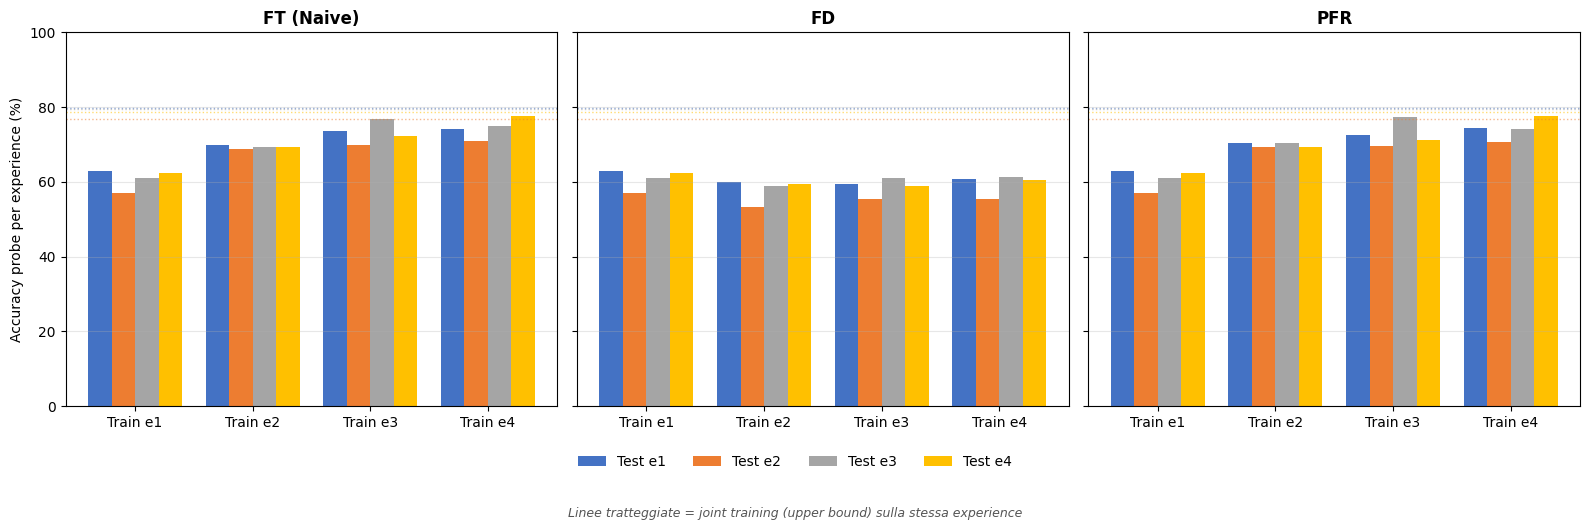

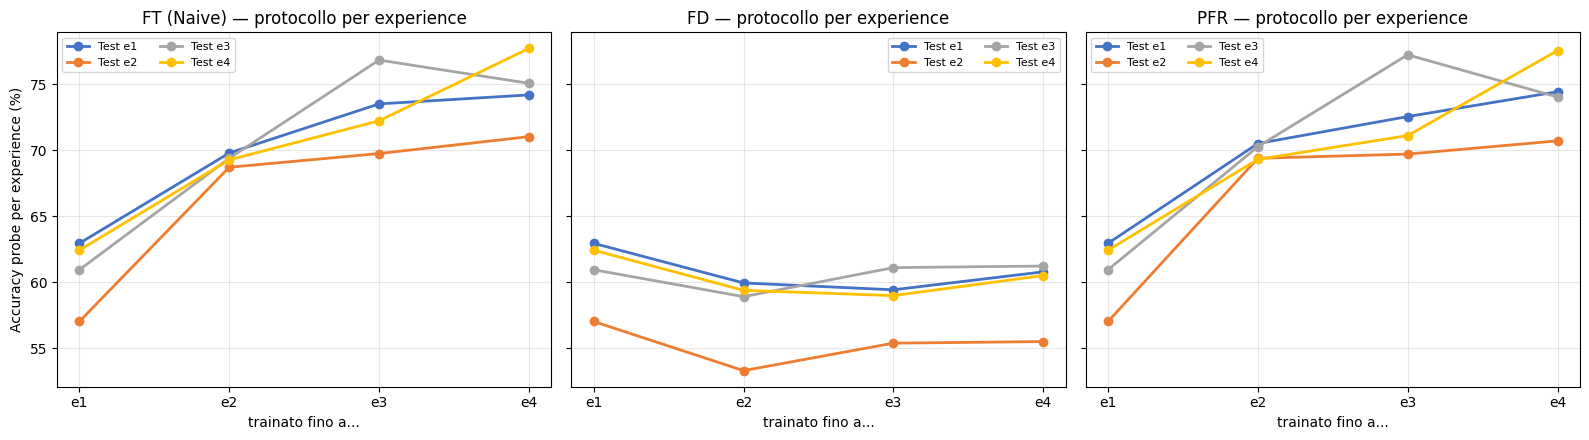

In [ ]:
import matplotlib.pyplot as plt

COLORI14 = ['#4472C4', '#ED7D31', '#A5A5A5', '#FFC000']

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharey=True)
for ax, (name, m) in zip(axes, [('FT (Naive)', 'ft'), ('FD', 'fd'), ('PFR', 'pfr')]):
    R = R14[m]
    x = np.arange(NT14)
    w = 0.8 / NT14
    for i in range(NT14):
        ax.bar(x + (i - (NT14 - 1) / 2) * w, R[:, i], w,
               label=f'Test e{i+1}', color=COLORI14[i % 4])
        ax.axhline(y=joint14[i], color=COLORI14[i % 4],
                   linestyle=':', linewidth=1, alpha=0.55)
    ax.set_title(name, fontweight='bold')
    ax.set_xticks(x); ax.set_xticklabels([f'Train e{t+1}' for t in range(NT14)])
    ax.set_ylim(0, 100)
    ax.grid(axis='y', alpha=0.3)
axes[0].set_ylabel('Accuracy probe per experience (%)')
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=NT14,
           bbox_to_anchor=(0.5, -0.08), frameon=False)
fig.text(0.5, -0.16, 'Linee tratteggiate = joint training (upper bound) sulla stessa experience',
         ha='center', fontsize=9, style='italic', color='#555')
plt.tight_layout()
plt.savefig('./R_per_experience.png', dpi=150, bbox_inches='tight')
plt.show()

# traiettorie: come evolve nel tempo l'accuracy di ogni experience
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharey=True)
x = np.arange(NT14)
for ax, (name, m) in zip(axes, [('FT (Naive)', 'ft'), ('FD', 'fd'), ('PFR', 'pfr')]):
    R = R14[m]
    for i in range(NT14):
        ax.plot(x, R[:, i], 'o-', color=COLORI14[i % 4], linewidth=2, label=f'Test e{i+1}')
    ax.set_title(f'{name} — protocollo per experience')
    ax.set_xticks(x); ax.set_xticklabels([f'e{t+1}' for t in range(NT14)])
    ax.set_xlabel('trainato fino a...')
    ax.grid(alpha=0.3); ax.legend(fontsize=8, ncol=2)
axes[0].set_ylabel('Accuracy probe per experience (%)')
plt.tight_layout()
plt.savefig('./traiettorie_per_experience.png', dpi=150, bbox_inches='tight')
plt.show()

## 10.3 I due esami fianco a fianco

Una domanda prima di andare avanti: e se l'anomalia dipendesse dall'esame? Se fosse il protocollo
a 100 classi a penalizzare FD, cambiando esame FD dovrebbe risalire in classifica. Qui mettiamo le
matrici dei due protocolli una accanto all'altra — **stessi checkpoint, stesse feature, due esami** —
e tre cose devono saltare all'occhio:

1. **tutti guadagnano, e più o meno lo stesso** (~15-20 punti): scegliere tra 25 alternative è più
   facile che tra 100, e il vantaggio è uguale per tutti;
2. **il ranking non cambia**: FT ≈ PFR sopra, FD sotto, in entrambi gli esami;
3. **le righe di FD restano piatte in entrambi**: non impara con nessun metro di misura.

Conclusione del confronto: l'esame è assolto — l'anomalia sta nel modello, non nella misura.

=== FT ===
        esame a 100 classi                   esame a 25 classi                  
                        e1    e2    e3    e4                e1    e2    e3    e4
dopo e1                NaN   NaN   NaN   NaN              63.0  57.0  61.0  62.4
dopo e2               49.0  49.1  48.4  48.3              69.8  68.7  69.4  69.3
dopo e3               52.0  48.4  55.6  53.1              73.5  69.8  76.8  72.2
dopo e4               54.6  49.2  52.9  59.2              74.2  71.0  75.1  77.7
media riga finale:  100 classi = 54.0%   25 classi = 74.5%   salto = +20.5

=== FD ===
        esame a 100 classi                   esame a 25 classi                  
                        e1    e2    e3    e4                e1    e2    e3    e4
dopo e1                NaN   NaN   NaN   NaN              63.0  57.0  61.0  62.4
dopo e2               43.0  37.2  36.9  40.2              60.0  53.3  58.9  59.4
dopo e3               42.2  38.5  39.3  41.0              59.4  55.4  61.1  59.0
dopo e4    

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


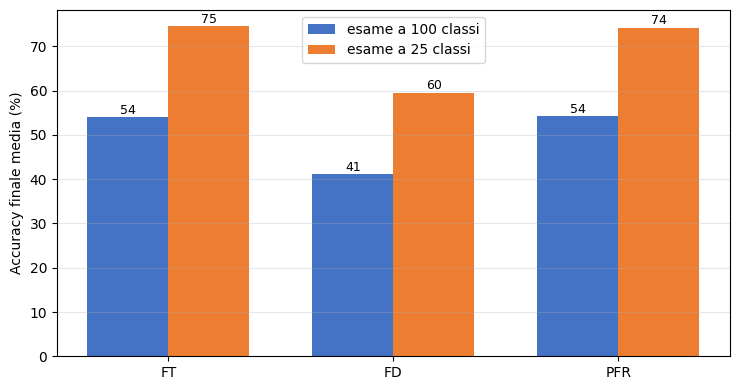

In [ ]:
# I due protocolli fianco a fianco: matrice a 100 classi  vs 25 classi
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

assert 'R_ft' in globals(), 'servono le R della Sez. 10.1'
assert 'R14' in globals(), 'servono le celle della Sez. 10.2'

etichette = [f'e{i+1}' for i in range(4)]
for nome, R100, chiave in [('FT', R_ft, 'ft'), ('FD', R_fd, 'fd'), ('PFR', R_pfr, 'pfr')]:
    R25 = R14[chiave]
    df = pd.DataFrame(np.hstack([R100, R25]).round(1),
                      index=[f'dopo e{t+1}' for t in range(4)],
                      columns=pd.MultiIndex.from_product(
                          [['esame a 100 classi', 'esame a 25 classi'], etichette]))
    print(f'=== {nome} ===')
    print(df.to_string())
    m100, m25 = np.nanmean(R100[3]), np.nanmean(R25[3])
    print(f'media riga finale:  100 classi = {m100:.1f}%   25 classi = {m25:.1f}%   salto = +{m25-m100:.1f}\n')

# riassunto grafico: accuracy finale media nei due esami
fig, ax = plt.subplots(figsize=(7.5, 4))
metodi = ['FT', 'FD', 'PFR']
a100 = [np.nanmean(R[3]) for R in (R_ft, R_fd, R_pfr)]
a25  = [np.nanmean(R14[k][3]) for k in ('ft', 'fd', 'pfr')]
x = np.arange(3)
ax.bar(x - 0.18, a100, 0.36, label='esame a 100 classi', color='#4472C4')
ax.bar(x + 0.18, a25,  0.36, label='esame a 25 classi',  color='#ED7D31')
for xi, (v1, v2) in zip(x, zip(a100, a25)):
    ax.text(xi - 0.18, v1 + 0.8, f'{v1:.0f}', ha='center', fontsize=9)
    ax.text(xi + 0.18, v2 + 0.8, f'{v2:.0f}', ha='center', fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(metodi)
ax.set_ylabel('Accuracy finale media (%)')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('./confronto_100_vs_25.png', dpi=150, bbox_inches='tight')
plt.show()

## 10.4 Le tre varianti della valutazione — prima il linear probing

C'è una scelta di protocollo rimasta finora implicita: quando classifico un campione di test,
**tra quali classi lo faccio scegliere?** Tre risposte possibili, che misurano cose diverse:

1. **Task-Aware** (l'oracolo): so a priori da quale task viene il campione e la scelta avviene solo
   tra le 25 classi di quel task. Misura la qualità delle feature task per task, senza confusione
   tra task diversi. È un upper bound.
2. **Seen-Pooled** (il setting realistico): non so da quale task viene il campione; la scelta avviene
   tra tutte le classi **viste finora** (25 → 50 → 75 → 100). La matrice è triangolare (i task futuri
   non sono in gallery). È la metrica che cattura più direttamente il catastrophic forgetting, perché
   classi vecchie e nuove competono tra loro.
3. **All-Pooled**: la scelta è sempre tra tutte le 100 classi, anche future. Misura la qualità
   assoluta dello spazio delle feature, indipendente dall'ordine del training.

Dove si collocano le valutazioni già fatte:

| Valutazione | Variante |
|---|---|
| Probe a 100 classi (Sez. 10.1, `main_linear.py`) | **All-Pooled** (allenato e testato su tutte le 100 classi, anche future) |
| Probe per experience (Sez. 10.2) | **Task-Aware** |
| kNN per experience (Sez. 10.5) | **Task-Aware** |

Qui completiamo il quadro per il **linear probing**: la Seen-Pooled (un probe per riga, allenato
sulle classi viste finora) e la All-Pooled ricalcolata sulle stesse feature in cache delle altre
varianti (stessa idea di `main_linear.py`, ma senza augmentation: così le tre varianti sono
confrontabili a parità di tutto). In fondo, i grafici a barre delle tre varianti in sequenza.

Attese: i valori calano da task-aware a seen-pooled a all-pooled (la scelta si allarga); nella
seen-pooled i task vecchi peggiorano riga dopo riga anche per la **confusione** con le classi nuove,
non solo per il forgetting; FD resta ultima ovunque.

=== Probe Seen-Pooled — FT ===
            e1     e2     e3     e4
dopo e1  62.96    NaN    NaN    NaN
dopo e2  60.88  59.56    NaN    NaN
dopo e3  59.32  55.44  60.12    NaN
dopo e4  55.84  52.40  55.76  60.76

=== Probe Seen-Pooled — FD ===
            e1     e2     e3     e4
dopo e1  62.96    NaN    NaN    NaN
dopo e2  50.64  46.04    NaN    NaN
dopo e3  45.40  40.72  44.84    NaN
dopo e4  43.52  38.72  41.40  42.32

=== Probe Seen-Pooled — PFR ===
            e1     e2     e3     e4
dopo e1  62.96    NaN    NaN    NaN
dopo e2  61.36  59.36    NaN    NaN
dopo e3  59.20  56.60  61.04    NaN
dopo e4  56.92  52.56  55.88  61.48



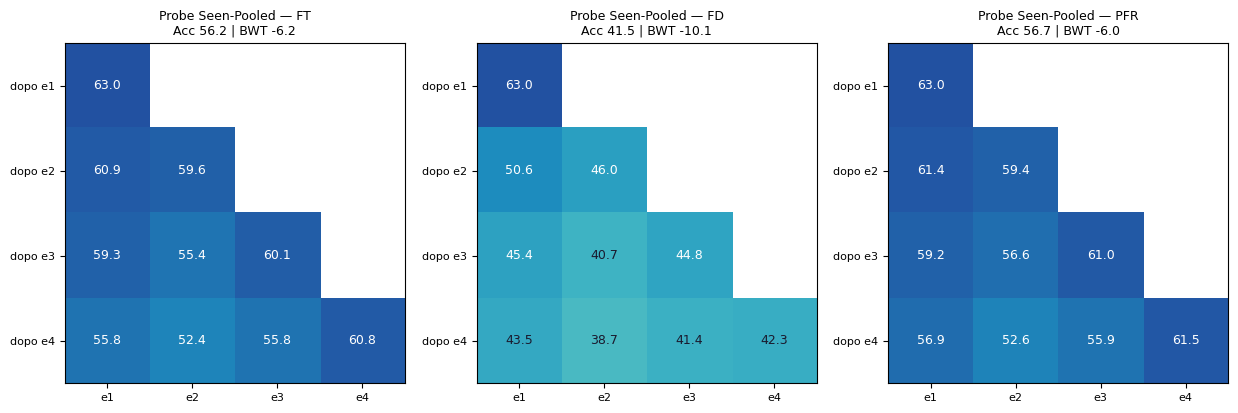

In [ ]:
# Probe lineare Seen-Pooled (la variante "realistica" anche per il linear probing)
# Un probe per riga: allenato sulle classi viste finora, testato su ogni task visto.
# ~12 probe da allenare: qualche minuto su GPU.
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

assert 'extract14' in globals(), 'servono le celle della Sez. 10.2'
DEV5b = DEVICE14 if 'DEVICE14' in globals() else ('cuda' if torch.cuda.is_available() else 'cpu')

def probe_addestrato(Xtr, ytr, n_cls, epochs=100, lr=0.1, bs=256):
    torch.manual_seed(0)
    probe = torch.nn.Linear(Xtr.shape[1], n_cls).to(DEV5b)
    opt = torch.optim.SGD(probe.parameters(), lr=lr, momentum=0.9)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    Xtr, ytr = Xtr.to(DEV5b), ytr.to(DEV5b)
    for ep in range(epochs):
        perm = torch.randperm(len(Xtr), device=DEV5b)
        for i in range(0, len(perm), bs):
            idx = perm[i:i + bs]
            loss = F.cross_entropy(probe(Xtr[idx]), ytr[idx])
            opt.zero_grad(); loss.backward(); opt.step()
        sched.step()
    return probe

R_probe_seen = {}
for met in ['ft', 'fd', 'pfr']:
    R = np.full((4, 4), np.nan)
    cks = {0: CKPTS14['task0'][0]}
    cks.update({t: CKPTS14[met][t] for t in (1, 2, 3) if t in CKPTS14[met]})
    for t, ck in cks.items():
        ftr, ytr, fte, yte = extract14(ck)
        cls_seen = torch.cat(TASKS14[:t + 1])
        lut = {int(c): j for j, c in enumerate(cls_seen)}
        mtr = torch.isin(ytr, cls_seen)
        ytr_loc = torch.tensor([lut[int(v)] for v in ytr[mtr]])
        probe = probe_addestrato(ftr[mtr], ytr_loc, len(cls_seen))
        with torch.no_grad():
            for i in range(t + 1):
                mte = torch.isin(yte, TASKS14[i])
                yte_loc = torch.tensor([lut[int(v)] for v in yte[mte]])
                pred = probe(fte[mte].to(DEV5b)).argmax(1).cpu()
                R[t, i] = (pred == yte_loc).float().mean().item() * 100
    R_probe_seen[met] = R
    print(f'=== Probe Seen-Pooled — {met.upper()} ===')
    print(pd.DataFrame(R, index=[f'dopo e{t+1}' for t in range(4)],
                       columns=[f'e{i+1}' for i in range(4)]).round(2))
    print()

fig, axes = plt.subplots(1, 3, figsize=(12.5, 4))
for ax, (nome_m, met) in zip(axes, [('FT', 'ft'), ('FD', 'fd'), ('PFR', 'pfr')]):
    R = R_probe_seen[met]
    acc = np.nanmean(R[3])
    bwt = np.nanmean([R[3, i] - R[i, i] for i in range(3)])
    heatmap_R(ax, R, f'Probe Seen-Pooled — {nome_m}\nAcc {acc:.1f} | BWT {bwt:+.1f}')
plt.tight_layout()
plt.savefig('./probe_seen_pooled.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Probe All-Pooled sulle feature in cache: un probe a 100 classi per checkpoint, testato per task
# (12 probe da allenare su ~50k campioni ciascuno: ~20-30 min su GPU)
import numpy as np
import pandas as pd
import torch

assert 'probe_addestrato' in globals(), 'esegui prima la cella del probe Seen-Pooled (definisce probe_addestrato)'

R_probe_all = {}
for met in ['ft', 'fd', 'pfr']:
    R = np.full((4, 4), np.nan)
    cks = {0: CKPTS14['task0'][0]}
    cks.update({t: CKPTS14[met][t] for t in (1, 2, 3) if t in CKPTS14[met]})
    for t, ck in cks.items():
        ftr, ytr, fte, yte = extract14(ck)
        probe = probe_addestrato(ftr, ytr, 100, bs=512)   # etichette globali 0..99
        with torch.no_grad():
            for i in range(4):
                mte = torch.isin(yte, TASKS14[i])
                pred = probe(fte[mte].to(DEV5b)).argmax(1).cpu()
                R[t, i] = (pred == yte[mte]).float().mean().item() * 100
    R_probe_all[met] = R
    print(f'=== Probe All-Pooled — {met.upper()} ===')
    print(pd.DataFrame(R, index=[f'dopo e{t+1}' for t in range(4)],
                       columns=[f'e{i+1}' for i in range(4)]).round(2))
    print()

=== Probe All-Pooled — FT ===
            e1     e2     e3     e4
dopo e1  43.96  38.48  43.56  43.44
dopo e2  51.28  51.12  50.68  52.40
dopo e3  54.92  51.60  58.28  56.56
dopo e4  56.80  52.76  55.96  60.64



/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


=== Probe All-Pooled — FD ===
            e1     e2     e3     e4
dopo e1  43.96  38.48  43.56  43.44
dopo e2  43.80  38.64  42.24  43.96
dopo e3  44.20  39.72  44.28  44.52
dopo e4  45.32  40.36  43.04  44.44



/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


=== Probe All-Pooled — PFR ===
            e1     e2     e3     e4
dopo e1  43.96  38.48  43.56  43.44
dopo e2  52.16  51.12  51.32  51.40
dopo e3  54.96  52.96  58.44  55.28
dopo e4  58.04  53.92  56.48  61.96



/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


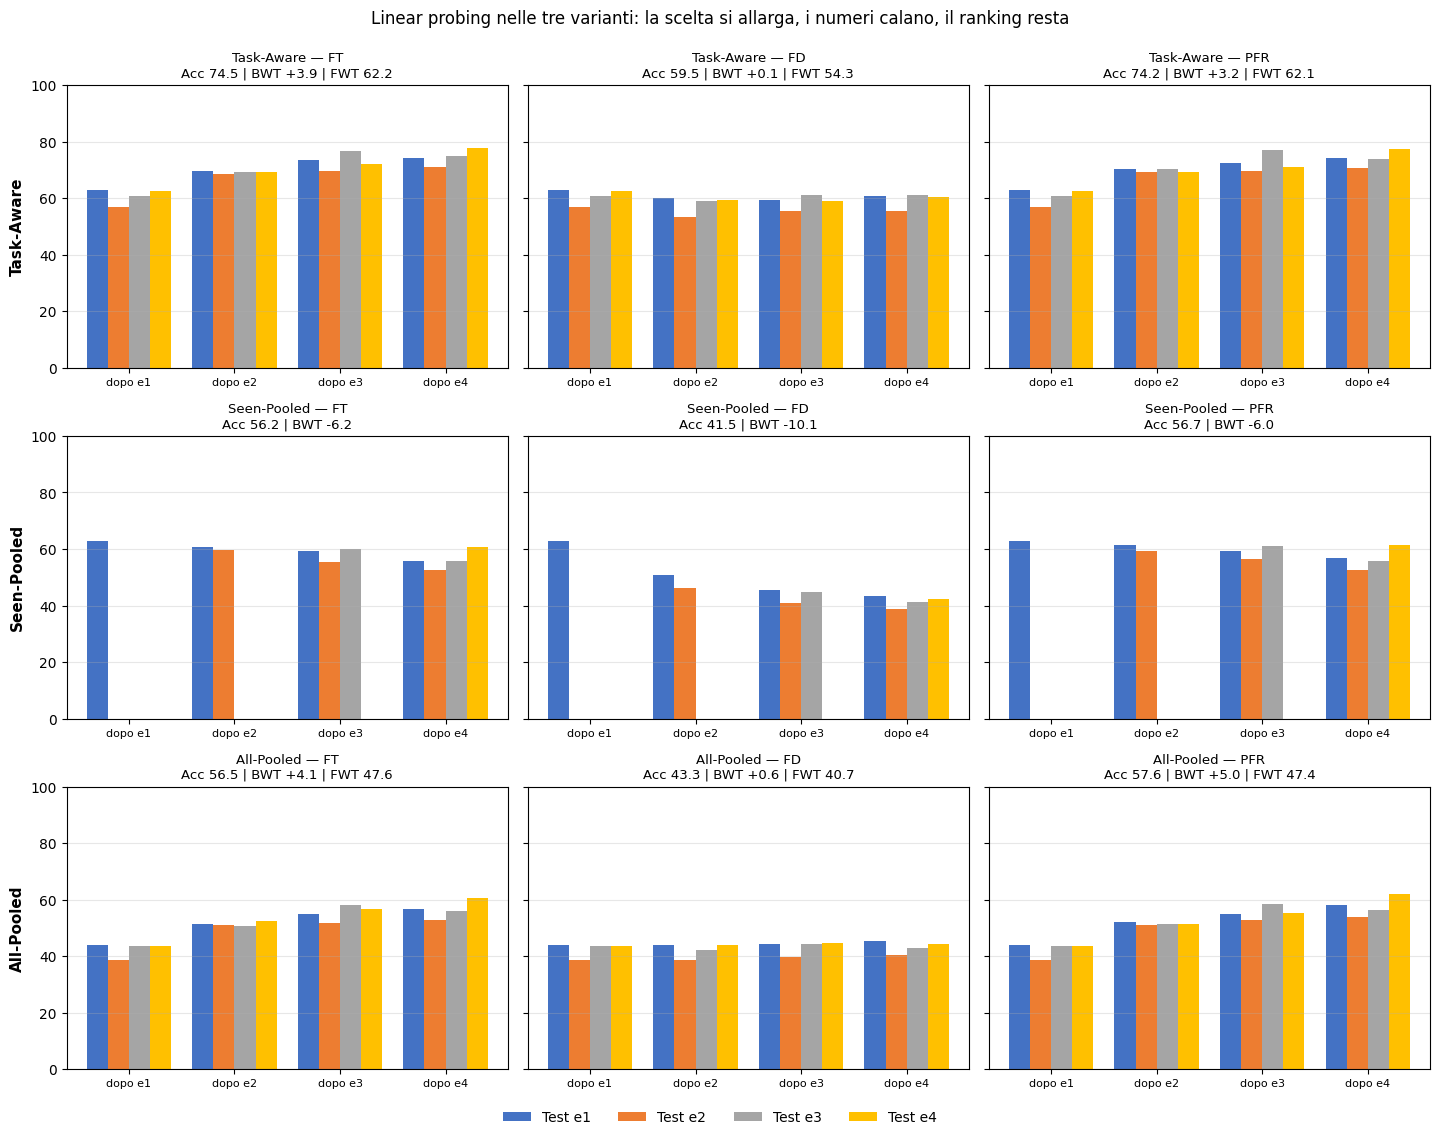

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# Grafici a barre: il linear probing nelle tre varianti, in sequenza
import numpy as np
import matplotlib.pyplot as plt

assert 'R14' in globals() and 'R_probe_seen' in globals() and 'R_probe_all' in globals(), \
    'servono: Sez. 10.2 (task-aware), probe Seen-Pooled e probe All-Pooled'

COL_V = ['#4472C4', '#ED7D31', '#A5A5A5', '#FFC000']

def barre_variante(ax, R, titolo, vmax=100):
    x = np.arange(4)
    wb = 0.8 / 4
    for i in range(4):
        ax.bar(x + (i - 1.5) * wb, R[:, i], wb, color=COL_V[i], label=f'Test e{i+1}')
    ax.set_xticks(x)
    ax.set_xticklabels([f'dopo e{t+1}' for t in range(4)], fontsize=8)
    ax.set_ylim(0, vmax)
    ax.grid(axis='y', alpha=0.3)
    ax.set_title(titolo, fontsize=9.5)

VARIANTI_P = [('Task-Aware', {m: R14[m] for m in ('ft', 'fd', 'pfr')}, 4.0),
              ('Seen-Pooled', R_probe_seen, None),
              ('All-Pooled', R_probe_all, 1.0)]

fig, axes = plt.subplots(3, 3, figsize=(14.5, 11), sharey=True)
for r, (nome_v, Rd, b_rand) in enumerate(VARIANTI_P):
    for c, (nome_m, met) in enumerate([('FT', 'ft'), ('FD', 'fd'), ('PFR', 'pfr')]):
        R = Rd[met]
        acc = np.nanmean(R[3])
        bwt = np.nanmean([R[3, i] - R[i, i] for i in range(3)])
        fwt = '' if b_rand is None else f' | FWT {np.nanmean([R[i-1, i] - b_rand for i in range(1, 4)]):.1f}'
        barre_variante(axes[r, c], R, f'{nome_v} — {nome_m}\nAcc {acc:.1f} | BWT {bwt:+.1f}{fwt}')
    axes[r, 0].set_ylabel(nome_v, fontsize=11, fontweight='bold')
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=4, bbox_to_anchor=(0.5, -0.03), frameon=False)
fig.suptitle('Linear probing nelle tre varianti: la scelta si allarga, i numeri calano, il ranking resta', y=0.995)
plt.tight_layout()
plt.savefig('./probe_tre_varianti_barre.png', dpi=150, bbox_inches='tight')
plt.show()

## 10.5 Le stesse tre varianti per il kNN

Ripetiamo il percorso con il secondo strumento. Prima la **task-aware con la classe del repo**
(`WeightedKNNClassifier`, k=20, distanza euclidea, come configurata in `methods/base.py` — la
valutazione che i run avevano disattivato con `--disable_knn_eval`). Poi le **tre varianti a
confronto**: per le gallery pooled la regola di voto è la stessa (k=20, voto pesato con l'inverso
della distanza), riscritta in poche righe perché la classe del repo assume che le classi del test
coincidano con quelle della gallery — cosa vera solo nel caso task-aware.

Il kNN non allena nulla: per classificare un campione cerca le 20 immagini di training più vicine
nello spazio delle feature e fa votare la loro classe, con voto pesato. Se probe e kNN raccontano la
stessa storia nelle stesse tre varianti, il verdetto non dipende dallo strumento di misura.

In [ ]:
# kNN evaluation per experience, con la classe del repo (cassle/utils/knn.py)
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from cassle.utils.knn import WeightedKNNClassifier   # la stessa classe che i run disattivavano

assert 'extract14' in globals() and 'metriche_cl14' in globals(), \
    'servono le celle della Sez. 10.2 (setup, probe e metriche) eseguite in questa sessione'

def knn_accs_per_experience(ckpt_path, k=20):
    # stessa configurazione con cui il repo la usa in methods/base.py:
    # WeightedKNNClassifier(k=20, distance_fx="euclidean"), voto pesato 1/distanza
    ftr, ytr, fte, yte = extract14(ckpt_path)          # dalla cache: gratis
    accs = []
    for classes in TASKS14:
        lut = {int(c): j for j, c in enumerate(classes)}
        mtr = torch.isin(ytr, classes)
        mte = torch.isin(yte, classes)
        knn = WeightedKNNClassifier(k=k, distance_fx='euclidean')
        knn.update(train_features=ftr[mtr],
                   train_targets=torch.tensor([lut[int(c)] for c in ytr[mtr]]))
        knn.update(test_features=fte[mte],
                   test_targets=torch.tensor([lut[int(c)] for c in yte[mte]]))
        top1, top5 = knn.compute()
        accs.append(top1)
    return accs

NTK = 4
R_knn = {}
for met in ['ft', 'fd', 'pfr']:
    R = np.full((NTK, NTK), np.nan)
    R[0, :] = knn_accs_per_experience(CKPTS14['task0'][0])
    for t in range(1, NTK):
        if t in CKPTS14[met]:
            R[t, :] = knn_accs_per_experience(CKPTS14[met][t])
    R_knn[met] = R
joint_knn = (np.array(knn_accs_per_experience(CKPTS14['joint'][0]))
             if CKPTS14['joint'] else np.full(NTK, np.nan))

idxk = [f'dopo e{t+1}' for t in range(NTK)]
colk = [f'e{i+1}' for i in range(NTK)]
for nome, met in [('FT', 'ft'), ('FD', 'fd'), ('PFR', 'pfr')]:
    print(f'=== R (kNN, k=20, per experience) — {nome} ===')
    print(pd.DataFrame(R_knn[met], index=idxk, columns=colk).round(2))
    print()
print('Joint (kNN):', np.round(joint_knn, 2), '\n')

# metriche della lezione: ACC, BWT e Forward Transfer (random = 4%, 25 classi)
tab_knn = {n: metriche_cl14(R_knn[m]) for n, m in [('FT', 'ft'), ('FD', 'fd'), ('PFR', 'pfr')]}
df_knn = pd.DataFrame(tab_knn).T.round(2)
print('=== Metriche CL (kNN per experience) ===')
print(df_knn)
print()
print('Da confrontare con le metriche del probe (Sez. 10.2): se ranking e forma delle')
print('R-matrix coincidono, il verdetto non dipende dallo strumento di misura.')

=== R (kNN, k=20, per experience) — FT ===
            e1     e2     e3     e4
dopo e1  56.48  46.52  53.72  51.44
dopo e2  63.00  62.88  62.80  61.24
dopo e3  67.20  62.32  73.08  65.36
dopo e4  69.32  62.44  69.36  74.20

=== R (kNN, k=20, per experience) — FD ===
            e1     e2     e3     e4
dopo e1  56.48  46.52  53.72  51.44
dopo e2  57.36  48.64  54.92  52.00
dopo e3  57.60  47.84  55.44  51.28
dopo e4  57.76  48.12  56.04  52.44

=== R (kNN, k=20, per experience) — PFR ===
            e1     e2     e3     e4
dopo e1  56.48  46.52  53.72  51.44
dopo e2  63.76  62.32  62.80  61.08
dopo e3  67.16  62.12  72.68  65.76
dopo e4  68.60  61.84  69.04  73.44

Joint (kNN): [75.72 69.36 73.8  73.56] 

=== Metriche CL (kNN per experience) ===
     ACC_final  ACC_avg  BWT_final  BWT_avg    FWT
FT       68.83    66.03       2.89     4.23  54.23
FD       53.59    53.77       0.45     0.43  46.91
PFR      68.23    65.74       2.67     4.29  54.36

Da confrontare con le metriche del probe

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


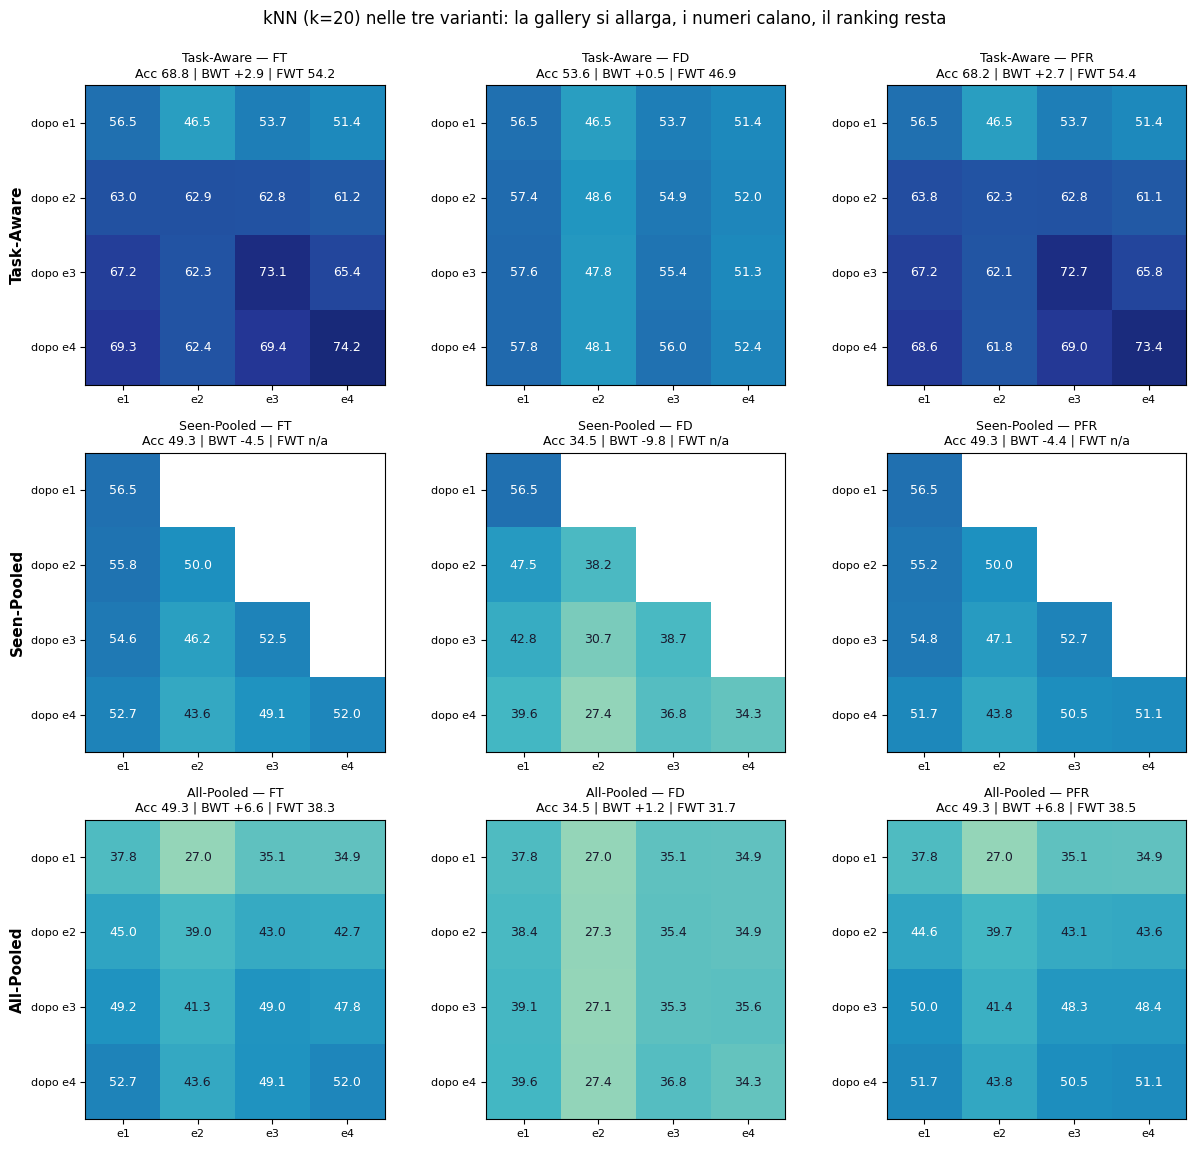

Task-Aware qui vs Sez. 10.4 (classe del repo) — FT, riga finale:
  qui   : [69.32 62.44 69.36 74.2 ]
  10.4  : (cella 10.4 non in sessione)


In [ ]:
# Le tre varianti del kNN, come heatmap (formato N x N, con Acc/BWT/FWT nel titolo)
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

assert 'extract14' in globals() and 'metriche_cl14' in globals(), 'servono le celle della Sez. 10.2'
DEV5 = DEVICE14 if 'DEVICE14' in globals() else ('cuda' if torch.cuda.is_available() else 'cpu')

def knn_vota(Xtr, ytr, Xte, k=20, chunk=512):
    # stessa regola del repo: k=20, voto pesato 1/(distanza euclidea)
    uniq, ytr_c = ytr.unique(return_inverse=True)
    preds = []
    for i in range(0, len(Xte), chunk):
        d = torch.cdist(Xte[i:i + chunk], Xtr)
        w, idx = (1.0 / (d + 1e-5)).topk(min(k, len(Xtr)), dim=1)
        voti = torch.zeros(len(w), len(uniq), device=Xtr.device)
        voti.scatter_add_(1, ytr_c[idx], w)
        preds.append(uniq[voti.argmax(1)])
    return torch.cat(preds)

def R_knn_variante(met, modo, k=20):
    R = np.full((4, 4), np.nan)
    cks = {0: CKPTS14['task0'][0]}
    cks.update({t: CKPTS14[met][t] for t in (1, 2, 3) if t in CKPTS14[met]})
    for t, ck in cks.items():
        ftr, ytr, fte, yte = extract14(ck)
        ftr, ytr = ftr.to(DEV5), ytr.to(DEV5)
        fte, yte = fte.to(DEV5), yte.to(DEV5)
        test_tasks = range(t + 1) if modo == 'seen' else range(4)
        for i in test_tasks:
            cls_test = TASKS14[i].to(DEV5)
            if modo == 'aware':
                cls_gal = cls_test
            elif modo == 'seen':
                cls_gal = torch.cat(TASKS14[:t + 1]).to(DEV5)
            else:
                cls_gal = torch.arange(100, device=DEV5)
            mtr = torch.isin(ytr, cls_gal)
            mte = torch.isin(yte, cls_test)
            pred = knn_vota(ftr[mtr], ytr[mtr], fte[mte], k)
            R[t, i] = (pred == yte[mte]).float().mean().item() * 100
    return R

def heatmap_R(ax, R, titolo, vmax=80):
    ax.imshow(R, cmap='YlGnBu', vmin=0, vmax=vmax)
    for a in range(4):
        for b in range(4):
            if not np.isnan(R[a, b]):
                ax.text(b, a, f'{R[a, b]:.1f}', ha='center', va='center', fontsize=9,
                        color='white' if R[a, b] > 0.55 * vmax else '#1a1a2e')
    ax.set_xticks(range(4)); ax.set_xticklabels([f'e{i+1}' for i in range(4)], fontsize=8)
    ax.set_yticks(range(4)); ax.set_yticklabels([f'dopo e{t+1}' for t in range(4)], fontsize=8)
    ax.set_title(titolo, fontsize=9)

VARIANTI5 = [('aware', 'Task-Aware', 4.0), ('seen', 'Seen-Pooled', None), ('all', 'All-Pooled', 1.0)]
R_var = {}
fig, axes = plt.subplots(3, 3, figsize=(12.5, 11.5))
for r, (modo, nome_v, b_rand) in enumerate(VARIANTI5):
    for c, (nome_m, met) in enumerate([('FT', 'ft'), ('FD', 'fd'), ('PFR', 'pfr')]):
        R = R_knn_variante(met, modo)
        R_var[(modo, met)] = R
        acc = np.nanmean(R[3])
        bwt = np.nanmean([R[3, i] - R[i, i] for i in range(3)])
        fwt = 'n/a' if b_rand is None else f'{np.nanmean([R[i-1, i] - b_rand for i in range(1, 4)]):.1f}'
        heatmap_R(axes[r, c], R, f'{nome_v} — {nome_m}\nAcc {acc:.1f} | BWT {bwt:+.1f} | FWT {fwt}')
for r, (_, nome_v, _) in enumerate(VARIANTI5):
    axes[r, 0].set_ylabel(nome_v, fontsize=11, fontweight='bold')
fig.suptitle('kNN (k=20) nelle tre varianti: la gallery si allarga, i numeri calano, il ranking resta', y=0.995)
plt.tight_layout()
plt.savefig('./knn_tre_varianti.png', dpi=150, bbox_inches='tight')
plt.show()

# controllo di coerenza: la variante task-aware deve coincidere (a meno di decimali)
# con la Sez. 10.4 calcolata con la classe del repo
print('Task-Aware qui vs kNN con la classe del repo — FT, riga finale:')
print('  qui   :', np.round(R_var[('aware', 'ft')][3], 2))
print('  10.4  :', np.round(R_knn['ft'][3], 2) if 'R_knn' in globals() else '(cella kNN repo non in sessione)')

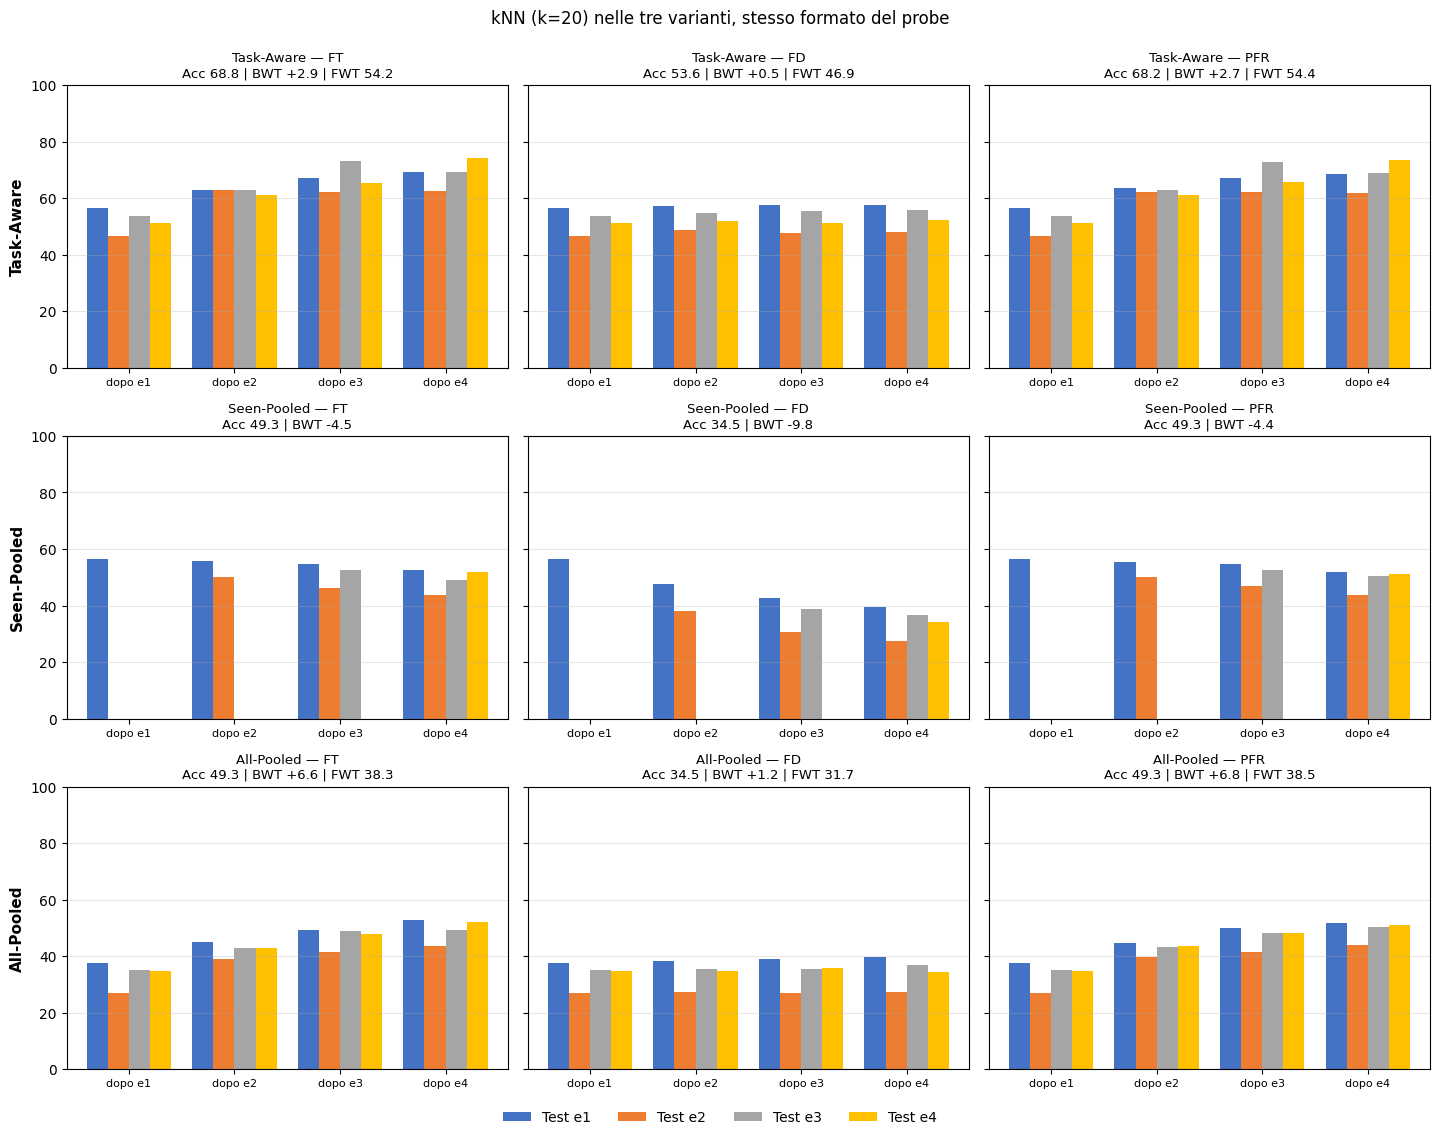

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# Grafici a barre: il kNN nelle tre varianti, in sequenza
import numpy as np
import matplotlib.pyplot as plt

assert 'R_var' in globals(), 'esegui prima la cella delle heatmap (calcola R_var)'

VARIANTI_K = [('aware', 'Task-Aware', 4.0), ('seen', 'Seen-Pooled', None), ('all', 'All-Pooled', 1.0)]
fig, axes = plt.subplots(3, 3, figsize=(14.5, 11), sharey=True)
for r, (modo, nome_v, b_rand) in enumerate(VARIANTI_K):
    for c, (nome_m, met) in enumerate([('FT', 'ft'), ('FD', 'fd'), ('PFR', 'pfr')]):
        R = R_var[(modo, met)]
        acc = np.nanmean(R[3])
        bwt = np.nanmean([R[3, i] - R[i, i] for i in range(3)])
        fwt = '' if b_rand is None else f' | FWT {np.nanmean([R[i-1, i] - b_rand for i in range(1, 4)]):.1f}'
        barre_variante(axes[r, c], R, f'{nome_v} — {nome_m}\nAcc {acc:.1f} | BWT {bwt:+.1f}{fwt}')
    axes[r, 0].set_ylabel(nome_v, fontsize=11, fontweight='bold')
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=4, bbox_to_anchor=(0.5, -0.03), frameon=False)
fig.suptitle('kNN (k=20) nelle tre varianti, stesso formato del probe', y=0.995)
plt.tight_layout()
plt.savefig('./knn_tre_varianti_barre.png', dpi=150, bbox_inches='tight')
plt.show()

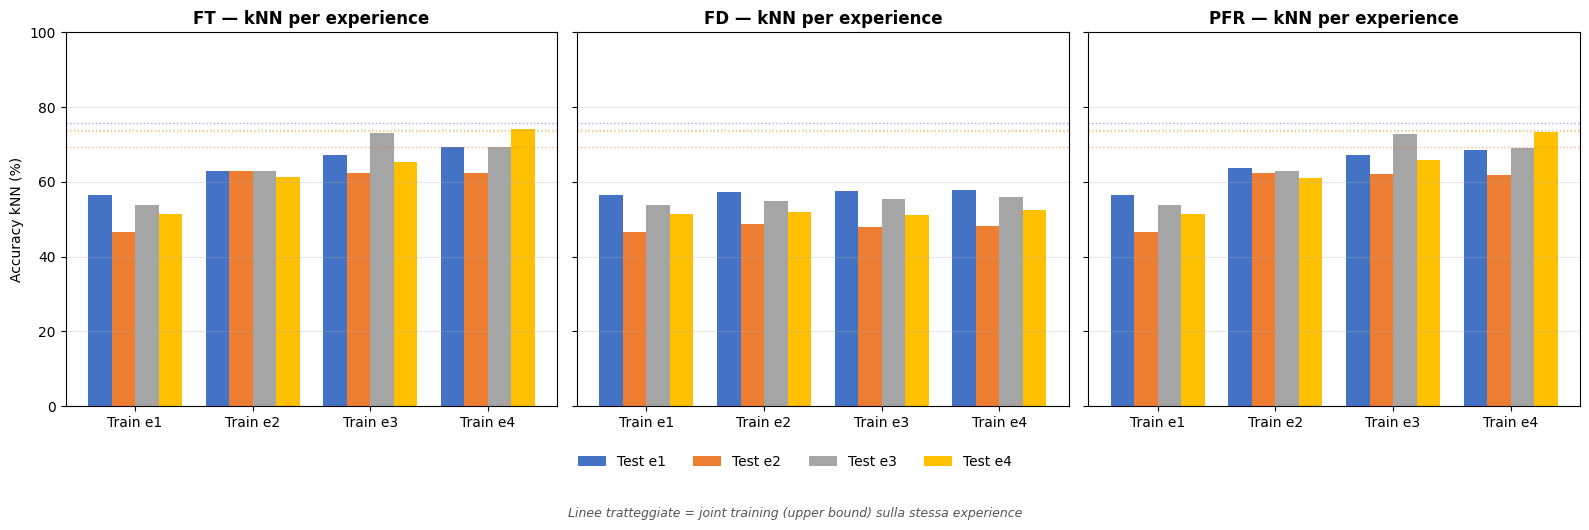

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


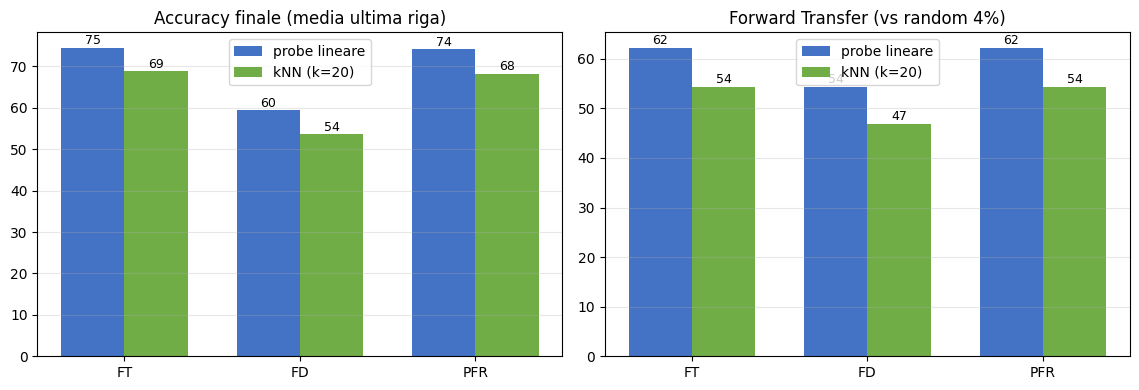

In [ ]:
# Diagrammi a barre della kNN evaluation, nello stesso formato del probe
COLORI_KNN = ['#4472C4', '#ED7D31', '#A5A5A5', '#FFC000']

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharey=True)
for ax, (nome, met) in zip(axes, [('FT', 'ft'), ('FD', 'fd'), ('PFR', 'pfr')]):
    R = R_knn[met]
    x = np.arange(NTK)
    wb = 0.8 / NTK
    for i in range(NTK):
        ax.bar(x + (i - (NTK - 1) / 2) * wb, R[:, i], wb,
               label=f'Test e{i+1}', color=COLORI_KNN[i])
        ax.axhline(joint_knn[i], color=COLORI_KNN[i], ls=':', lw=1, alpha=0.55)
    ax.set_title(f'{nome} — kNN per experience', fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels([f'Train e{t+1}' for t in range(NTK)])
    ax.set_ylim(0, 100)
    ax.grid(axis='y', alpha=0.3)
axes[0].set_ylabel('Accuracy kNN (%)')
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=NTK, bbox_to_anchor=(0.5, -0.08), frameon=False)
fig.text(0.5, -0.16, 'Linee tratteggiate = joint training (upper bound) sulla stessa experience',
         ha='center', fontsize=9, style='italic', color='#555')
plt.tight_layout()
plt.savefig('./R_knn_per_experience.png', dpi=150, bbox_inches='tight')
plt.show()

# riassunto: accuracy finale e Forward Transfer, kNN accanto al probe
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4))
nomi = ['FT', 'FD', 'PFR']
x = np.arange(3)
acc_probe = [metriche_cl14(R14[m])['ACC_final'] for m in ('ft', 'fd', 'pfr')]
acc_knn   = [tab_knn[n]['ACC_final'] for n in nomi]
fwt_probe = [metriche_cl14(R14[m])['FWT'] for m in ('ft', 'fd', 'pfr')]
fwt_knn   = [tab_knn[n]['FWT'] for n in nomi]

for ax, probe_v, knn_v, titolo in [(axes[0], acc_probe, acc_knn, 'Accuracy finale (media ultima riga)'),
                                   (axes[1], fwt_probe, fwt_knn, 'Forward Transfer (vs random 4%)')]:
    ax.bar(x - 0.18, probe_v, 0.36, label='probe lineare', color='#4472C4')
    ax.bar(x + 0.18, knn_v, 0.36, label='kNN (k=20)', color='#70AD47')
    for xi, (v1, v2) in zip(x, zip(probe_v, knn_v)):
        ax.text(xi - 0.18, v1 + 0.8, f'{v1:.0f}', ha='center', fontsize=9)
        ax.text(xi + 0.18, v2 + 0.8, f'{v2:.0f}', ha='center', fontsize=9)
    ax.set_xticks(x)
    ax.set_xticklabels(nomi)
    ax.set_title(titolo)
    ax.grid(axis='y', alpha=0.3)
    ax.legend()
plt.tight_layout()
plt.savefig('./knn_vs_probe.png', dpi=150, bbox_inches='tight')
plt.show()

---

# 11. Plot di confronto


In [ ]:
def build_R(method, num_tasks=NUM_TASKS):
    R = np.full((num_tasks, num_tasks), np.nan)
    for run in runs:
        name = run.name
        m = re.match(rf'linear_{method}_T(\d+)$', name)
        if m:
            R[int(m.group(1)), :] = get_per_task_acc(run, num_tasks)
        elif name in ('linear_t0', 'linear_task0'):   # <-- match corretto della base
            R[0, :] = get_per_task_acc(run, num_tasks)
    return R

R_ft  = build_R('ft')
R_fd  = build_R('fd')
R_pfr = build_R('pfr')
# verifica che la riga 0 non sia piu' NaN:
print(pd.DataFrame(R_pfr, index=[f'after_T{t}' for t in range(NUM_TASKS)],
                   columns=[f'task{i}' for i in range(NUM_TASKS)]).round(2))

          task0  task1  task2  task3
after_T0  42.72  36.24  36.08  39.72
after_T1  49.68  47.64  47.52  48.08
after_T2  53.00  48.72  56.28  51.80
after_T3  54.76  50.68  52.44  59.08


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


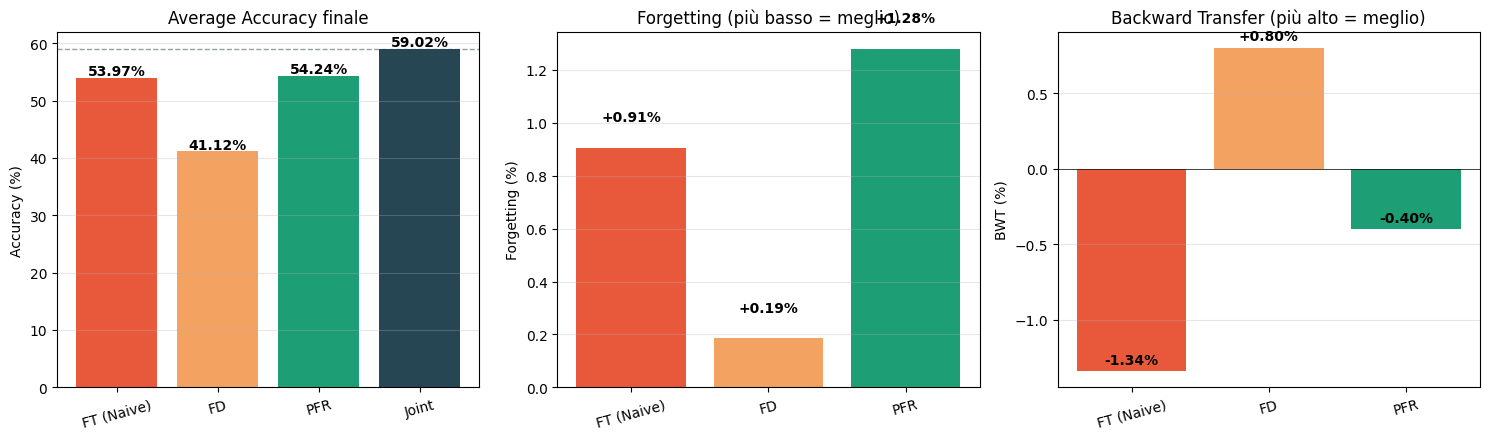

In [ ]:
import matplotlib.pyplot as plt

continual_methods = ['FT (Naive)', 'FD', 'PFR']
all_methods       = continual_methods + ['Joint']
continual_colors  = ['#E8593C', '#F4A261', '#1D9E75']
all_colors        = continual_colors + ['#264653']  # joint in blu scuro

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# Avg Accuracy: tutti e 4 i metodi (joint come upper bound)
ax = axes[0]
vals = [metrics[m]['Avg Acc'] for m in all_methods]
bars = ax.bar(all_methods, vals, color=all_colors)
for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{v:.2f}%', ha='center', fontweight='bold')
# Linea di riferimento al livello del joint
ax.axhline(y=metrics['Joint']['Avg Acc'], color='#264653',
           linestyle='--', linewidth=1, alpha=0.5, label='Joint (upper bound)')
ax.set_title('Average Accuracy finale')
ax.set_ylabel('Accuracy (%)')
ax.grid(axis='y', alpha=0.3)
ax.tick_params(axis='x', rotation=15)

# Forgetting: solo metodi continual (Joint non e' definito)
ax = axes[1]
vals = [metrics[m]['Forgetting'] for m in continual_methods]
bars = ax.bar(continual_methods, vals, color=continual_colors)
for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{v:+.2f}%', ha='center', fontweight='bold')
ax.axhline(y=0, color='black', linewidth=0.5)
ax.set_title('Forgetting (più basso = meglio)')
ax.set_ylabel('Forgetting (%)')
ax.grid(axis='y', alpha=0.3)
ax.tick_params(axis='x', rotation=15)

# BWT: solo metodi continual
ax = axes[2]
vals = [metrics[m]['BWT'] for m in continual_methods]
bars = ax.bar(continual_methods, vals, color=continual_colors)
for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{v:+.2f}%', ha='center', fontweight='bold')
ax.axhline(y=0, color='black', linewidth=0.5)
ax.set_title('Backward Transfer (più alto = meglio)')
ax.set_ylabel('BWT (%)')
ax.grid(axis='y', alpha=0.3)
ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('./confronto_metriche.png', dpi=150, bbox_inches='tight')
plt.show()

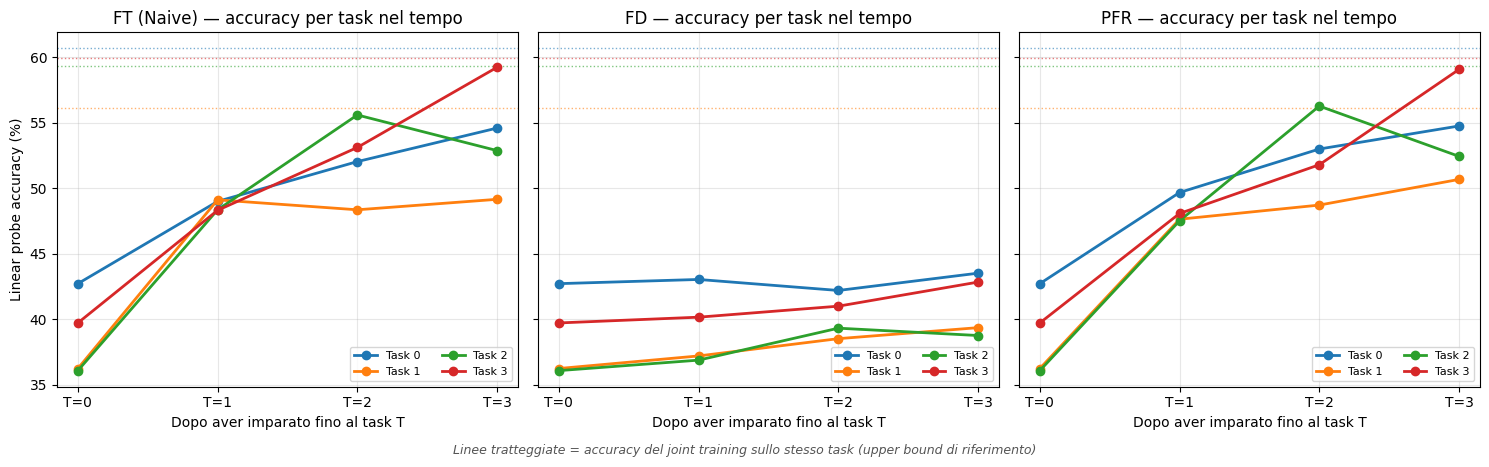

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# Traiettorie: per ogni metodo continual, accuracy di ogni task nel tempo.
# Joint non ha traiettoria (single shot), lo mostro come linee orizzontali tratteggiate di riferimento.
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)
task_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
x = np.arange(NUM_TASKS)

for ax, (name, R) in zip(axes, [('FT (Naive)', R_ft), ('FD', R_fd), ('PFR', R_pfr)]):
    for i in range(NUM_TASKS):
        ax.plot(x, R[:, i], 'o-', color=task_colors[i], label=f'Task {i}', linewidth=2)
        # Reference line: accuracy del joint sullo stesso task
        ax.axhline(y=joint_accs[i], color=task_colors[i],
                   linestyle=':', linewidth=1, alpha=0.6)
    ax.set_title(f'{name} — accuracy per task nel tempo')
    ax.set_xlabel('Dopo aver imparato fino al task T')
    ax.set_xticks(x)
    ax.set_xticklabels([f'T={t}' for t in x])
    ax.grid(alpha=0.3)
    ax.legend(loc='best', ncol=2, fontsize=8)
axes[0].set_ylabel('Linear probe accuracy (%)')

# Annotazione esplicativa
fig.text(0.5, -0.02,
         'Linee tratteggiate = accuracy del joint training sullo stesso task (upper bound di riferimento)',
         ha='center', fontsize=9, style='italic', color='#555')

plt.tight_layout()
plt.savefig('./traiettorie_per_task.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
def metriche_cl(R, b_random=4.0):
    """
    Metriche CL con le formule viste a lezione.
    R[t, i] = accuracy sul test della experience i dopo aver trainato fino alla experience t.
    b_random = accuracy del modello random (25 classi/task -> 4%). Usata solo per FWT.
    """
    N = R.shape[0]

    # Final Accuracy (p.17): media ultima riga
    acc_final = np.nanmean(R[N-1, :])

    # Average Accuracy over time (p.18): media del triangolo inferiore (diagonale inclusa)
    tri = [R[i, j] for i in range(N) for j in range(i+1)]
    acc_avg = np.nansum(tri) / (N*(N+1)/2)

    # Final BWT (p.19): media su i<N-1 di (R[N-1,i] - R[i,i])
    bwt_final = np.nanmean([R[N-1, i] - R[i, i] for i in range(N-1)])

    # Average BWT over time (p.20)
    bwt_terms = [R[i, j] - R[j, j] for i in range(1, N) for j in range(i)]
    bwt_avg = np.nansum(bwt_terms) / (N*(N-1)/2)

    # Forward Transfer (p.21): media su i>=1 di (R[i-1,i] - b_random)
    fwt = np.nanmean([R[i-1, i] - b_random for i in range(1, N)])

    return {'ACC_final': acc_final, 'ACC_avg': acc_avg,
            'BWT_final': bwt_final, 'BWT_avg': bwt_avg, 'FWT': fwt}

metrics = {}
for name, R in [('FT (Naive)', R_ft), ('FD', R_fd), ('PFR', R_pfr)]:
    metrics[name] = metriche_cl(R)
metrics['Joint'] = {'ACC_final': float(np.nanmean(joint_accs)),
                    'ACC_avg': np.nan, 'BWT_final': np.nan,
                    'BWT_avg': np.nan, 'FWT': np.nan}

df = pd.DataFrame(metrics).T.round(2)
print(df)

            ACC_final  ACC_avg  BWT_final  BWT_avg    FWT
FT (Naive)      53.97    51.27       3.07     4.01  41.91
FD              41.12    40.75       0.80     0.59  34.04
PFR             54.24    51.50       3.75     4.93  41.19
Joint           59.02      NaN        NaN      NaN    NaN


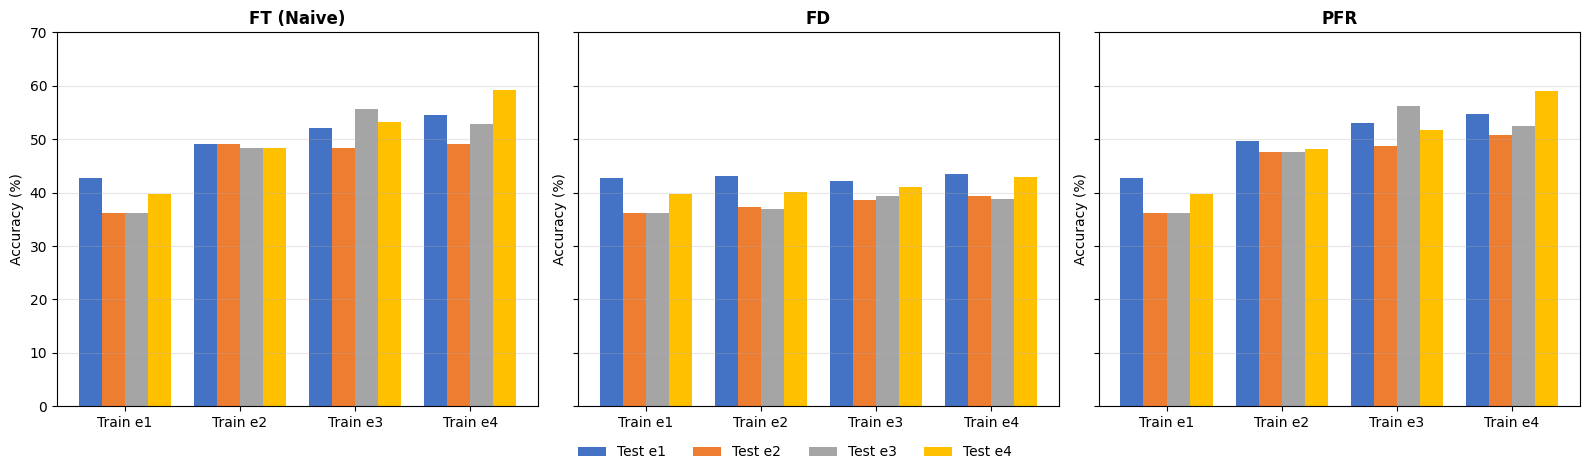

In [ ]:
import matplotlib.pyplot as plt

# palette dei grafici
COLORI_R = ['#4472C4', '#ED7D31', '#A5A5A5', '#FFC000']

def plot_R_barre(R, title, ax):
    N = R.shape[0]
    x = np.arange(N)                 # gruppi sull'asse x = "Train e1..eN"
    width = 0.8 / N
    for i in range(N):               # una serie di barre per ogni Test e_i
        vals = R[:, i]
        ax.bar(x + (i - (N-1)/2)*width, vals, width,
               label=f'Test e{i+1}', color=COLORI_R[i % len(COLORI_R)])
    ax.set_title(title, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels([f'Train e{t+1}' for t in range(N)])
    ax.set_ylim(0, 70)               # alza se servono valori piu' alti
    ax.set_ylabel('Accuracy (%)')
    ax.grid(axis='y', alpha=0.3)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharey=True)
for ax, (name, R) in zip(axes, [('FT (Naive)', R_ft), ('FD', R_fd), ('PFR', R_pfr)]):
    plot_R_barre(R, name, ax)
# una sola legenda condivisa in basso
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=NUM_TASKS,
           bbox_to_anchor=(0.5, -0.06), frameon=False)
plt.tight_layout()
plt.savefig('./R_barre.png', dpi=150, bbox_inches='tight')
plt.show()

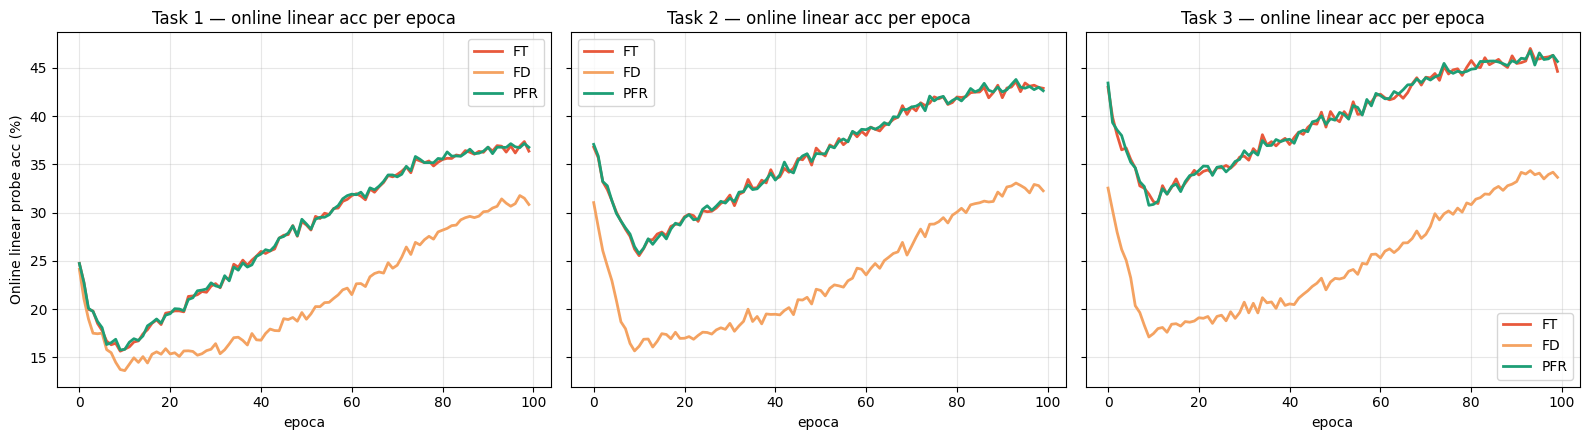

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

METHODS = {'ft': '#E8593C', 'fd': '#F4A261', 'pfr': '#1D9E75'}
ACC_KEY = 'train_online_eval_acc1_epoch'   # <-- nome corretto, col suffisso _epoch

def get_curve(run, key):
    h = run.history(keys=[key, 'epoch'])
    if key not in h.columns:          # protezione extra se la key manca
        return None, None
    h = h.dropna(subset=[key])
    if h.empty:
        return None, None
    y = h[key].values
    y = y * 100 if np.nanmax(y) <= 1.5 else y   # normalizza a %
    x = h['epoch'].values if 'epoch' in h.columns else np.arange(len(y))
    return x, y

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharey=True)
for task_idx, ax in zip([1, 2, 3], axes):
    for method, color in METHODS.items():
        for run in runs:
            if run.name == f'{method}-task{task_idx}':
                x, y = get_curve(run, ACC_KEY)
                if x is not None:
                    ax.plot(x, y, label=method.upper(), color=color, linewidth=2)
    ax.set_title(f'Task {task_idx} — online linear acc per epoca')
    ax.set_xlabel('epoca'); ax.grid(alpha=0.3); ax.legend()
axes[0].set_ylabel('Online linear probe acc (%)')
plt.tight_layout()
plt.savefig('./curve_apprendimento.png', dpi=150, bbox_inches='tight')
plt.show()

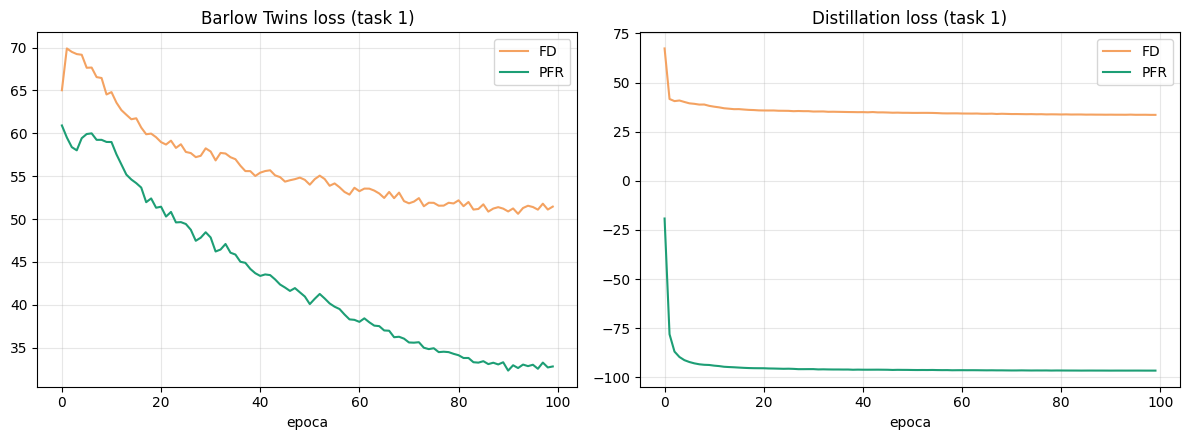

In [ ]:
DISTILL_KEY = 'train_decorrelative_distill_loss_epoch'   # col suffisso _epoch
BARLOW_KEY  = 'train_barlow_loss_epoch'                   # col suffisso _epoch

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
# Loss SSL (barlow) per FD vs PFR
for method, color in [('fd', '#F4A261'), ('pfr', '#1D9E75')]:
    for run in runs:
        if run.name == f'{method}-task1':
            x, y = get_curve(run, BARLOW_KEY)
            if x is not None: axes[0].plot(x, y, label=method.upper(), color=color)
            xd, yd = get_curve(run, DISTILL_KEY)
            if xd is not None: axes[1].plot(xd, yd, label=method.upper(), color=color)
axes[0].set_title('Barlow Twins loss (task 1)'); axes[0].set_xlabel('epoca'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].set_title('Distillation loss (task 1)'); axes[1].set_xlabel('epoca'); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.savefig('./curve_loss.png', dpi=150, bbox_inches='tight'); plt.show()

---

# Il verdetto: atteso vs ottenuto

Confrontiamo le aspettative dichiarate prima degli esperimenti con i numeri appena calcolati:

| Metodo | Atteso | Ottenuto | Spiegazione |
|---|---|---|---|
| **FT** | forgetting catastrofico, BWT molto negativo | **quasi nessun forgetting, BWT positivo** (+3 circa) | a 100 epoche il backbone è sotto-allenato: le feature sono ancora generiche e *qualunque* dato nuovo le migliora, anche per i task vecchi. Il forgetting da manuale (Lez. 22 p.6) richiede il regime lungo (500 epoche), dove il modello si specializza davvero su ogni task |
| **Joint** | upper bound | **confermato** (~59% nel protocollo a 100 classi) | l'unico che si comporta come previsto |
| **FD** | tra FT e PFR | **sotto FT di ~13 punti**: la R-matrix resta incollata alla riga del task 0 | λ=25 (tarato per 500 epoche) domina la loss 25:1 e **congela l'encoder sul teacher**: zero plasticità. È il pannello "Model with no Plasticity" della Lez. 22 p.16 — diagnosi e prova causale nella Sez. 12 |
| **PFR** | il migliore dei continual | **≈ FT** (+0.3 punti) | senza forgetting da prevenire, la protezione di PFR non ha nulla da correggere: non danneggia (a differenza di FD) ma nemmeno aiuta |

**Il ranking del paper (PFR > FD > FT) non si riproduce a 100 epoche** — e il motivo è coerente con
il corso: *"avoiding forgetting slows down the plasticity"* (Lez. 24 p.31/34) è la legge generale, e
nel regime a basso budget il piatto della bilancia pende tutto da una parte, perché il forgetting da
prevenire non si è ancora manifestato. La verifica sperimentale di questa spiegazione è l'indagine della Sez. 12: cinque passi, dalle
curve per epoca fino alla prova con λ ridotto.

---

# 12. L'indagine: perché FD va così male?

Il verdetto lascia una domanda aperta: FD doveva collocarsi tra FT e PFR e invece è finita 13 punti
sotto il naive — e il confronto tra i due esami (Sez. 10.3) ha già escluso che sia un artefatto della
valutazione. Restano da interrogare il training e il modello, un passo alla volta:

1. **Quando smette di imparare?** — le curve epoca per epoca, dai log wandb già esistenti
2. **I pesi si sono mossi?** — apriamo i checkpoint e misuriamo lo spostamento dal teacher congelato
3. **Come appaiono le feature?** — le nuvole delle classi proiettate in 2D
4. **Il codice è innocente?** — librerie, la loss messa alla prova con numeri piccoli e grandi, e il percorso dei gradienti (backpropagation)
5. **La prova** — rilanciamo FD cambiando solo λ (25 → 5): se si sblocca, il colpevole è lui

Ogni passo restringe il cerchio: la spiegazione finale deve reggere tutte le osservazioni insieme.

> 📖 Lezione 24, *doppia valutazione*: monitoraggio nel tempo (≈ prequential) + test per task. Queste curve sono la metà "nel tempo".

---

## Passo 1 — Quando smette di imparare? Le curve per epoca

I grafici della Sez. 11 ("online linear acc per epoca") usano `train_online_eval_acc1`, che misura
il classificatore online su **tutte e 100 le classi** insieme. Qui rifacciamo gli stessi grafici ma
**per experience**: durante il training, a fine epoca, cassle valuta il classificatore online sul
**validation set** e logga l'accuracy separata per ogni task (`val_acc1_task{i}`). Queste metriche
sono **già su wandb**: non serve rilanciare nessun training.

Due figure:

1. **Experience corrente (plasticità)** — mentre il modello impara il task $t$, quanto sale l'accuracy
   sulle classi del task $t$? Se FD è congelata, la sua curva resta piatta.
2. **Experience 0 (stabilità)** — mentre il modello impara i task 1, 2, 3, cosa succede all'accuracy
   sulle classi del task 0? Curva che scende = forgetting in diretta.

> Nota: è sempre il classificatore online (decisione a 100 vie, mai resettato), quindi i valori assoluti
> non sono confrontabili né con la Sez. 10 né con la il Passo 3 — conta la **forma** delle curve.
> Prerequisiti: solo login wandb (nessuna GPU necessaria).


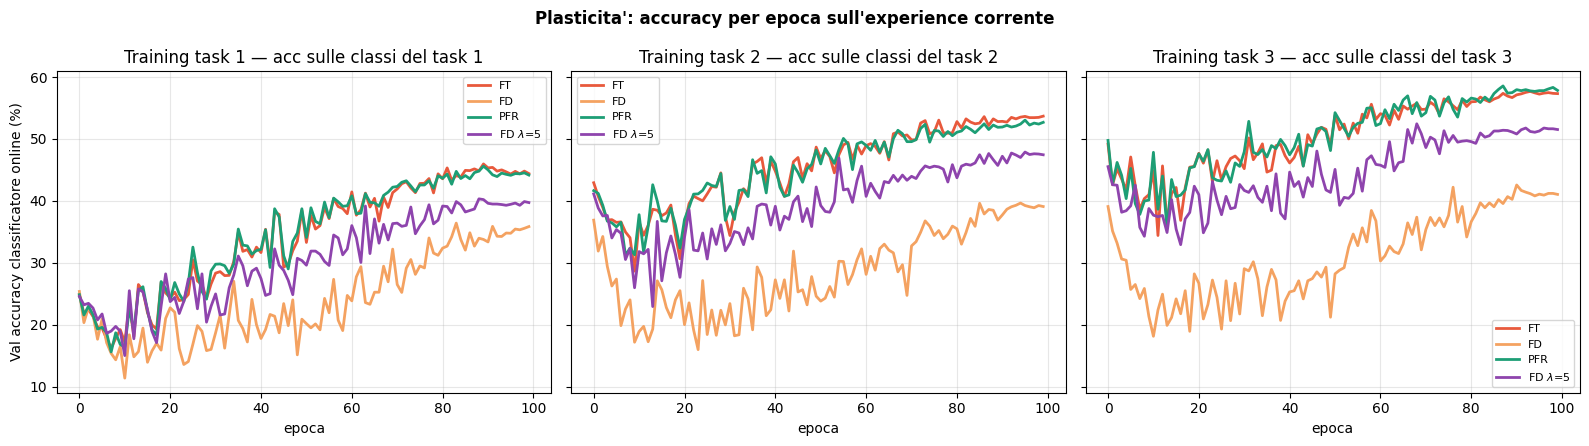

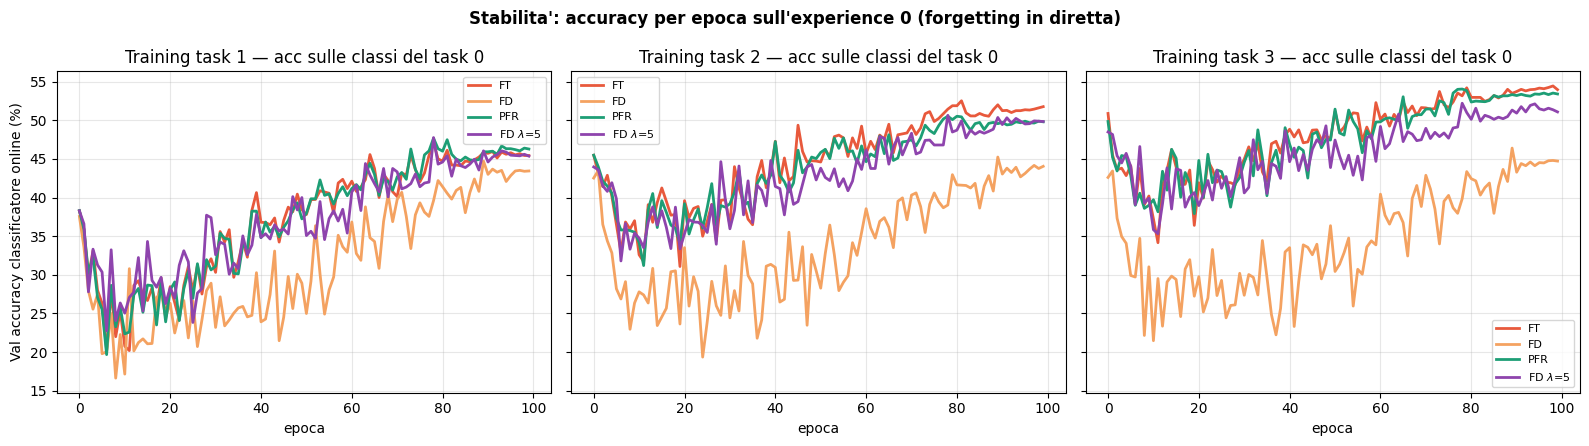

Lettura attesa:
 - Fig. 1: FT e PFR salgono (imparano il task corrente); FD lambda=25 resta piatta.
 - Fig. 2: curve che scendono = forgetting in diretta; FD piatta anche qui
   (non dimentica nulla perche' non impara nulla). Se hai fatto la il Passo 4,
   FD lambda=5 compare nel pannello del task 1.


In [ ]:
# Passo 1 — Curve per epoca sull'experience corrente e sull'experience 0, dalle run gia' su wandb
import os, wandb
import numpy as np
import matplotlib.pyplot as plt

api15 = wandb.Api()
runs15 = api15.runs(os.environ.get('MY_WANDB', 'pfr'))

METHODS15 = {'ft': '#E8593C', 'fd': '#F4A261', 'pfr': '#1D9E75', 'fd_lamb5': '#8E44AD'}

def curve15(run_name, key):
    # storia per-epoca di una metrica da wandb, normalizzata in %
    for run in runs15:
        if run.name == run_name:
            h = run.history(keys=[key, 'epoch'])
            if key not in h.columns:
                return None, None
            h = h.dropna(subset=[key])
            if h.empty:
                return None, None
            y = h[key].values
            y = y * 100 if np.nanmax(y) <= 1.5 else y
            x = h['epoch'].values if 'epoch' in h.columns else np.arange(len(y))
            return x, y
    return None, None

def plot_per_experience15(key_fn, title_fn, suptitle, fname):
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharey=True)
    for task_idx, ax in zip([1, 2, 3], axes):
        for method, color in METHODS15.items():
            x, y = curve15(f'{method}-task{task_idx}', key_fn(task_idx))
            if x is not None:
                label = {'fd_lamb5': 'FD $\\lambda$=5'}.get(method, method.upper())
                ax.plot(x, y, label=label, color=color, linewidth=2)
        ax.set_title(title_fn(task_idx))
        ax.set_xlabel('epoca')
        ax.grid(alpha=0.3)
        ax.legend(fontsize=8)
    axes[0].set_ylabel('Val accuracy classificatore online (%)')
    fig.suptitle(suptitle, fontweight='bold')
    plt.tight_layout()
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()

# Figura 1 — experience CORRENTE: mentre imparo il task t, accuracy sulle classi del task t
plot_per_experience15(
    key_fn=lambda t: f'val_acc1_task{t}',
    title_fn=lambda t: f'Training task {t} — acc sulle classi del task {t}',
    suptitle='Plasticita\': accuracy per epoca sull\'experience corrente',
    fname='./curve_experience_corrente.png',
)

# Figura 2 — experience 0: mentre imparo i task 1/2/3, accuracy sulle classi del task 0
plot_per_experience15(
    key_fn=lambda t: 'val_acc1_task0',
    title_fn=lambda t: f'Training task {t} — acc sulle classi del task 0',
    suptitle='Stabilita\': accuracy per epoca sull\'experience 0 (forgetting in diretta)',
    fname='./curve_experience_zero.png',
)

print('Lettura attesa:')
print(' - Fig. 1: FT e PFR salgono (imparano il task corrente); FD lambda=25 resta piatta.')
print(' - Fig. 2: curve che scendono = forgetting in diretta; FD piatta anche qui')
print('   (non dimentica nulla perche\' non impara nulla). Se hai fatto la il Passo 4,')
print('   FD lambda=5 compare nel pannello del task 1.')

## Passo 2 — I pesi si sono mossi? Dentro i checkpoint

La formalizzazione del CL (Lez. 22 p.9) prevede che un algoritmo continual porti con sé una
**memoria** $M_i$ oltre al modello. Per FD e PFR questa memoria è il *teacher congelato*: la copia
del modello di fine task precedente, usata come riferimento dalla distillazione. Sta fisicamente
dentro il file `.ckpt`: `distillers/base.py` fa `deepcopy(self.encoder)` all'inizio di ogni task, e
Lightning salva anche quella copia.

Tre verifiche:

1. dentro `fd-task1.ckpt` ci sono DUE reti (`encoder` e `frozen_encoder`);
2. `frozen_encoder` è identico bit per bit all'encoder del checkpoint del task 0 (= è davvero $M_i$);
3. quanto ogni metodo si è spostato dal teacher nello spazio dei pesi — la misura più diretta della plasticità.

> Nota, confermata dal relatore: le running statistics non vengono conservate dal congelamento e
> sarebbe più corretto non aggiornarle; l'effetto su training e analisi è però trascurabile e non
> richiede di rifare nulla.

In [ ]:
# Ispezione dei checkpoint: il teacher congelato, la scala e la rotazione dei pesi
import glob, torch
import numpy as np
from collections import Counter

BASE_CK = '/content/drive/MyDrive/CVPR_PFR/experiments'

def load_sd(pattern):
    cks = sorted(glob.glob(f'{BASE_CK}/{pattern}', recursive=True))
    assert cks, f'nessun checkpoint per {pattern}'
    try:
        return torch.load(cks[0], map_location='cpu', weights_only=False)['state_dict']
    except TypeError:
        return torch.load(cks[0], map_location='cpu')['state_dict']

def e_buffer_bn(k):
    # statistiche di BatchNorm: medie/varianze aggiornate a ogni forward, NON sono pesi appresi
    return ('running_mean' in k) or ('running_var' in k) or ('num_batches_tracked' in k)

# 1) cosa c'e' dentro fd-task1.ckpt?
sd_fd = load_sd('fd/**/*task1*.ckpt')
print('Componenti dentro fd-task1.ckpt:')
for prefix, n in sorted(Counter(k.split('.')[0] for k in sd_fd).items()):
    print(f'  {prefix:22s} {n:4d} tensori')
print()

# 2) il frozen_encoder e' la copia del modello di fine task 0?
#    Confronto SEPARANDO i pesi appresi dalle statistiche di BatchNorm: requires_grad=False
#    ferma l'apprendimento, ma le statistiche BN si aggiornano comunque a ogni forward.
sd_t0 = load_sd('task0/**/*.ckpt')
diff_pesi = diff_bn = 0.0
for k, v in sd_t0.items():
    if k.startswith('encoder.') and v.dtype.is_floating_point:
        w = sd_fd.get('frozen_encoder.' + k[len('encoder.'):])
        if w is None:
            continue
        d = (w - v).abs().max().item()
        if e_buffer_bn(k):
            diff_bn = max(diff_bn, d)
        else:
            diff_pesi = max(diff_pesi, d)
print('frozen_encoder(fd-task1) vs encoder(task0):')
print(f'  differenza massima sui PESI appresi:        {diff_pesi:.2e}')
print(f'  differenza massima sulle statistiche BN:    {diff_bn:.2e}')
print("=> i pesi del teacher sono congelati davvero (e' la memoria M della Lez. 22 p.9);")
print('   le statistiche di BatchNorm invece derivano sui dati nuovi: dettaglio implementativo')
print('   del repo da segnalare (il congelamento ferma i gradienti, non le statistiche).')
print()

# 3) quanto e COME si e' mosso l'encoder di ogni metodo rispetto al task 0?
#    Due numeri, solo sui pesi appresi:
#    - scala: ||w_nuovo|| / ||w_vecchio|| medio sui layer. Con la BatchNorm la scala e' "gratis":
#      moltiplicare i pesi di un layer per una costante non cambia la funzione calcolata.
#    - rotazione: 1 - coseno(w_nuovo, w_vecchio) medio sui layer. Zero = stessa direzione =
#      stessa funzione. E' questa la misura onesta del cambiamento.
def scala_e_rotazione(sd_new, sd_ref):
    scale, rot = [], []
    for k, v in sd_ref.items():
        if (k.startswith('encoder.') and v.dtype.is_floating_point
                and not e_buffer_bn(k) and v.numel() > 1):
            w = sd_new.get(k)
            if w is None:
                continue
            a, b = w.flatten().float(), v.flatten().float()
            scale.append((a.norm() / b.norm()).item())
            rot.append(1 - torch.nn.functional.cosine_similarity(a, b, dim=0).item())
    return float(np.mean(scale)), float(np.mean(rot))

print('encoder dopo il task 1, rispetto al task 0 (medie sui layer):')
print(f'  {"metodo":8s}{"scala":>8s}{"rotazione":>12s}')
for m in ['ft', 'fd', 'pfr']:
    sc, ro = scala_e_rotazione(load_sd(f'{m}/**/*task1*.ckpt'), sd_t0)
    print(f'  {m.upper():8s}{sc:8.2f}{ro:12.4f}')
if glob.glob(f'{BASE_CK}/fd_lamb5/**/*task1*.ckpt', recursive=True):
    sc, ro = scala_e_rotazione(load_sd('fd_lamb5/**/*task1*.ckpt'), sd_t0)
    print(f'  {"FD l=5":8s}{sc:8.2f}{ro:12.4f}')
print()
print("Lettura: la scala cresce con lambda (FT 1.41 -> FD l=5 1.48 -> FD l=25 2.34): e' l'impronta")
print("dei gradienti sovradimensionati della distillazione, che la BatchNorm neutralizza. La")
print("rotazione separa i metodi distillati (~0.10) da quelli liberi (~0.15), ma da sola non basta")
print("a spiegare la funzione: il giudice finale restano le misure funzionali (probe, kNN, curve).")

Componenti dentro fd-task1.ckpt:
  classifier                2 tensori
  distill_predictor         9 tensori
  encoder                 120 tensori
  frozen_encoder          120 tensori
  frozen_projector         16 tensori
  projector                16 tensori

frozen_encoder(fd-task1) vs encoder(task0):
  differenza massima sui PESI appresi:        0.00e+00
  differenza massima sulle statistiche BN:    5.25e+03
=> i pesi del teacher sono congelati davvero (e' la memoria M della Lez. 22 p.9);
   le statistiche di BatchNorm invece derivano sui dati nuovi: dettaglio implementativo
   del repo da segnalare (il congelamento ferma i gradienti, non le statistiche).

encoder dopo il task 1, rispetto al task 0 (medie sui layer):
  metodo     scala   rotazione
  FT          1.41      0.1539
  FD          2.34      0.1011
  PFR         1.41      0.1537
  FD l=5      1.48      0.1012

Lettura: la scala cresce con lambda (FT 1.41 -> FD l=5 1.48 -> FD l=25 2.34): e' l'impronta
dei gradienti sovradi

---

## Passo 3 — Come appaiono le feature? Le nuvole in 2D

> **Prerequisito**: celle di setup e probe della Sez. 10.2 eseguite in questa sessione (riusa `extract14`, `TASKS14`, `CKPTS14`, `test_ds14`).

La linear evaluation dà un numero, ma cosa *vede* il probe? Ogni immagine è un punto in 512
dimensioni; il probe traccia confini piatti tra le nuvole delle classi. Non possiamo disegnare 512
dimensioni, ma possiamo proiettarle in 2D con la PCA e guardare:

1. **come ogni metodo dispone le stesse 5 classi del task 1** — il teacher (che il task 1 non l'ha mai
   visto) dovrebbe avere nuvole mescolate; FT e PFR nuvole separate; FD... vediamo;
2. **un probe giocattolo a 2 classi**, con la sua retta di decisione disegnata — la versione visibile
   di quello che i probe delle Sez. 9-14 fanno in 512 dimensioni.

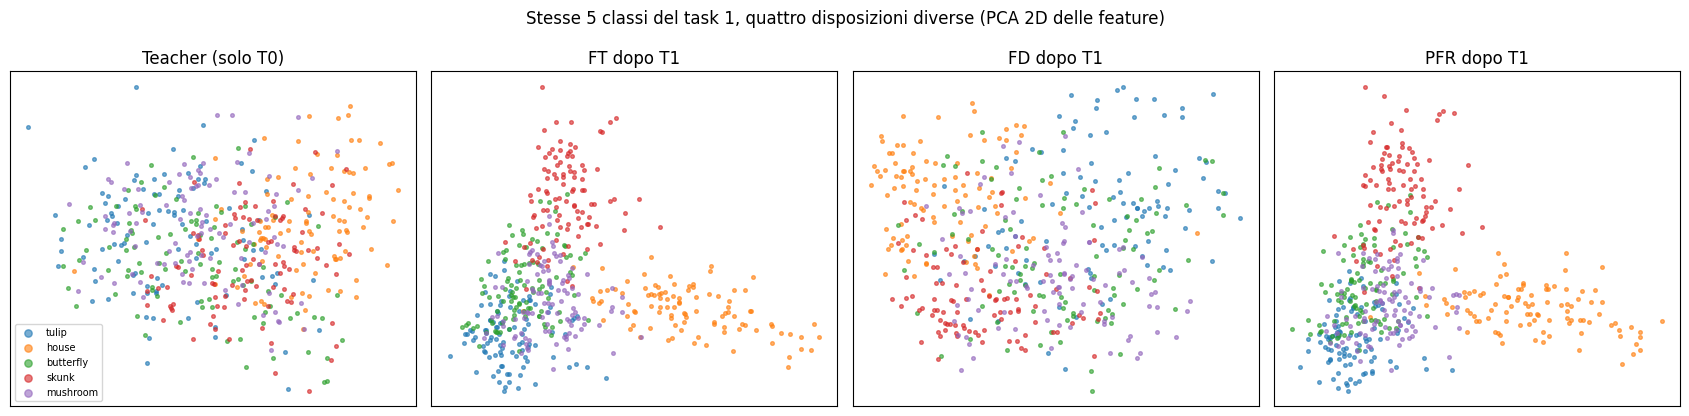

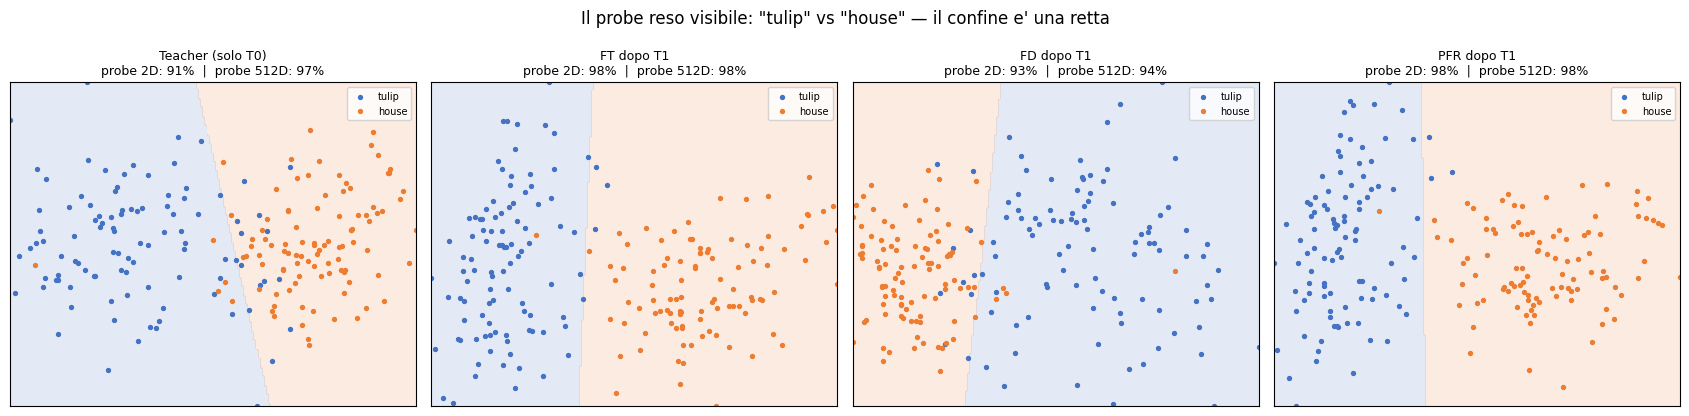

Osservazioni:
 - il probe non sposta i punti: la disposizione la decide il checkpoint, il probe traccia solo il confine;
 - il probe a 512D va sempre meglio di quello a 2D: la PCA butta via informazione, serve solo per VEDERE;
 - confronta i pannelli: dove le nuvole sono separate il probe vince, dove sono mescolate nessuna retta lo salva.


In [ ]:
# Le nuvole di 5 classi del task 1, come le dispone ogni metodo (PCA a 2D)
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
import numpy as np
import matplotlib.pyplot as plt

CLS5 = TASKS14[1][:5].tolist()                       # 5 classi del task 1
NAMES5 = [test_ds14.classes[c] for c in CLS5]
PANNELLI = [('Teacher (solo T0)', CKPTS14['task0'][0]),
            ('FT dopo T1',        CKPTS14['ft'][1]),
            ('FD dopo T1',        CKPTS14['fd'][1]),
            ('PFR dopo T1',       CKPTS14['pfr'][1])]

fig, axes = plt.subplots(1, 4, figsize=(17, 4.2))
for ax, (titolo, ck) in zip(axes, PANNELLI):
    ftr, ytr, fte, yte = extract14(ck)               # dalla cache della Passo 3: gratis
    m = np.isin(yte.numpy(), CLS5)
    X2 = PCA(n_components=2).fit_transform(fte[m].numpy())
    for c, nome in zip(CLS5, NAMES5):
        sel = yte[m].numpy() == c
        ax.scatter(X2[sel, 0], X2[sel, 1], s=7, alpha=0.6, label=nome)
    ax.set_title(titolo); ax.set_xticks([]); ax.set_yticks([])
axes[0].legend(fontsize=7, markerscale=2, loc='best')
fig.suptitle('Stesse 5 classi del task 1, quattro disposizioni diverse (PCA 2D delle feature)')
plt.tight_layout()
plt.savefig('./nuvole_task1_2d.png', dpi=150, bbox_inches='tight')
plt.show()

# Un probe giocattolo: 2 classi, spazio ridotto a 2D, la retta di decisione e' visibile
c1, c2 = CLS5[0], CLS5[1]
fig, axes = plt.subplots(1, 4, figsize=(17, 4.2))
for ax, (titolo, ck) in zip(axes, PANNELLI):
    ftr, ytr, fte, yte = extract14(ck)
    mtr = np.isin(ytr.numpy(), [c1, c2]); mte = np.isin(yte.numpy(), [c1, c2])
    pca = PCA(n_components=2).fit(ftr[mtr].numpy())
    Xtr2, Xte2 = pca.transform(ftr[mtr].numpy()), pca.transform(fte[mte].numpy())
    probe2d = LogisticRegression().fit(Xtr2, (ytr[mtr].numpy() == c2))
    # accuracy del probe: in 2D (quello disegnato) e in 512D (quello vero)
    acc2d = probe2d.score(Xte2, (yte[mte].numpy() == c2)) * 100
    acc512 = LogisticRegression(max_iter=2000).fit(
        ftr[mtr].numpy(), (ytr[mtr].numpy() == c2)).score(
        fte[mte].numpy(), (yte[mte].numpy() == c2)) * 100
    # sfondo colorato = regioni di decisione del probe 2D
    xx, yy = np.meshgrid(np.linspace(Xte2[:, 0].min(), Xte2[:, 0].max(), 200),
                         np.linspace(Xte2[:, 1].min(), Xte2[:, 1].max(), 200))
    Z = probe2d.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.15, levels=1, colors=['#4472C4', '#ED7D31'])
    for c, col in [(c1, '#4472C4'), (c2, '#ED7D31')]:
        sel = yte[mte].numpy() == c
        ax.scatter(Xte2[sel, 0], Xte2[sel, 1], s=8, color=col, label=test_ds14.classes[c])
    ax.set_title(f'{titolo}\nprobe 2D: {acc2d:.0f}%  |  probe 512D: {acc512:.0f}%', fontsize=9)
    ax.set_xticks([]); ax.set_yticks([]); ax.legend(fontsize=7)
fig.suptitle(f'Il probe reso visibile: "{test_ds14.classes[c1]}" vs "{test_ds14.classes[c2]}" — il confine e\' una retta')
plt.tight_layout()
plt.savefig('./probe_2classi_2d.png', dpi=150, bbox_inches='tight')
plt.show()

print('Osservazioni:')
print(' - il probe non sposta i punti: la disposizione la decide il checkpoint, il probe traccia solo il confine;')
print(' - il probe a 512D va sempre meglio di quello a 2D: la PCA butta via informazione, serve solo per VEDERE;')
print(' - confronta i pannelli: dove le nuvole sono separate il probe vince, dove sono mescolate nessuna retta lo salva.')

## Passo 4 — Il codice è innocente? Librerie, numeri e backpropagation

Prima di condannare l'iperparametro, verifichiamo che il colpevole non sia il codice. Il repo ha
3-4 anni e gira su librerie più nuove con alcune patch: un bug silenzioso potrebbe produrre lo stesso
sintomo. Tre verifiche, tutte leggere (secondi, nessun training):

1. **Librerie e patch** — le versioni in uso e un controllo indipendente: riscrivo la formula di
   Barlow Twins dalla definizione e la confronto numericamente con la funzione del repo.
2. **Numeri piccoli e grandi** — la loss di distillazione si comporta come dichiarato? Deve valere
   ~0 se lo studente coincide col teacher, crescere con la distanza, e scendere se la si ottimizza.
3. **Backpropagation** — la backpropagation è l'algoritmo che, partendo dalla loss, calcola per ogni
   peso della rete quanto e in che direzione va corretto (il *gradiente*). Qui i bug si nascondono
   bene: un `detach()` di troppo blocca i gradienti e un pezzo di rete smette di imparare in silenzio —
   proprio il sintomo di FD. Controlliamo che i gradienti arrivino dove devono, che il teacher sia
   davvero congelato, e **con che forza** il vincolo tira rispetto alla loss del task.

### Verifica 1 — Librerie e patch: cosa controlla e perché

Il dubbio da cui nasce: il repo è del 2022, scritto per PyTorch ~1.10 e Lightning 1.5.4. Noi giriamo
su versioni molto più nuove, tenute insieme da tre patch (Sez. 1.3). E se una libreria, da una
versione all'altra, calcolasse qualcosa in modo leggermente diverso? Un errore del genere non darebbe
crash: darebbe **numeri sbagliati in silenzio**, che è la cosa peggiore.

Il controllo procede in due mosse:

1. **Documentare l'ambiente**: stampare le versioni effettivamente in uso, accanto a quelle per cui
   il repo era stato scritto. Serve anche per il report: chiunque voglia riprodurre sa cosa girava.
2. **La prova indipendente**: le patch, a leggerle, toccano solo import e controlli di tipo — ma
   invece di fidarci, riscriviamo la loss di Barlow Twins **da zero, partendo dalla formula
   matematica** della Sez. 2 (standardizza le colonne, calcola la matrice di cross-correlazione,
   somma il termine di invarianza e quello di ridondanza). Poi diamo **gli stessi identici input**
   alla nostra versione e a quella del repo e confrontiamo i due numeri. Se coincidono, l'intera
   catena — librerie, patch, versioni — produce esattamente il valore che la matematica prescrive.

Come leggere l'output: la "differenza" tra le due loss deve essere un numero piccolissimo
(ordine $10^{-4}$ o meno: solo rumore di arrotondamento in virgola mobile). Se fosse grande,
avremmo trovato il colpevole — un'incompatibilità di libreria che altera i calcoli. Non è il caso:
le librerie sono assolte.

In [ ]:
# Verifica 1 — Librerie e patch: i numeri sono affidabili?
import torch
import pytorch_lightning
import torchmetrics
import numpy

print(f'torch             {torch.__version__}   (il repo e\' del 2022, scritto per ~1.10)')
print(f'pytorch-lightning {pytorch_lightning.__version__}   (richiesta dal repo: 1.5.4)')
print(f'torchmetrics      {torchmetrics.__version__}')
print(f'numpy             {numpy.__version__}\n')

# Le tre patch della Sez. 1.3 toccano solo import e controlli di tipo, mai i calcoli:
#  1) torch._six   -> ricrea un alias di import rimosso nelle versioni nuove
#  2) knn.py       -> argomento deprecato di torchmetrics (e la kNN eval e' comunque disattivata)
#  3) scheduler    -> controllo isinstance di lightning, non i valori del learning rate
# Ma non fidiamoci delle parole: riscrivo la loss di Barlow Twins dalla formula
# della Sez. 2 e la confronto con la funzione del repo sugli stessi input.
from cassle.losses.barlow import barlow_loss_func

def barlow_a_mano(z1, z2, lamb=5e-3, scale=0.025):
    # standardizzo per colonna (come la BatchNorm non-affine del repo)
    z1 = (z1 - z1.mean(0)) / torch.sqrt(z1.var(0, unbiased=False) + 1e-5)
    z2 = (z2 - z2.mean(0)) / torch.sqrt(z2.var(0, unbiased=False) + 1e-5)
    C = z1.T @ z2 / z1.shape[0]                          # matrice di cross-correlazione
    inv = ((C.diagonal() - 1) ** 2).sum()                # diagonale -> 1 (invariance)
    fuori = ~torch.eye(C.shape[0], dtype=torch.bool)
    red = (C[fuori] ** 2).sum()                          # fuori diagonale -> 0 (redundancy)
    return scale * (inv + lamb * red)

torch.manual_seed(0)
z1, z2 = torch.randn(256, 128), torch.randn(256, 128)
repo = barlow_loss_func(z1, z2).item()
mano = barlow_a_mano(z1, z2).item()
print(f'loss del repo: {repo:.6f}   formula riscritta a mano: {mano:.6f}   differenza: {abs(repo-mano):.2e}')
print('=> la funzione del repo calcola esattamente la formula del paper: le librerie non alterano i numeri')

torch             2.11.0+cu128   (il repo e' del 2022, scritto per ~1.10)
pytorch-lightning 1.5.4   (richiesta dal repo: 1.5.4)
torchmetrics      1.9.0
numpy             2.0.2



Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/content/drive/MyDrive/CVPR_PFR/cassle/utils/whitening.py:21: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @custom_fwd(cast_inputs=torch.float32)


loss del repo: 3.252460   formula riscritta a mano: 3.252460   differenza: 0.00e+00
=> la funzione del repo calcola esattamente la formula del paper: le librerie non alterano i numeri


### Verifica 2 — Numeri piccoli e grandi: cosa controlla e perché

Questa è la classica prova "al banco": invece di dati veri, diamo alla loss **input costruiti a
tavolino di cui conosciamo già la risposta giusta**, e controlliamo che risponda come deve. È il
suggerimento "esegui con numeri piccoli o grossi": se il codice si comporta bene agli estremi,
è affidabile anche in mezzo.

Tre esperimenti in sequenza:

1. **La loss cresce con la distanza?** Costruiamo quattro "studenti": uno identico al teacher, uno
   che se n'è allontanato poco, uno molto, uno completamente scorrelato. La distill loss deve valere
   quasi zero nel primo caso e crescere man mano — se non fosse monotona, il vincolo non starebbe
   misurando la fedeltà al teacher.
2. **Quanto pesa davvero λ?** Prendiamo un valore "tipico" della loss del task e uno della distill
   loss, e tabuliamo il contributo del vincolo per λ = 0, 1, 5, 25, 100. Qui si vede in cifre il
   tiro alla fune: con λ=25 il vincolo vale decine di volte la loss del task. Non è un'anomalia
   del codice — è l'architettura della loss, ed è il cuore della nostra ipotesi.
3. **La loss si può minimizzare?** Un piccolo predictor viene ottimizzato per 120 passi contro
   questa loss: se il valore scende in modo netto, il codice non solo calcola il numero giusto, ma
   è anche ottimizzabile — gradiente utilizzabile, niente punti morti. È in miniatura quello che
   il training di FD fa per 100 epoche.

Come leggere l'output: la prima tabella deve essere crescente dall'alto verso il basso; la seconda
deve mostrare il contributo del vincolo che esplode con λ; la mini-ottimizzazione deve scendere di
molto rispetto al valore iniziale.

In [ ]:
# Verifica 2 — Numeri piccoli e grandi: la distill loss si comporta come dichiarato?
import torch
from cassle.losses.barlow import barlow_loss_func

torch.manual_seed(0)
B, D = 256, 512
z_teacher = torch.randn(B, D)

casi = {
    'studente identico al teacher':    z_teacher.clone(),
    'studente vicino (poca deriva)':   z_teacher + 0.3 * torch.randn(B, D),
    'studente lontano (molta deriva)': z_teacher + 1.0 * torch.randn(B, D),
    'studente scorrelato (random)':    torch.randn(B, D),
}
print('distill loss al crescere della distanza studente-teacher:')
valori = {}
for nome, z in casi.items():
    valori[nome] = barlow_loss_func(z, z_teacher, lamb=5e-3, scale_loss=0.1).item()
    print(f'  {nome:34s} {valori[nome]:9.2f}')
print('=> cresce con la distanza: il vincolo penalizza chi si allontana, come deve.\n')

# il peso lambda: quanto pesa il vincolo rispetto alla loss del task?
# simulo una loss del task "tipica" (due viste rumorose della stessa base)
base = torch.randn(B, D)
task_tipica = barlow_loss_func(base + 0.5 * torch.randn(B, D),
                               base + 0.5 * torch.randn(B, D), lamb=5e-3, scale_loss=0.1).item()
dist_tipica = valori['studente vicino (poca deriva)']
print(f'loss del task (tipica): {task_tipica:.2f}    distill loss (tipica): {dist_tipica:.2f}')
print('contributo del vincolo alla loss totale al variare di lambda:')
for lam in (0, 1, 5, 25, 100):
    print(f'  lambda = {lam:3d}:  {lam * dist_tipica:9.2f}   ({lam * dist_tipica / task_tipica:6.1f} volte la loss del task)')
print()

# infine: ottimizzando questa loss, scende davvero? (mini-test con un predictor lineare)
pred = torch.nn.Linear(D, D)
opt = torch.optim.Adam(pred.parameters(), lr=1e-2)
z_new = casi['studente lontano (molta deriva)']
print('mini-ottimizzazione: il predictor impara a riavvicinare studente e teacher')
for step in range(121):
    loss = barlow_loss_func(pred(z_new), z_teacher, lamb=5e-3, scale_loss=0.1)
    opt.zero_grad(); loss.backward(); opt.step()
    if step % 30 == 0:
        print(f'  step {step:3d}: distill loss = {loss.item():8.2f}')
print('=> la loss scende nettamente: il codice ottimizza davvero quello che dichiara')

distill loss al crescere della distanza studente-teacher:
  studente identico al teacher            0.51
  studente vicino (poca deriva)           0.61
  studente lontano (molta deriva)         4.92
  studente scorrelato (random)           51.96
=> cresce con la distanza: il vincolo penalizza chi si allontana, come deve.

loss del task (tipica): 2.59    distill loss (tipica): 0.61
contributo del vincolo alla loss totale al variare di lambda:
  lambda =   0:       0.00   (   0.0 volte la loss del task)
  lambda =   1:       0.61   (   0.2 volte la loss del task)
  lambda =   5:       3.03   (   1.2 volte la loss del task)
  lambda =  25:      15.17   (   5.9 volte la loss del task)
  lambda = 100:      60.66   (  23.4 volte la loss del task)

mini-ottimizzazione: il predictor impara a riavvicinare studente e teacher
  step   0: distill loss =    52.34
  step  30: distill loss =     0.80
  step  60: distill loss =     0.59
  step  90: distill loss =     0.52
  step 120: distill loss =   

### Verifica 3 — Backpropagation: cosa controlla e perché

Ripasso in due righe: durante il training, dopo aver calcolato la loss, PyTorch percorre la rete
**all'indietro** e calcola per ogni peso il *gradiente* — quanto quel peso ha contribuito all'errore
e in che direzione andrebbe corretto. Questo calcolo a ritroso è la **backpropagation**; l'optimizer
poi applica le correzioni. Se da qualche parte il flusso dei gradienti è interrotto (tipicamente da
un `detach()` messo male), un pezzo di rete **smette di imparare senza dare alcun errore** — e il
sintomo sarebbe identico a quello di FD. Per questo il controllo è d'obbligo.

Ricostruiamo in piccolo la situazione di FD — l'encoder vero, la copia congelata fatta con
`deepcopy` esattamente come in `distillers/base.py`, un predictor — e facciamo quattro domande:

1. **Il teacher è congelato?** Nessuno dei suoi parametri deve richiedere gradiente. Se anche uno
   lo richiedesse, il "passato" si muoverebbe durante il training e la distillazione perderebbe senso.
2. **La loss del task raggiunge l'encoder?** Calcoliamo la norma del gradiente che la loss di Barlow
   Twins produce sui pesi dell'encoder: deve essere > 0. È il nostro metro di riferimento.
3. **La distillazione raggiunge l'encoder, e con che forza?** Questo è il punto critico. Se il
   gradiente della distill loss sull'encoder fosse zero, avremmo trovato un bug (un detach che blocca
   il vincolo) — ma attenzione: quel bug renderebbe FD identico a FT, non peggiore. Il gradiente
   invece c'è, e **scala linearmente con λ**: con λ=25 supera di molto quello del task. Tradotto:
   a ogni passo di training, la direzione in cui si muovono i pesi la decide il vincolo, non
   l'apprendimento del task nuovo.
4. **Il teacher ha ricevuto gradienti per sbaglio?** Dopo tutti i backward, contiamo i gradienti
   arrivati sui suoi parametri: devono essere zero.

Come leggere l'output: 0 parametri allenabili nel teacher, gradienti > 0 sia per il task sia per la
distillazione, rapporto distillazione/task che cresce ~linearmente con λ, 0 gradienti sul teacher.
Tutto regolare = il codice è innocente, e abbiamo **quantificato** il meccanismo che accusa λ:
il tiro alla fune dei gradienti è impari 25 a 1.

In [ ]:
# Verifica 3 — Backpropagation: i gradienti arrivano dove devono, con la forza attesa?
import torch
import torch.nn as nn
from copy import deepcopy
from torchvision.models import resnet18
from cassle.losses.barlow import barlow_loss_func

dev = 'cuda' if torch.cuda.is_available() else 'cpu'
torch.manual_seed(0)

# stesso encoder degli esperimenti + copia congelata, come fa distillers/base.py
enc = resnet18()
enc.fc = nn.Identity()
enc.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=2, bias=False)
enc.maxpool = nn.Identity()
enc = enc.to(dev)
teacher = deepcopy(enc)
for p in teacher.parameters():
    p.requires_grad = False

predictor = nn.Sequential(nn.Linear(512, 2048), nn.BatchNorm1d(2048),
                          nn.ReLU(), nn.Linear(2048, 512)).to(dev)
X  = torch.randn(64, 3, 32, 32, device=dev)
X2 = X + 0.1 * torch.randn_like(X)      # "seconda vista" simulata

def norma_gradiente_encoder(loss):
    # backpropagation: dalla loss, torch calcola il gradiente di ogni peso dell'encoder
    for p in enc.parameters():
        p.grad = None
    loss.backward()
    return torch.sqrt(sum((p.grad ** 2).sum() for p in enc.parameters()
                          if p.grad is not None)).item()

# 1) il teacher e' davvero congelato?
n_tr = sum(p.requires_grad for p in teacher.parameters())
print(f'parametri del teacher che richiedono gradiente: {n_tr} su {len(list(teacher.parameters()))}')

# 2) la loss del task muove l'encoder (riferimento)
g_task = norma_gradiente_encoder(barlow_loss_func(enc(X), enc(X2), lamb=5e-3, scale_loss=0.1))
print(f'norma del gradiente sull\'encoder — loss del task:              {g_task:9.3f}\n')

# 3) anche la distillazione arriva all'encoder (nessun detach che la blocca),
#    e la sua forza scala linearmente con lambda
for lam in (1, 5, 25):
    dl = barlow_loss_func(predictor(enc(X)), teacher(X).detach(), lamb=5e-3, scale_loss=0.1)
    g = norma_gradiente_encoder(lam * dl)
    print(f'norma del gradiente — distillazione con lambda = {lam:3d}:        {g:9.3f}   ({g / g_task:5.1f} volte il task)')

# 4) dopo tutti questi backward, il teacher ha ricevuto gradienti?
n_grad = sum(p.grad is not None for p in teacher.parameters())
print(f'\ngradienti finiti sul teacher: {n_grad} (deve essere 0: il passato non si tocca)')
print()
print('Conclusioni: nessun blocco nel flusso dei gradienti e teacher davvero congelato;')
print('ma con lambda=25 la direzione di aggiornamento dell\'encoder e\' dettata dal vincolo,')
print('non dal task. Il codice e\' innocente: resta un solo indiziato, il peso lambda.')

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/content/drive/MyDrive/CVPR_PFR/cassle/utils/whitening.py:21: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @custom_fwd(cast_inputs=torch.float32)


parametri del teacher che richiedono gradiente: 0 su 60
norma del gradiente sull'encoder — loss del task:                 17.636

norma del gradiente — distillazione con lambda =   1:          178.274   ( 10.1 volte il task)
norma del gradiente — distillazione con lambda =   5:          891.369   ( 50.5 volte il task)
norma del gradiente — distillazione con lambda =  25:         4456.849   (252.7 volte il task)

gradienti finiti sul teacher: 0 (deve essere 0: il passato non si tocca)

Conclusioni: nessun blocco nel flusso dei gradienti e teacher davvero congelato;
ma con lambda=25 la direzione di aggiornamento dell'encoder e' dettata dal vincolo,
non dal task. Il codice e' innocente: resta un solo indiziato, il peso lambda.


### Verifica 3b — Cosa attenua il rapporto 253:1? Il LARS

Il rapporto misurato nella Verifica 3 — riferito a **FD** (distiller `decorrelative`, λ=25) — è enorme, ed è lecito chiedersi se durante il training reale
qualcosa lo attenui — ad esempio learning rate diversi per moduli diversi. La risposta c'è, e sta in
un flag dei comandi di training: `--lars`.

**LARS** (Layer-wise Adaptive Rate Scaling) riscala il passo di aggiornamento **layer per layer**: la
grandezza del passo per un layer è proporzionale a ||pesi||/||gradiente||, quindi **la norma del passo
non dipende dalla grandezza del gradiente**. Un gradiente 253 volte più grande NON produce un passo
253 volte più grande.

Quello che LARS *non* può cambiare è la **direzione**: il gradiente totale è la somma dei due
contributi, e se uno è 253 volte l'altro, la somma punta praticamente dove punta il più grande.
Quindi: passi di dimensione normale (grazie a LARS), ma quasi tutti nella direzione "resta come il
teacher". La verifica qui sotto misura entrambe le cose — e chiude il cerchio con il Passo 2: passi
di norma regolare che spingono sempre nella stessa direzione radiale spiegano la scala dei pesi
cresciuta (2.34) con poca rotazione (0.10).

In [ ]:
# Verifica 3b — LARS: la norma del passo e' normalizzata, la direzione no
import torch
import torch.nn as nn

assert 'enc' in globals() and 'teacher' in globals() and 'predictor' in globals(), \
    'esegui prima la Verifica 3 (definisce encoder, teacher e predictor)'

def gradiente_piatto(loss):
    for p in enc.parameters():
        p.grad = None
    loss.backward()
    return torch.cat([p.grad.flatten() for p in enc.parameters() if p.grad is not None])

# i tre gradienti: task, vincolo (lambda=25) e totale (la loro somma)
g_task = gradiente_piatto(barlow_loss_func(enc(X), enc(X2), lamb=5e-3, scale_loss=0.1)).clone()
g_dist = gradiente_piatto(25 * barlow_loss_func(predictor(enc(X)), teacher(X).detach(),
                                                lamb=5e-3, scale_loss=0.1)).clone()
g_tot = g_task + g_dist

cos = torch.nn.functional.cosine_similarity
print('DIREZIONE del gradiente totale (task + 25*distillazione):')
print(f'  coseno con la direzione della distillazione: {cos(g_tot, g_dist, dim=0).item():.4f}')
print(f'  coseno con la direzione del task:            {cos(g_tot, g_task, dim=0).item():.4f}')
print()

# GRANDEZZA del passo con LARS: passo ~ lr * eta * ||w|| * g/||g||  (norma indipendente da ||g||)
lr, eta = 0.3, 0.02
print('GRANDEZZA del passo su tre layer di esempio (norma del passo LARS):')
esempi = [(k, p) for k, p in enc.named_parameters() if p.dim() == 4][:3]
for k, p in esempi:
    passo = lr * eta * p.norm().item()   # indipendente dalla norma del gradiente
    print(f'  {k:38s} ||passo|| = {passo:.4f}  (uguale per task, vincolo o totale)')
print()
print('Conclusione: LARS attenua la GRANDEZZA (nessun passo 253 volte piu\' grande),')
print('ma non la DIREZIONE: quasi ogni passo punta verso "resta come il teacher".')
print('Coerente con il Passo 2: pesi cresciuti in scala (2.34) e poco ruotati (0.10).')

DIREZIONE del gradiente totale (task + 25*distillazione):
  coseno con la direzione della distillazione: 1.0000
  coseno con la direzione del task:            -0.0013

GRANDEZZA del passo su tre layer di esempio (norma del passo LARS):
  conv1.weight                           ||passo|| = 0.0281  (uguale per task, vincolo o totale)
  layer1.0.conv1.weight                  ||passo|| = 0.0675  (uguale per task, vincolo o totale)
  layer1.0.conv2.weight                  ||passo|| = 0.0681  (uguale per task, vincolo o totale)

Conclusione: LARS attenua la GRANDEZZA (nessun passo 253 volte piu' grande),
ma non la DIREZIONE: quasi ogni passo punta verso "resta come il teacher".
Coerente con il Passo 2: pesi cresciuti in scala (2.34) e poco ruotati (0.10).


> 📖 Lezione 23, *hyperparameter tuning in CL* (problema aperto): questo esperimento ne è un caso concreto.

---

## Passo 5 — La prova: FD con $\lambda$ ridotto

## Il problema osservato

Nella Sez. 10 FD (`decorrelative`, $\lambda=25$) ottiene Avg Acc ≈ 41%, **sotto** FT (~54%) e PFR (~54%), mentre il paper prevede FT < FD < PFR. La R-matrix mostra che FD resta incollata al teacher:

| | task0 | task1 | task2 | task3 |
|---|---|---|---|---|
| Teacher (solo task 0) | 42.72 | 36.24 | 36.08 | 39.72 |
| FD $\lambda=25$ dopo T1 | 43.04 | 37.20 | 36.88 | 40.16 |

Dopo 100 epoche di training sul task 1, FD guadagna **+1 punto** sul task 1: l'encoder non si è praticamente mosso dal checkpoint del task 0.

## Ipotesi

`--distill_lamb 25` è tarato dagli autori per **500 epoche/task**. La loss totale di FD è
$0.1\,\mathcal{L}_{BT} + 25\cdot(0.1\,\mathcal{L}_{distill})$: la distillazione pesa 25× la loss SSL
e ha un minimo banale ("non muovere l'encoder", il predictor impara l'identità). Con `warmup_cosine`
su 100 epoche il learning rate si spegne 5× prima: l'encoder non ha il tempo di derivare lentamente
dentro il vincolo e resta congelato sul teacher — che a 100 epoche è anche debole, da cui il tetto a ~41%.

## Test

Rilanciamo **solo il task 1** di FD con `--distill_lamb 5`. Nome run (`fd_lamb5`), nome linear eval
(`linear_fd_lamb5_T1`) e cartella checkpoint (`experiments/fd_lamb5`) sono nuovi: **nessun risultato
esistente viene toccato**, e i regex della Sez. 10 (`linear_fd_T(\d+)$`) non matchano i nuovi nomi.

Se la riga after-T1 si sblocca (task1 ~47-48 come FT/PFR, task0 ≥ FT), l'ipotesi è confermata.

> **Prerequisiti**: Sezione 1 completa (mount Drive, chdir nel repo, dipendenze, patch), login wandb,
> la cella di configurazione della Sez. 9 (quella che esporta `MY_DATA_DIR`, `MY_WANDB`, ...) e la cella
> che definisce `linear_eval()`.


In [ ]:
# 5.1 — Setup esperimento FD lambda=5 (tutto separato dai risultati esistenti)
import os, glob

EXP_FD5 = '/content/drive/MyDrive/CVPR_PFR/experiments/fd_lamb5'
os.makedirs(EXP_FD5, exist_ok=True)
os.environ['MY_EXP_FD5'] = EXP_FD5

# ri-esporto le variabili base nel caso il runtime sia stato riavviato
os.environ.setdefault('MY_DATA_DIR', '/content/drive/MyDrive/cifar_data')
os.environ.setdefault('MY_WANDB', 'pfr')

# checkpoint del task 0 (condiviso con FT/FD/PFR, gia' esistente su Drive)
t0 = glob.glob('/content/drive/MyDrive/CVPR_PFR/experiments/task0/**/*.ckpt', recursive=True)
assert t0, 'Checkpoint task0 non trovato: serve il pre-training del task 0 (Sez. 8)'
os.environ['MY_CKPT_T0'] = t0[0]

print('MY_EXP_FD5 =', EXP_FD5)
print('MY_CKPT_T0 =', t0[0])
print('Checkpoint fd_lamb5 gia\' presenti:',
      glob.glob(f'{EXP_FD5}/**/*.ckpt', recursive=True) or 'nessuno')

MY_EXP_FD5 = /content/drive/MyDrive/CVPR_PFR/experiments/fd_lamb5
MY_CKPT_T0 = /content/drive/MyDrive/CVPR_PFR/experiments/task0/0yvo17ws/t0_pretrain-task0-ep=99-0yvo17ws.ckpt
Checkpoint fd_lamb5 gia' presenti: ['/content/drive/MyDrive/CVPR_PFR/experiments/fd_lamb5/ndjwbhsr/fd_lamb5-task1-ep=99-ndjwbhsr.ckpt', '/content/drive/MyDrive/CVPR_PFR/experiments/fd_lamb5/i2yx98ai/fd_lamb5-task2-ep=99-i2yx98ai.ckpt', '/content/drive/MyDrive/CVPR_PFR/experiments/fd_lamb5/kt82b4vr/fd_lamb5-task3-ep=99-kt82b4vr.ckpt']


In [ ]:
# 5.2 — Training FD task 1 con distill_lamb 5  (~1-1.5 h su T4)
# Identico alla cella dell'Esperimento B tranne TRE parametri:
#   --distill_lamb 5   (era 25)
#   --name fd_lamb5    (era fd)
#   --checkpoint_dir "$MY_EXP_FD5"   (cartella separata)
!CUDA_VISIBLE_DEVICES=0 python main_continual.py \
    --dataset cifar100 \
    --encoder resnet18 \
    --data_dir "$MY_DATA_DIR" \
    --split_strategy class \
    --max_epochs 100 \
    --num_tasks 4 \
    --task_idx 1 \
    --gpus 0 \
    --num_workers 4 \
    --precision 16 \
    --optimizer sgd --lars --grad_clip_lars --eta_lars 0.02 --exclude_bias_n_norm \
    --scheduler warmup_cosine \
    --lr 0.3 --classifier_lr 0.1 --weight_decay 1e-4 \
    --batch_size 256 \
    --brightness 0.4 --contrast 0.4 --saturation 0.2 --hue 0.1 \
    --gaussian_prob 0.0 0.0 --solarization_prob 0.0 0.2 \
    --name fd_lamb5 \
    --project "$MY_WANDB" \
    --save_checkpoint \
    --checkpoint_frequency 99 \
    --checkpoint_dir "$MY_EXP_FD5" \
    --disable_knn_eval \
    --method barlow_twins \
    --proj_hidden_dim 2048 --output_dim 2048 --scale_loss 0.1 \
    --distiller decorrelative \
    --distill_lamb 5 \
    --pretrained_model "$MY_CKPT_T0" \
    --wandb \
    --knn_k 20

In [ ]:
import os

def linear_eval(ckpt_path, run_name, max_epochs=100):
    """Lancia main_linear.py su un checkpoint. Path via os.environ per robustezza."""
    os.environ['LE_CKPT']     = str(ckpt_path)
    os.environ['LE_NAME']     = str(run_name)
    os.environ['LE_EPOCHS']   = str(max_epochs)
    os.environ['MY_DATA_DIR'] = str(DATA_DIR)
    os.environ['MY_WANDB']    = str(WANDB_PROJECT)
    os.environ['MY_ENCODER']  = str(ENCODER)
    os.environ['MY_NTASKS']   = str(NUM_TASKS)
    print(f'>> Linear eval: {run_name}')
    print(f'   ckpt: {ckpt_path}')

    !CUDA_VISIBLE_DEVICES=0 python main_linear.py \
        --dataset cifar100 \
        --encoder "$MY_ENCODER" \
        --data_dir "$MY_DATA_DIR" \
        --split_strategy class \
        --max_epochs "$LE_EPOCHS" \
        --gpus 0 \
        --precision 16 \
        --optimizer sgd --scheduler step --lr_decay_steps 60 80 \
        --lr 0.1 --weight_decay 0 \
        --batch_size 256 \
        --num_workers 4 \
        --num_tasks "$MY_NTASKS" \
        --pretrained_feature_extractor "$LE_CKPT" \
        --name "$LE_NAME" \
        --project "$MY_WANDB" \
        --wandb

In [ ]:
# 5.3 — Linear eval del checkpoint fd_lamb5 task1  (~15-20 min)
import os, glob

assert 'linear_eval' in globals(), \
    'linear_eval() non definita: esegui prima la cella della Sez. 9 che la definisce'

ckpts = [c for c in glob.glob(f"{os.environ['MY_EXP_FD5']}/**/*.ckpt", recursive=True)
         if 'task1' in os.path.basename(c)]
assert ckpts, 'Nessun checkpoint task1 in fd_lamb5: esegui prima la cella 5.2'
fd5_ckpt = max(ckpts, key=os.path.getmtime)   # il piu' recente, se ce n'e' piu' d'uno

linear_eval(fd5_ckpt, 'linear_fd_lamb5_T1')

>> Linear eval: linear_fd_lamb5_T1
   ckpt: /content/drive/MyDrive/CVPR_PFR/experiments/fd_lamb5/ndjwbhsr/fd_lamb5-task1-ep=99-ndjwbhsr.ckpt
Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/content/drive/MyDrive/CVPR_PFR/cassle/utils/whitening.py:21: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @custom_fwd(cast_inputs=torch.float32)
Global seed set to 5
Loaded /content/drive/MyDrive/CVPR_PFR/experiments/fd_lamb5/ndjwbhsr/fd_lamb5-task1-ep=99-ndjwbhsr.ckpt
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/core/lightning.py:2053: DeprecationWarning: `torch.distributed._sharded

In [ ]:
# 5.4 — Tabella di confronto: riga "after T1" di tutti i metodi + FD lambda=5
import os, wandb
import numpy as np
import pandas as pd

NT5 = 4
api5 = wandb.Api()
# ricarico la lista run: quella della Sez. 10 e' stata scaricata PRIMA di queste run nuove
runs5 = api5.runs(os.environ.get('MY_WANDB', 'pfr'))

def accs_by_name(names, num_tasks=NT5):
    # prima run wandb con uno dei nomi dati -> [val_acc1_task0..N] in %
    for run in runs5:
        if run.name in names:
            s = run.summary._json_dict
            out = []
            for i in range(num_tasks):
                v = s.get(f'val_acc1_task{i}')
                out.append(np.nan if v is None else (v * 100 if v < 1.5 else v))
            return np.array(out)
    return np.full(num_tasks, np.nan)

rows5 = {
    'Teacher (solo T0)': accs_by_name(['linear_t0', 'linear_task0']),
    'FT after T1':       accs_by_name(['linear_ft_T1']),
    'FD l=25 after T1':  accs_by_name(['linear_fd_T1']),
    'FD l=5 after T1':   accs_by_name(['linear_fd_lamb5_T1']),
    'PFR after T1':      accs_by_name(['linear_pfr_T1']),
}
df5 = pd.DataFrame(rows5, index=[f'task{i}' for i in range(NT5)]).T

teacher5 = df5.loc['Teacher (solo T0)']
task_cols5 = [f'task{i}' for i in range(NT5)]
df5['plasticita\' (dTask1)'] = df5['task1'] - teacher5['task1']  # quanto ha imparato il task nuovo
df5['stabilita\'  (dTask0)'] = df5['task0'] - teacher5['task0']  # quanto ha preservato il vecchio
df5['media'] = df5[task_cols5].mean(axis=1)

print(df5.round(2).to_string())
print()
print("Lettura: FD l=25 ha plasticita' ~+1 (encoder congelato sul teacher).")
print("Se FD l=5 ha plasticita' vicina a FT/PFR (~+11) e stabilita' >= FT,")
print("l'ipotesi e' confermata: era il peso della distillazione (tarato per")
print("500 epoche) a bloccare l'apprendimento, non un bug della pipeline.")

                   task0  task1  task2  task3  plasticita' (dTask1)  stabilita'  (dTask0)  media
Teacher (solo T0)  42.72  36.24  36.08  39.72                  0.00                  0.00  38.69
FT after T1        49.00  49.12  48.36  48.32                 12.88                  6.28  48.70
FD l=25 after T1   43.04  37.20  36.88  40.16                  0.96                  0.32  39.32
FD l=5 after T1    47.32  43.24  43.00  45.08                  7.00                  4.60  44.66
PFR after T1       49.68  47.64  47.52  48.08                 11.40                  6.96  48.23

Lettura: FD l=25 ha plasticita' ~+1 (encoder congelato sul teacher).
Se FD l=5 ha plasticita' vicina a FT/PFR (~+11) e stabilita' >= FT,
l'ipotesi e' confermata: era il peso della distillazione (tarato per
500 epoche) a bloccare l'apprendimento, non un bug della pipeline.


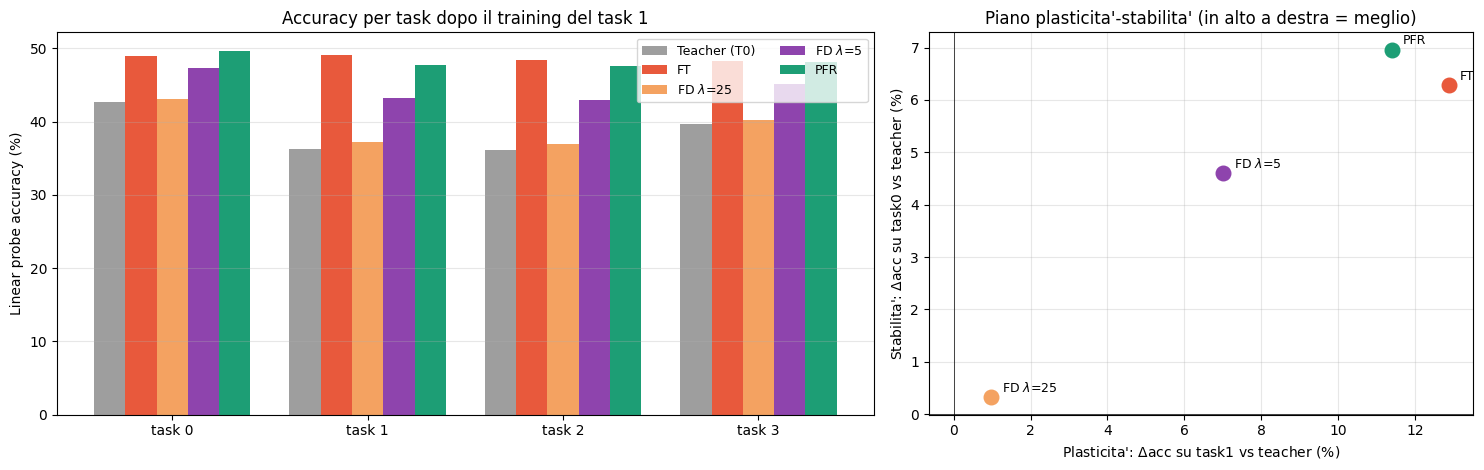

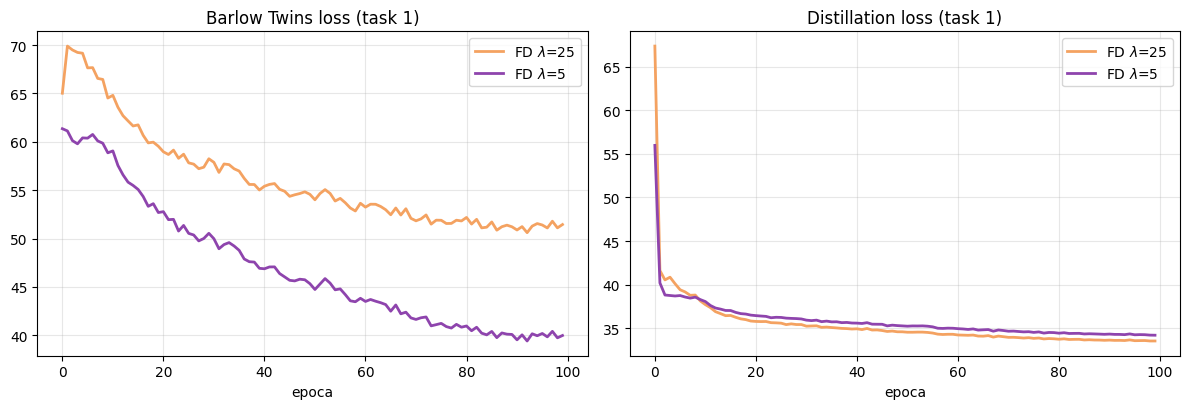

In [ ]:
# 5.5 — Grafici di confronto
import matplotlib.pyplot as plt
import numpy as np

METHODS5 = ['Teacher (solo T0)', 'FT after T1', 'FD l=25 after T1', 'FD l=5 after T1', 'PFR after T1']
COLORS5  = ['#9E9E9E',           '#E8593C',     '#F4A261',          '#8E44AD',         '#1D9E75']
LABELS5  = ['Teacher (T0)',      'FT',          'FD $\\lambda$=25', 'FD $\\lambda$=5', 'PFR']

fig, axes = plt.subplots(1, 2, figsize=(15, 5.8), gridspec_kw={'width_ratios': [1.5, 1]})

# (a) barre raggruppate: accuracy per task dopo il training del task 1
ax = axes[0]
x = np.arange(NT5)
w = 0.8 / len(METHODS5)
for k, (m, c, lab) in enumerate(zip(METHODS5, COLORS5, LABELS5)):
    vals = df5.loc[m, task_cols5].values.astype(float)
    ax.bar(x + (k - (len(METHODS5) - 1) / 2) * w, vals, w, label=lab, color=c)
ax.set_xticks(x); ax.set_xticklabels([f'task {i}' for i in range(NT5)])
ax.set_ylabel('Linear probe accuracy (%)')
ax.set_title('Accuracy per task dopo il training del task 1')
ax.grid(axis='y', alpha=0.3)
ax.legend(fontsize=9, ncol=2)

# (b) piano plasticita'-stabilita' (versione a 1 step della Fig. 4b del paper)
ax = axes[1]
for m, c, lab in zip(METHODS5[1:], COLORS5[1:], LABELS5[1:]):
    px = df5.loc[m, "plasticita' (dTask1)"]
    py = df5.loc[m, "stabilita'  (dTask0)"]
    if not (np.isnan(px) or np.isnan(py)):
        ax.scatter(px, py, s=110, color=c, zorder=3)
        ax.annotate(lab, (px, py), textcoords='offset points', xytext=(8, 4), fontsize=9)
ax.axhline(0, color='black', linewidth=0.5); ax.axvline(0, color='black', linewidth=0.5)
ax.set_xlabel("Plasticita': $\\Delta$acc su task1 vs teacher (%)")
ax.set_ylabel("Stabilita': $\\Delta$acc su task0 vs teacher (%)")
ax.set_title("Piano plasticita'-stabilita' (in alto a destra = meglio)")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('./fd_lambda_confronto.png', dpi=150, bbox_inches='tight')
plt.show()

# (c) curve di training: la "firma" dell'encoder congelato.
# Se l'ipotesi e' giusta: la distill loss di l=25 crolla subito e resta piatta,
# mentre con l=5 la barlow loss scende molto di piu' (l'encoder si muove).
DISTILL_KEY5 = 'train_decorrelative_distill_loss_epoch'
BARLOW_KEY5  = 'train_barlow_loss_epoch'

def curve5(run_name, key):
    for run in runs5:
        if run.name == run_name:
            h = run.history(keys=[key, 'epoch'])
            if key in h.columns:
                h = h.dropna(subset=[key])
                if not h.empty:
                    return h['epoch'].values, h[key].values
    return None, None

fig, axes = plt.subplots(1, 2, figsize=(12, 5.2))
for run_name, color, lab in [('fd-task1', '#F4A261', 'FD $\\lambda$=25'),
                             ('fd_lamb5-task1', '#8E44AD', 'FD $\\lambda$=5')]:
    xb, yb = curve5(run_name, BARLOW_KEY5)
    if xb is not None: axes[0].plot(xb, yb, label=lab, color=color, linewidth=2)
    xd, yd = curve5(run_name, DISTILL_KEY5)
    if xd is not None: axes[1].plot(xd, yd, label=lab, color=color, linewidth=2)
axes[0].set_title('Barlow Twins loss (task 1)')
axes[1].set_title('Distillation loss (task 1)')
for ax in axes:
    ax.set_xlabel('epoca'); ax.grid(alpha=0.3); ax.legend()
plt.tight_layout()
plt.savefig('./fd_lambda_curve_loss.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.6 — La catena completa con $\lambda=5$ (task 2 e 3)

Per avere una R-matrix di FD $\lambda=5$ confrontabile con quelle degli altri metodi servono anche i
task 2 e 3. Nota: `main_continual.py` con `--task_idx 1` **allena in sequenza tutti i task rimanenti**
(1, 2, 3) nella stessa invocazione, quindi è possibile che i checkpoint esistano già dal primo run —
la cella qui sotto lo verifica prima di far partire training inutili.

In [ ]:
# 5.6 — Controllo: quali checkpoint fd_lamb5 esistono gia'?
import os, glob, re

EXP_FD5 = os.environ.get('MY_EXP_FD5', '/content/drive/MyDrive/CVPR_PFR/experiments/fd_lamb5')
os.environ['MY_EXP_FD5'] = EXP_FD5
presenti = {}
for ck in glob.glob(f'{EXP_FD5}/**/*.ckpt', recursive=True):
    m = re.search(r'task(\d+)', os.path.basename(ck))
    if m:
        presenti[int(m.group(1))] = ck
for t in (1, 2, 3):
    print(f'task{t}:', os.path.basename(presenti[t]) if t in presenti else 'MANCANTE')

if 1 in presenti and 2 not in presenti:
    os.environ['MY_CKPT_FD5_PREV'] = presenti[1]
    print('\nManca il task 2: lancia la cella di training qui sotto (allena task 2 e 3 in sequenza, ~2-3h).')
elif 2 in presenti and 3 in presenti:
    print('\nCatena completa: salta il training e vai alle linear eval (5.7).')

task1: fd_lamb5-task1-ep=99-ndjwbhsr.ckpt
task2: fd_lamb5-task2-ep=99-i2yx98ai.ckpt
task3: fd_lamb5-task3-ep=99-kt82b4vr.ckpt

Catena completa: salta il training e vai alle linear eval (5.7).


In [ ]:
# 5.6b — Training task 2 e 3 con lambda=5 (SOLO se il controllo dice che mancano)
# main_continual.py con --task_idx 2 allena task 2 e poi task 3 nella stessa invocazione.
!CUDA_VISIBLE_DEVICES=0 python main_continual.py \
    --dataset cifar100 \
    --encoder resnet18 \
    --data_dir "$MY_DATA_DIR" \
    --split_strategy class \
    --max_epochs 100 \
    --num_tasks 4 \
    --task_idx 2 \
    --gpus 0 \
    --num_workers 4 \
    --precision 16 \
    --optimizer sgd --lars --grad_clip_lars --eta_lars 0.02 --exclude_bias_n_norm \
    --scheduler warmup_cosine \
    --lr 0.3 --classifier_lr 0.1 --weight_decay 1e-4 \
    --batch_size 256 \
    --brightness 0.4 --contrast 0.4 --saturation 0.2 --hue 0.1 \
    --gaussian_prob 0.0 0.0 --solarization_prob 0.0 0.2 \
    --name fd_lamb5 \
    --project "$MY_WANDB" \
    --save_checkpoint \
    --checkpoint_frequency 99 \
    --checkpoint_dir "$MY_EXP_FD5" \
    --disable_knn_eval \
    --method barlow_twins \
    --proj_hidden_dim 2048 --output_dim 2048 --scale_loss 0.1 \
    --distiller decorrelative \
    --distill_lamb 5 \
    --pretrained_model "$MY_CKPT_FD5_PREV" \
    --wandb \
    --knn_k 20

In [ ]:
# 5.7 — Linear eval dei checkpoint task 2 e 3 (nomi: linear_fd_lamb5_T2 / T3)
import os, glob
assert 'linear_eval' in globals(), 'esegui prima la cella della Sez. 9 che definisce linear_eval()'

for t in (2, 3):
    cks = [c for c in glob.glob(f"{os.environ['MY_EXP_FD5']}/**/*.ckpt", recursive=True)
           if f'task{t}' in os.path.basename(c)]
    if cks:
        linear_eval(max(cks, key=os.path.getmtime), f'linear_fd_lamb5_T{t}')
    else:
        print(f'task{t}: checkpoint mancante, lancia prima il training (5.6b)')

>> Linear eval: linear_fd_lamb5_T2
   ckpt: /content/drive/MyDrive/CVPR_PFR/experiments/fd_lamb5/i2yx98ai/fd_lamb5-task2-ep=99-i2yx98ai.ckpt
Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/content/drive/MyDrive/CVPR_PFR/cassle/utils/whitening.py:21: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @custom_fwd(cast_inputs=torch.float32)
Global seed set to 5
Loaded /content/drive/MyDrive/CVPR_PFR/experiments/fd_lamb5/i2yx98ai/fd_lamb5-task2-ep=99-i2yx98ai.ckpt
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/core/lightning.py:2053: DeprecationWarning: `torch.distributed._sharded

In [ ]:
# 5.8 — La R-matrix completa di FD lambda=5, accanto a quella di FD lambda=25
import os, re, wandb
import numpy as np
import pandas as pd

api58 = wandb.Api()
runs58 = api58.runs(os.environ.get('MY_WANDB', 'pfr'))
NT58 = 4

def accs58(nomi):
    for run in runs58:
        if run.name in nomi:
            s = run.summary._json_dict
            out = []
            for i in range(NT58):
                v = s.get(f'val_acc1_task{i}')
                out.append(np.nan if v is None else (v * 100 if v < 1.5 else v))
            return out
    return [np.nan] * NT58

R_fd5 = np.full((NT58, NT58), np.nan)
R_fd5[0, :] = accs58(['linear_t0', 'linear_task0'])
for t in (1, 2, 3):
    R_fd5[t, :] = accs58([f'linear_fd_lamb5_T{t}'])

idx58 = [f'dopo e{t+1}' for t in range(NT58)]
col58 = [f'e{i+1}' for i in range(NT58)]
print('=== FD lambda=5 (esame a 100 classi, come in Sez. 10.1) ===')
print(pd.DataFrame(R_fd5, index=idx58, columns=col58).round(2))
if 'R_fd' in globals():
    print('\n=== FD lambda=25, per confronto ===')
    print(pd.DataFrame(R_fd, index=idx58, columns=col58).round(2))

# metriche con le stesse formule della Sez. 10
T58 = NT58 - 1
fg = np.nanmean([np.nanmax(R_fd5[i:, i]) - R_fd5[T58, i] for i in range(T58)])
bwt = np.nanmean([R_fd5[T58, i] - R_fd5[i, i] for i in range(T58)])
avg = np.nanmean(R_fd5[T58, :])
print(f'\nFD lambda=5:  Avg Acc = {avg:.2f}%   Forgetting = {fg:.2f}   BWT = {bwt:+.2f}')
print('(confronta con la tabella della Sez. 10: FT ~54.0, FD lambda=25 ~41.1, PFR ~54.2)')

# se le funzioni del Passo 3 sono in sessione, anche la versione per-experience (25 classi)
if 'per_experience_accs14' in globals():
    import glob
    R25_fd5 = np.full((NT58, NT58), np.nan)
    R25_fd5[0, :] = per_experience_accs14(CKPTS14['task0'][0])
    for t in (1, 2, 3):
        cks = [c for c in glob.glob(f"{os.environ['MY_EXP_FD5']}/**/*.ckpt", recursive=True)
               if f'task{t}' in os.path.basename(c)]
        if cks:
            R25_fd5[t, :] = per_experience_accs14(max(cks, key=os.path.getmtime))
    print('\n=== FD lambda=5, esame per experience (25 classi, come in Sez. 10.2) ===')
    print(pd.DataFrame(R25_fd5, index=idx58, columns=col58).round(2))

/usr/local/lib/python3.12/dist-packages/wandb/analytics/sentry.py:280: DeprecationWarning: The `Scope.user` setter is deprecated in favor of `Scope.set_user()`.
  self.scope.user = {"email": email}


=== FD lambda=5 (esame a 100 classi, come in Sez. 10.1) ===
            e1     e2     e3     e4
dopo e1  42.72  36.24  36.08  39.72
dopo e2  47.32  43.24  43.00  45.08
dopo e3  49.72  46.72  48.56  47.52
dopo e4  52.16  47.88  49.96  51.88

=== FD lambda=25, per confronto ===
            e1     e2     e3     e4
dopo e1  42.72  36.24  36.08  39.72
dopo e2  43.04  37.20  36.88  40.16
dopo e3  42.20  38.52  39.32  41.00
dopo e4  43.52  39.36  38.76  42.84

FD lambda=5:  Avg Acc = 50.47%   Forgetting = 0.00   BWT = +5.16
(confronta con la tabella della Sez. 10: FT ~54.0, FD lambda=25 ~41.1, PFR ~54.2)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=4615) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()


  feature estratte: fd_lamb5-task2-ep=99-i2yx98ai
  feature estratte: fd_lamb5-task3-ep=99-kt82b4vr

=== FD lambda=5, esame per experience (25 classi, come in Sez. 10.2) ===
            e1     e2     e3     e4
dopo e1  62.96  57.04  60.96  62.44
dopo e2  65.96  62.44  64.88  65.68
dopo e3  70.00  65.64  69.92  68.20
dopo e4  71.52  67.56  71.60  72.16


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


> 📖 Lezione 24, *SML vs CL*: "avoiding forgetting slows down the plasticity" — la chiave di lettura di questi risultati.

---

# 13. Conclusioni e confronto con il paper

## Cosa aspettarsi (claim del paper, Tabella 1 e Fig. 4)

| Metrica | FT | FD | PFR |
|---|---|---|---|
| Avg Acc (paper, T4) | 54.8% | 57.8% | **59.7%** |
| Forgetting | alto | basso | basso |
| Plasticità | massima | bassa (intransigenza) | alta |

Il paper enfatizza che PFR raggiunge **simultaneamente** basso forgetting e alta plasticità — è il punto in basso-a-sinistra in Fig. 4b. FD invece riduce il forgetting al costo di alta intransigenza.

## Cosa abbiamo misurato

I numeri assoluti che ottieni saranno più bassi del paper (1500 → 100 epoche). La verifica della **riproducibilità** sta nel rispetto del ranking relativo:

- $\text{Avg Acc}(\text{PFR}) > \text{Avg Acc}(\text{FD}) > \text{Avg Acc}(\text{FT})$
- $\text{Forgetting}(\text{FT}) > \text{Forgetting}(\text{FD}) \approx \text{Forgetting}(\text{PFR})$
- BWT: PFR può addirittura essere positivo (paper Fig. 2: "PFR obtains positive backward transfer")

## Limiti dichiarati di questa riproduzione

1. **100 epoche per task** (paper: 1500, bash files: 500). Sotto-convergenza certa di Barlow Twins.
2. **Singola seed** — il paper riporta media ± std su 5 run.
3. **Una sola downstream task** (linear probe su CIFAR-100 stesso). Il paper valuta anche transfer su SVHN, Cars, Aircraft (Tabella 1 bottom, Tabella 4).
4. **Setup decorrelative + lamb=25 come "FD"**: è il bash file ufficiale del repo, ma differisce dal testo del paper (Eq. 4, L2 distillation). Vedi anche Sez. 7 di questo notebook.

## Possibili estensioni

- Salire a 200-300 epoche per task se i tempi di calcolo lo permettono.
- Ripetere su più seed per stimare la deviazione standard.
- Aggiungere il transfer su SVHN (dataset di facile setup, 32×32 come CIFAR-100).
- Replicare l'analisi forgetting-vs-intransigence di Fig. 4b variando $\lambda$.
- Estendere a 10 task per vedere se PFR scala meglio (Sez. 5.3 del paper, "Many task scenario").

## Le verifiche di correttezza, in sintesi

Tre controlli sul codice del repo, da presentare come esperimenti a corredo dei risultati:

1. la loss di distillazione riscritta a mano dalla formula del paper coincide **esattamente** con la
   funzione del repo (differenza 0): patch e librerie nuove non alterano i calcoli;
2. su input costruiti a tavolino la loss si comporta come dichiarato (≈0 con studente=teacher,
   crescente con la distanza, minimizzabile);
3. la backpropagation è integra (teacher congelato nei pesi, gradienti che fluiscono) e ha
   quantificato la causa dell'anomalia di FD: con λ=25 il gradiente della distillazione domina quello
   del task (coseno del passo con la direzione del vincolo ≈ 1.0); LARS ne normalizza la grandezza
   ma non la direzione. Unica riserva emersa: le running statistics della BatchNorm del teacher non
   sono congelate (dettaglio implementativo del repo, effetto trascurabile).